## Cava analysis
- Add gene information
- Investigate the numbers

### CAVA analysis 1. Mail to Lea

### General significant variants and element numbers 
- Plot of gene list + number of associated significant number of variants and elements
- Question about list Lea shared with source meta information ([Genes In Progress](https://docs.google.com/spreadsheets/d/1fY24m4HSMMBOLB5C47KeKIIq3KLXizH5ubSabLvNTIc/edit?gid=319542848#gid=319542848))  - 2 of the green marked genes are not in the set of significant results from variants ('C6PD', 'TSC2')
- 48 different genes used for design
- 52 different genes from Lea in table mentioned above 
- 11 different genes marked as green: analyzed by pillar project 
#### Variants 
- for 47 genes designed variants (only 37 have significant variant effects associated (only 8/11 green marked)
  - `{'CYP2C19', 'CTCF', 'CARD11', 'SFPQ', 'PALB2', 'RAD51D', 'NBN'}` (also found with significant more active elements
- 149 significant effects
- 84 upregulating 
- 65 downregulating
- 37 different genes with significant effects 
- RAD51B 28 associated significant variants (investigate ratios) => 1191 associated variants designed
#### Elements
- 47 different genes with significant effects (only 10/11 green marked genes with significant effects
  - `{'CYP2C19', 'CTCF', 'CARD11', 'BARD1', 'SFPQ', 'PALB2', 'RAD51D', 'F9', 'NBN'}`
  - only elements with significant effect not variants: `{'BARD1', 'F9'}`; missing from the analysis `{'TSC2'}`
### 

In [90]:
import pandas as pd
import numpy as np
import yaml
import os
from collections import defaultdict
from importlib import reload

# load helpful functions
import sys
sys.path.append('../../00_helpful_functions')
import helpful_functions as hf
reload(hf)
# config
config_path = "/home/kisa/coding/80K_MPRA/80K-Analysis/global80K_config.yaml"
with open(config_path) as conf:
    config = yaml.load(conf, Loader=yaml.FullLoader)
    conf.close()

In [91]:
col_name = 'name'
col_sequence = 'sequence'
col_category = 'category'
col_class = 'class'
col_source = 'source'
col_ref = 'ref'
col_chr = 'chr'
col_start = 'start'
col_end = 'end'
col_strand = 'strand'
col_variant_class = 'variant_class' # SNV
col_variant_pos = 'variant_pos'
col_SPDI = 'SPDI'
col_allele = 'allele'
col_info = 'info'

In [3]:
metadata_file = pd.read_csv(config['files']['creating']['datafreeze_table'], sep="\t", low_memory=False)
metadata_file.head()
metadata_file.columns



Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random'],
      dtype='object')

In [4]:
import ast

# Function to safely evaluate string representations of lists
def safe_eval(x):
    if pd.isna(x):
        return None
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return x

# list columns col_variant_class, col_variant_pos, col_SPDI, col_allele,
list_columns = [col_variant_class, col_variant_pos, col_SPDI, col_allele]
# Apply the safe_eval function to the specified columns
for col in list_columns:
    metadata_file[col] = metadata_file[col].apply(safe_eval)

In [5]:
# adding variant position with adapter:
def add_adapter_to_variant_pos(variant_pos_list, adapter_length=config['analysis_info']['adapter_length']):
    if pd.isna(variant_pos_list):
        return None
    new_variant_pos_list = []
    for variant_pos in variant_pos_list:
        new_variant_pos_list.append(int(variant_pos) + adapter_length)
    return new_variant_pos_list

metadata_file['tmp_variant_pos_with_adapter'] = metadata_file[col_variant_pos].apply(lambda variant_pos: add_adapter_to_variant_pos(variant_pos, config['analysis_info']['adapter_length']))


In [6]:
metadata_file[col_allele].value_counts()
metadata_file[col_allele] # 73846

0        [alt]
1        [alt]
2        [alt]
3        [alt]
4        [alt]
         ...  
73841     None
73842     None
73843     None
73844     None
73845     None
Name: allele, Length: 73846, dtype: object

Investigate variant positions of examples

### Overlap with E2G predictions: 
- threholded predictions: 49908 
- embryonic male neuronal stem cells encode (H1): `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/full_predictions/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_full_predictions.tsv.gz`
- bedpe: `/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_thresholded_predictions.bedpe.gz`
- other files which might be interesting: 
    - bipolar neuron: `encode_e2g_predictions_bipolar_neuron_ENCDO336AAA_ENCFF125JWY_DNaseOnly_thresholded_predictions.bedpe.gz`
      - name: `bipolar_neuron_ENCDO336AAA_ENCFF125JWY`
    - ecto neuron: `encode_e2g_predictions_ecto_neural_progenitor_cell_ENCDO222AAA_ENCFF884HMI_DNaseOnly_thresholded_predictions.bedpe.gz`
      - name: `ecto_neural_progenitor_cell_ENCDO222AAA_ENCFF884HMI`
    - neural crest cell: `encode_e2g_predictions_neural_crest_cell_ENCDO222AAA_ENCFF103QUR_DNaseOnly_thresholded_predictions.bedpe.gz`
      - name: `neural_crest_cell_ENCDO222AAA_ENCFF103QUR`
    - neural progenitor cell: `encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_thresholded_predictions.bedpe.gz`
      - name: `neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB`
    - download these files and add one column with their name: 
    `zcat input.tsv.gz | awk 'BEGIN {FS=OFS="\t"} {print (NR==1 ? "data_name" : "name_1"), $0}' | gzip > /path/to/output.tsv.gz`

In [7]:
# helpful function:
def get_e2g_gene_name(e2g_name):
    """get gene name from e2g name: FAAP20|chr1:2194476-2195780 => FAAP20"""
    return e2g_name.split("|")[0]

In [8]:
# E2G download with additional name column
! zcat /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_bipolar_neuron_ENCDO336AAA_ENCFF125JWY_DNaseOnly_thresholded_predictions.bedpe.gz | awk 'BEGIN {FS=OFS="\t"} {print $0,"bipolar_neuron_ENCDO336AAA_ENCFF125JWY"}' | gzip > /home/kisa/coding/80K_MPRA/e2g_analysis_output/e2g_server_data/encode_e2g_predictions_bipolar_neuron_ENCDO336AAA_ENCFF125JWY_DNaseOnly_thresholded_predictions.bedpe.gz
! zcat /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_ecto_neural_progenitor_cell_ENCDO222AAA_ENCFF884HMI_DNaseOnly_thresholded_predictions.bedpe.gz | awk 'BEGIN {FS=OFS="\t"} {print $0,"ecto_neural_progenitor_cell_ENCDO222AAA_ENCFF884HMI"}' | gzip > /home/kisa/coding/80K_MPRA/e2g_analysis_output/e2g_server_data/encode_e2g_predictions_ecto_neural_progenitor_cell_ENCDO222AAA_ENCFF884HMI_DNaseOnly_thresholded_predictions.bedpe.gz
! zcat /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neural_crest_cell_ENCDO222AAA_ENCFF103QUR_DNaseOnly_thresholded_predictions.bedpe.gz | awk 'BEGIN {FS=OFS="\t"} {print $0,"neural_crest_cell_ENCDO222AAA_ENCFF103QUR"}' | gzip > /home/kisa/coding/80K_MPRA/e2g_analysis_output/e2g_server_data/encode_e2g_predictions_neural_crest_cell_ENCDO222AAA_ENCFF103QUR_DNaseOnly_thresholded_predictions.bedpe.gz
! zcat /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_thresholded_predictions.bedpe.gz | awk 'BEGIN {FS=OFS="\t"} {print $0,"neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB"}' | gzip > /home/kisa/coding/80K_MPRA/e2g_analysis_output/e2g_server_data/encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_thresholded_predictions.bedpe.gz


gzip: /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_bipolar_neuron_ENCDO336AAA_ENCFF125JWY_DNaseOnly_thresholded_predictions.bedpe.gz: No such file or directory
gzip: /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_ecto_neural_progenitor_cell_ENCDO222AAA_ENCFF884HMI_DNaseOnly_thresholded_predictions.bedpe.gz: No such file or directory
gzip: /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neural_crest_cell_ENCDO222AAA_ENCFF103QUR_DNaseOnly_thresholded_predictions.bedpe.gz: No such file or directory
gzip: /data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCOD

In [9]:
# read bedpe file as tsv
# bedpe_e2g_thresholded = pd.read_csv('/data/cephfs-2/unmirrored/groups/kircher/MPRA/ProximalPromoter/projects/proximal_prom_analysis/predictions/Predictors/ENCODE-E2G/thresholded_bedpe/encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_thresholded_predictions.bedpe.gz', sep="\t", header=None)
bedpe_e2g_thresholded = pd.read_csv(os.path.join(config['files']['creating']['e2g_overlap']['e2g_output_directory'], 'encode_e2g_predictions_neuronal_stem_cell_ENCDO000AAW_ENCFF204GFI_DNaseOnly_thresholded_predictions.bedpe.gz'), sep="\t", header=None)
# columns are tmp_e2g_enhancer_chr, tmp_e2g_enhancer_start, tmp_e2g_enhancer_end, tmp_e2g_gene_TSS_chr, tmp_e2g_gene_TSS_start, tmp_e2g_gene_TSS_end, tmp_e2g_gene_name_range, tmp_e2g_score, tmp_e2g_enhancer_strand, tmp_e2g_gene_strand
bedpe_e2g_thresholded.columns = ['tmp_e2g_enhancer_chr', 'tmp_e2g_enhancer_start', 'tmp_e2g_enhancer_end', 'tmp_e2g_gene_TSS_chr', 'tmp_e2g_gene_TSS_start', 'tmp_e2g_gene_TSS_end', 'tmp_e2g_gene_name_range', 'tmp_e2g_score', 'tmp_e2g_enhancer_strand', 'tmp_e2g_gene_strand']
# bedpe_e2g_thresholded.head()
# bedpe_e2g_thresholded

In [10]:
metadata_file.shape[0]

73846

In [11]:
# overlap between metadata file:
# 1. make bed file from metadata file
bed_formated_metadata = metadata_file[[col_chr, col_start, col_end, col_name]]
# add "." for score and strand
bed_formated_metadata['score'] = "."
bed_formated_metadata[col_strand] = metadata_file[col_strand]
print(bed_formated_metadata.shape[0]) # 73846

# remove duplicates based on chr, start, end
bed_formated_metadata = bed_formated_metadata.drop_duplicates(subset=[col_chr, col_start, col_end], keep='first')
print(bed_formated_metadata.shape[0]) # 27199

# # write to file:
# bed_formated_metadata.to_csv(config['files']['creating']['datafreeze_bed'], sep="\t", header=False, index=False)

# 2. overlap with bedpe file using bedtools intersect
# bedtools intersect -a metadata_file.bed -b bedpe_e2g_thresholded.bedpe -wa -wb > metadata_file_overlap.bedpe

73846
27199


/tmp/ipykernel_289809/2492802941.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bed_formated_metadata['score'] = "."
/tmp/ipykernel_289809/2492802941.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bed_formated_metadata[col_strand] = metadata_file[col_strand]


In [12]:
# metadata_bed_path = config['files']['creating']['datafreeze_bed']
# e2g_thresholded_male_neuro_stem_cell_bedpe = config['files']['creating']['e2g_overlap']['e2g_thresholded_male_neuro_stem_cell']
e2g_neuro_stem_cell_output = os.path.join(config['files']['creating']['e2g_overlap']['e2g_output_directory'], 'metadata_file_overlap_neuro_stem_cell_male.bed')
# !bedtools intersect -a {metadata_bed_path} -b {e2g_thresholded_male_neuro_stem_cell_bedpe} -wa -wb > {e2g_neuro_stem_cell_output}

In [23]:
def combine_chr_start_end(row, column_names=['chr', 'start', 'end']):
    """
    Combines chr, start, end columns into a single string
    """
    if len(column_names) != 3:
        raise ValueError("column_names must have 3 elements")
    return row[column_names[0]] + ":" + str(row[column_names[1]]) + "-" + str(row[column_names[2]])


def get_gene_name(header, with_controls=True):
    """Returns the gene name: cardiac_neuro_cava_random:SKI|ENSG00000157933.11|EH38E2778533_fwd_tile1-1 => SKI"""
    if 'cardiac_neuro_cava_random' not in header:
        if not with_controls:
            print(header)
            raise ValueError("Function only defined for tested headers")
        return "Not given - control sequence"


    if 'ALT_' in header:
        return header.split(":ALT_")[1].split('|')[0]

    if 'REF_' in header:
        return header.split(":REF_")[1].split('|')[0]

    return header.split(':')[1].split('|')[0]

In [14]:
# read the output file and join based on region information (chr:start-end): 2149 overlaps
metadata_file_overlap_neuro_stem_cell = pd.read_csv(e2g_neuro_stem_cell_output, sep="\t", header=None)

# columns tmp_e2g_neuro_stem_ovelap_chr, tmp_e2g_neuro_stem_overlap_start, tmp_e2g_neuro_stem_overlap_end, tmp_e2g_neuro_stem_overlap_name, score, strand, tmp_e2g_enhancer_chr, tmp_e2g_enhancer_start, tmp_e2g_enhancer_end, tmp_e2g_gene_TSS_chr, tmp_e2g_gene_TSS_start, tmp_e2g_gene_TSS_end, tmp_e2g_gene_name_range, tmp_e2g_score, tmp_e2g_enhancer_strand, tmp_e2g_gene_strand
metadata_file_overlap_neuro_stem_cell.columns = ['tmp_e2g_neuro_stem_ovelap_chr', 'tmp_e2g_neuro_stem_overlap_start', 'tmp_e2g_neuro_stem_overlap_end', 'tmp_e2g_neuro_stem_overlap_name', 'score', 'strand', 'tmp_e2g_enhancer_chr', 'tmp_e2g_enhancer_start', 'tmp_e2g_enhancer_end', 'tmp_e2g_gene_TSS_chr', 'tmp_e2g_gene_TSS_start', 'tmp_e2g_gene_TSS_end', 'tmp_e2g_gene_name_range', 'tmp_e2g_score', 'tmp_e2g_enhancer_strand', 'tmp_e2g_gene_strand']
metadata_file_overlap_neuro_stem_cell['tmp_chr_start_end'] = metadata_file_overlap_neuro_stem_cell.apply(lambda x: combine_chr_start_end(x, column_names=['tmp_e2g_neuro_stem_ovelap_chr', 'tmp_e2g_neuro_stem_overlap_start', 'tmp_e2g_neuro_stem_overlap_end']), axis=1)

In [15]:
print(metadata_file_overlap_neuro_stem_cell.shape[0]) # 2149
print(metadata_file_overlap_neuro_stem_cell['tmp_chr_start_end'].nunique()) # 1258

2149
1258


Some regions in our data have multiple predictions => preprocessing before matching => make gene name_range lists 

In [16]:
# groupby tmp_chr_start_end and make list of the tmp_e2g_gene_name_range column and name it tmp_e2g_gene_name_range_list
metadata_file_overlap_neuro_stem_cell_grouped = metadata_file_overlap_neuro_stem_cell.groupby('tmp_chr_start_end')['tmp_e2g_gene_name_range'].apply(list).reset_index(name='tmp_e2g_gene_name_range_list')
metadata_file_overlap_neuro_stem_cell_grouped

,tmp_chr_start_end,tmp_e2g_gene_name_range_list
0,chr10:102064532-102064802,[HPS6|chr10:102064795-102066184]
1,chr10:102113923-102114193,[HPS6|chr10:102113740-102114576]
2,chr10:102115377-102115647,"[HPS6|chr10:102114785-102115707, LDB1|chr10:10..."
3,chr10:102118102-102118372,"[HPS6|chr10:102117269-102118174, LDB1|chr10:10..."
4,chr10:102133913-102134183,[PPRC1|chr10:102132393-102134331]
...,...,...
1253,chrX:71118036-71118306,[MED12|chrX:71118305-71119286]
1254,chrX:71118825-71119095,[MED12|chrX:71118305-71119286]
1255,chrX:71119031-71119301,[MED12|chrX:71118305-71119286]
1256,chrX:71182443-71182713,"[FOXO4|chrX:71181564-71182873, MED12|chrX:7118..."


In [17]:
metadata_file['tmp_chr_start_end'] = metadata_file.apply(lambda x: combine_chr_start_end(x, column_names=[col_chr, col_start, col_end]), axis=1)

In [18]:
# left join metadata_file with metadata_file_overlap_neuro_stem_cell
metadata_file = metadata_file.merge(metadata_file_overlap_neuro_stem_cell_grouped, on='tmp_chr_start_end', how='left')
metadata_file_with_e2g_predictions_matched = metadata_file.loc[~metadata_file['tmp_e2g_gene_name_range_list'].isna()] # 3741

In [19]:
metadata_file_with_e2g_predictions_matched # 3741

,header,sequence,tmp_label,name,category,class,source,ref,variant_class,variant_pos,...,tmp_MPRA_primary_region_overlap,tmp_MPRA_organoid_region_overlap,tmp_gene_name,tmp_gene_set,tmp_is_neuro,tmp_is_cardiac,tmp_is_cava,tmp_is_random,tmp_variant_pos_with_adapter,tmp_e2g_gene_name_range_list
5,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,AGGACCGGATCAACTATTCGATGGTGCGGGAGGTGGCCGGCAGGGT...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[95],...,False,False,SKI,['neuro'],True,False,False,False,[110],[FAAP20|chr1:2194460-2195600]
205,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,AGGACCGGATCAACTAGGGCGGGCCAGACTCTGCGGTGGGGGTGGG...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[214],...,False,False,PRDM16,['cardiac'],False,True,False,False,[229],"[LINC00982|chr1:3062528-3064256, PRDM16|chr1:3..."
208,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,AGGACCGGATCAACTCGAAAGGACGGCAGGGAATGGGGCTGTGCCA...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[125],...,False,False,PRDM16,['cardiac'],False,True,False,False,[140],[LINC00982|chr1:3067475-3068264]
505,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,AGGACCGGATCAACTCTCCCCAAAGAGCAAGATGACCACACACTTT...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[75],...,False,False,PRDM16,['cardiac'],False,True,False,False,[90],[ARHGEF16|chr1:3351672-3353484]
506,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,AGGACCGGATCAACTCTCCCCAAAGAGCAAGATGACCACACACTTT...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_PRDM16|ENSG00000...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[145],...,False,False,PRDM16,['cardiac'],False,True,False,False,[160],[ARHGEF16|chr1:3351672-3353484]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73770,cardiac_neuro_cava_random:LAMP2|ENSG0000000589...,AGGACCGGATCAACTAGAGACAATTAGGAGAGTCTTGGTTTGCTGA...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:LAMP2|ENSG0000000589...,element,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,None,None,...,False,False,LAMP2,['cardiac'],False,True,False,False,None,[LAMP2|chrX:120468562-120469599]
73771,cardiac_neuro_cava_random:LAMP2|ENSG0000000589...,AGGACCGGATCAACTAAGCCATCATCCTTAGCAAACTAACACAGGA...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:LAMP2|ENSG0000000589...,element,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,None,None,...,False,False,LAMP2,['cardiac'],False,True,False,False,None,[LAMP2|chrX:120468562-120469599]
73779,cardiac_neuro_cava_random:FGF13|ENSG0000012968...,AGGACCGGATCAACTGTGGGGGCGGTGGGGAGCAGGTATGTAGCAT...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:FGF13|ENSG0000012968...,element,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,None,None,...,False,False,FGF13,['neuro'],True,False,False,False,None,[FGF13-AS1|chrX:138710678-138712428]
73801,cardiac_neuro_cava_random:FGF13|ENSG0000012968...,AGGACCGGATCAACTTCTCTGCATGTTGTCCATACTTGGAAGAGTC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:FGF13|ENSG0000012968...,element,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,None,None,...,False,False,FGF13,['neuro'],True,False,False,False,None,[FGF13|chrX:139224566-139225674]


In [20]:
# overlap with neural progenitor CREs:
# TODO:
# investigate the number of different regions tested in the 80k mpra
metadata_bed_df = pd.read_csv(config['files']['creating']['datafreeze_bed'], sep="\t", header=None) # 27199
metadata_bed_df.columns = [col_chr, col_start, col_end, col_name, 'score', col_strand]
metadata_bed_df['tmp_region_id'] = metadata_bed_df[col_name].apply(hf.get_region_info)
metadata_bed_df['tmp_region_id'].nunique() # 27199

27199

In [21]:
# intersect /home/kisa/coding/80K_MPRA/datafreeze/80K_MPRA_datafreeze_tested_01Aug2024.bed
metadata_bed_path = config['files']['creating']['datafreeze_bed']
e2g_bedpe_neural_progenitor = os.path.join(config['files']['creating']['e2g_overlap']['e2g_output_directory'], 'e2g_server_data',  'encode_e2g_predictions_neural_progenitor_cell_ENCDO222AAA_ENCFF123YLB_DNaseOnly_thresholded_predictions.bedpe.gz')
e2g_bedpe_neural_progenitor_output = os.path.join(config['files']['creating']['e2g_overlap']['e2g_output_directory'], 'metadata_file_overlap_neural_progenitor.bed')
# !bedtools intersect -a {metadata_bed_path} -b {e2g_bedpe_neural_progenitor} -wa -wb > {e2g_bedpe_neural_progenitor_output}
# investigate the predictions of genes: are these overlapping our assigned genes?

In [24]:
# read e2g_bedpe_neural_progenitor_output
metadata_file_overlap_neural_progenitor = pd.read_csv(e2g_bedpe_neural_progenitor_output, sep="\t", header=None)
metadata_file_overlap_neural_progenitor.columns
metadata_file_overlap_neural_progenitor.head()
metadata_file_overlap_neural_progenitor.columns = ['tmp_e2g_metadata_overlap_chr', 'tmp_e2g_metadata_overlap_start', 'tmp_e2g_metadata_overlap_end', 'tmp_e2g_metadata_overlap_name', 'score', 'strand', 'tmp_e2g_enhancer_chr', 'tmp_e2g_enhancer_start', 'tmp_e2g_enhancer_end', 'tmp_e2g_gene_TSS_chr', 'tmp_e2g_gene_TSS_start', 'tmp_e2g_gene_TSS_end', 'tmp_e2g_gene_name_range', 'tmp_e2g_score', 'tmp_e2g_gene_name_score', 'tmp_e2g_gene_name_strand', 'tmp_e2g_gene_overlap_source']



# add a column for the region id (screen id)
n_all_regions_in_80K = metadata_bed_df['tmp_region_id'].nunique()
metadata_file_overlap_neural_progenitor['tmp_region_id'] = metadata_file_overlap_neural_progenitor['tmp_e2g_metadata_overlap_name'].apply(hf.get_region_info)
# investigate how many regions have a prediction from E2G
print(f"Number and proportion of regions with a prediction from E2G: {metadata_file_overlap_neural_progenitor['tmp_region_id'].nunique()} / {n_all_regions_in_80K} ({round(metadata_file_overlap_neural_progenitor['tmp_region_id'].nunique()/n_all_regions_in_80K*100,2)}%)")

# add gene from E2G
metadata_file_overlap_neural_progenitor['tmp_e2g_gene_name'] = metadata_file_overlap_neural_progenitor['tmp_e2g_gene_name_range'].apply(get_e2g_gene_name)
print(f"Number of unique genes assigned form E2G neural progenitor prediction", metadata_file_overlap_neural_progenitor['tmp_e2g_gene_name'].nunique())
# add a column for the gene name associated
metadata_file_overlap_neural_progenitor['tmp_metadata_gene_name'] = metadata_file_overlap_neural_progenitor['tmp_e2g_metadata_overlap_name'].apply(get_gene_name)
print(f"Number of unique genes assigned from metadata in overlap", metadata_file_overlap_neural_progenitor['tmp_metadata_gene_name'].nunique())

metadata_file_overlap_neural_progenitor['tmp_region_id'].nunique() # 1399

print('Investigating if the gene names predicted and associated are the same')

# # 2 cases: tmp_metadata_gene_name is in the list of predictions for the associated region or not
# in order to count the number of overlaps: groupby the 'tmp_e2g_metadata_overlap_chr', 'tmp_e2g_metadata_overlap_start', 'tmp_e2g_metadata_overlap_end' and make a list of the 'tmp_e2g_gene_name_range' column and another list of the 'tmp_metadata_gene_name' column
metadata_file_overlap_neural_progenitor_grouped = metadata_file_overlap_neural_progenitor.groupby(['tmp_e2g_metadata_overlap_chr', 'tmp_e2g_metadata_overlap_start', 'tmp_e2g_metadata_overlap_end'])[['tmp_e2g_gene_name', 'tmp_metadata_gene_name']].agg(list).reset_index()
metadata_file_overlap_neural_progenitor_grouped # 1399

# add a is same column: if tmp_metadata_gene_name is in tmp_e2g_gene_name
metadata_file_overlap_neural_progenitor_grouped['tmp_gene_names_same'] = metadata_file_overlap_neural_progenitor_grouped.apply(lambda x: x['tmp_metadata_gene_name'][0] in x['tmp_e2g_gene_name'], axis=1)# 1399 regions
metadata_80K_and_E2G_neural_progenitor_same_gene_assigned = metadata_file_overlap_neural_progenitor_grouped['tmp_gene_names_same'].value_counts().reset_index()

#investigate the number and ration of rations with the same gene name association
# add colums with ratios
metadata_80K_and_E2G_neural_progenitor_same_gene_assigned['ratio'] = metadata_80K_and_E2G_neural_progenitor_same_gene_assigned['tmp_gene_names_same'] / metadata_80K_and_E2G_neural_progenitor_same_gene_assigned['tmp_gene_names_same'].sum()
metadata_80K_and_E2G_neural_progenitor_same_gene_assigned

# make list of genes with same assignment
metadata_e2g_neural_progenitor_same_gene_list_raw = metadata_file_overlap_neural_progenitor_grouped.loc[metadata_file_overlap_neural_progenitor_grouped['tmp_gene_names_same']]['tmp_metadata_gene_name'].to_list()
metadata_e2g_neural_progenitor_same_gene_list = [gene for sublist in metadata_e2g_neural_progenitor_same_gene_list_raw for gene in sublist]
metadata_e2g_neural_progenitor_same_gene_unique = list(set(metadata_e2g_neural_progenitor_same_gene_list))
print(f"Number of unique genes with the same assignment: {len(metadata_e2g_neural_progenitor_same_gene_unique)}")
print(metadata_e2g_neural_progenitor_same_gene_unique)
# # make a df of 'tmp_e2g_metadata_overlap_chr', 'tmp_e2g_metadata_overlap_start', 'tmp_e2g_metadata_overlap_end' + 'tmp_metadata_gene_name'
# list of genes with different assignment
metadata_e2g_neural_progenitor_diff_gene_list_raw = metadata_file_overlap_neural_progenitor_grouped.loc[~metadata_file_overlap_neural_progenitor_grouped['tmp_gene_names_same']]['tmp_metadata_gene_name'].to_list()
metadata_e2g_neural_progenitor_diff_gene_list = [gene for sublist in metadata_e2g_neural_progenitor_diff_gene_list_raw for gene in sublist]
metadata_e2g_neural_progenitor_diff_gene_unique = list(set(metadata_e2g_neural_progenitor_diff_gene_list))
print(f"Number of unique genes with different assignment: {len(metadata_e2g_neural_progenitor_diff_gene_unique)}")
print(metadata_e2g_neural_progenitor_diff_gene_unique)


# 1399/27199

Number and proportion of regions with a prediction from E2G: 1399 / 27199 (5.14%)
Number of unique genes assigned form E2G neural progenitor prediction 1099
Number of unique genes assigned from metadata in overlap 367
Investigating if the gene names predicted and associated are the same
Number of unique genes with the same assignment: 278
['SLX4', 'DHCR7', 'SETD1A', 'PIGS', 'NR4A2', 'SETD2', 'MAX', 'EEF1A2', 'NACC1', 'MKX', 'ATR', 'GRIA2', 'TRIO', 'GABBR2', 'POGZ', 'TLK2', 'FHL3', 'RINT1', 'IQSEC2', 'NBN', 'TAOK1', 'ARHGAP31', 'ASXL3', 'CITED2', 'CNOT3', 'KCNT1', 'UGP2', 'BCL11A', 'WAC', 'PIGL', 'EYA4', 'BAG3', 'PIGQ', 'NRXN2', 'TBX1', 'GJA1', 'TRIP12', 'ECE1', 'TSHZ3', 'PPP2R5D', 'NF1', 'GNAI1', 'SCN1B', 'ROR2', 'CDK19', 'MYH11', 'RORB', 'CUX2', 'DSP', 'MAFB', 'MOGS', 'MAP2K1', 'NOS3', 'LAMP2', 'CDH1', 'PPP3CA', 'CPLX1', 'PIGA', 'BCKDK', 'ATP1A3', 'VEZF1', 'BRSK2', 'KCNQ3', 'TNRC6B', 'KMT2A', 'UBA5', 'SDHD', 'TCF7L2', 'SMAD6', 'RFX3', 'UBE3A', 'MTHFR', 'ELAVL3', 'CHRM2', 'DNMT3A', 'XR

In [25]:
1399/27199

0.05143571454832898

Text(0.5, 1.0, 'Distribution of Overlaps with Neural Progenitor Cell CREs (E2G predictions)')

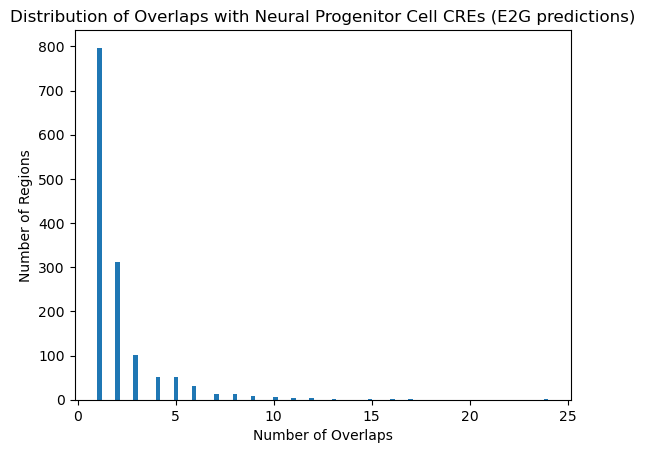

In [26]:
# histogram of the region ids and their numbers
# investigate the distribution of the region ids:
regions_with_overlap_e2g_neural_progenitor = metadata_file_overlap_neural_progenitor['tmp_region_id'].value_counts().reset_index(name='count')
import matplotlib.pyplot as plt
plt.hist(regions_with_overlap_e2g_neural_progenitor['count'], bins=100)
plt.xlabel('Number of Overlaps')
plt.ylabel('Number of Regions')
plt.title('Distribution of Overlaps with Neural Progenitor Cell CREs (E2G predictions)')

### Investigate the distance of the variants to the TSS

### Questions to be answered:
- What is the ratio of variants with results from MPRA
- How many variants have significant effect?
    - what is the proportion?
- How many variants with positive effect?
- How many variants with negative effect?
- How many variants with no effect?
- Is there a relationship between the variant effect and the distance between variant and TSS? (canonical (most used tss in neurons?))
- How many open variants within open chromatin?

### Investigate the numbers
- 10275 cava related sequences 
- 8308 alternative sequences 
- 1782 reference sequences
- 185 elements designed
- with results from BECALM: 
- TODO: 

In [27]:
cava_table = metadata_file.loc[metadata_file['tmp_is_cava']]
cava_table.head()

# make table of total number, number of ref, number of alt, number of elements
total_number = cava_table.shape[0]
number_of_alt = cava_table.loc[cava_table['allele'] == 'alt'].shape[0]
number_of_ref = cava_table.loc[cava_table['allele'] == 'ref'].shape[0]
number_of_elements = cava_table.loc[cava_table['category'] == 'element'].shape[0]
# create table
cava_number_table = pd.DataFrame({'total_number': [total_number],
                      'number_of_alt': [number_of_alt],
                      'number_of_ref': [number_of_ref],
                      'number_of_elements': [number_of_elements]})

In [28]:
cava_number_table # 8308 + 1782 + 185 = 10275

,total_number,number_of_alt,number_of_ref,number_of_elements
0,10265,0,0,175


#### Add gene name 

In [29]:
cava_table.head()

,header,sequence,tmp_label,name,category,class,source,ref,variant_class,variant_pos,...,tmp_MPRA_primary_region_overlap,tmp_MPRA_organoid_region_overlap,tmp_gene_name,tmp_gene_set,tmp_is_neuro,tmp_is_cardiac,tmp_is_cava,tmp_is_random,tmp_variant_pos_with_adapter,tmp_e2g_gene_name_range_list
1257,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTCTGGATCCTCTAGGAATCTGCTTGTGGGGTC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[43],...,False,False,SDHB,['cava'],False,False,True,False,[58],NaN
1258,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTGACTTATGACCAGAACTCAGCTCCCCAGCTC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[230],...,False,False,SDHB,['cava'],False,False,True,False,[245],NaN
1259,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTGACTTATGACCAGAACTCAGCTCCCCAGCTC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[196],...,False,False,SDHB,['cava'],False,False,True,False,[211],NaN
1260,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTGACTTATGACCAGAACTCAGCTCCCCAGCAC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[29],...,False,False,SDHB,['cava'],False,False,True,False,[44],NaN
1261,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTCACATTAGGAATGTCCCCTTAGTGAGCAGGG...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[190],...,False,False,SDHB,['cava'],False,False,True,False,[205],NaN


In [30]:
from collections import defaultdict


def get_gene_lookup_dict(gene_lists):
    """
    prepare a dict which has gene_name: (list of associated gene_sets)
    :gene_lists - list of files containing gene names and have useful names
    """
    gene_lookup_dict = defaultdict(list)
    for file in gene_lists:
        with open(os.path.join(gene_list_dir, file), 'r') as f:
            gene_list = f.read().splitlines()
            gene_list_name = file.split('.')[0]
            for gene in gene_list:
                gene_lookup_dict[gene].append(gene_list_name)
    return gene_lookup_dict


def get_gene_name(header, with_controls=True):
    """Returns the gene name: cardiac_neuro_cava_random:SKI|ENSG00000157933.11|EH38E2778533_fwd_tile1-1 => SKI"""
    if 'cardiac_neuro_cava_random' not in header:
        if not with_controls:
            print(header)
            raise ValueError("Function only defined for tested headers")
        return "Not given - control sequence"


    if 'ALT_' in header:
        return header.split(":ALT_")[1].split('|')[0]

    if 'REF_' in header:
        return header.split(":REF_")[1].split('|')[0]

    return header.split(':')[1].split('|')[0]

def get_gene_name_from_element(header):
    """Returns the gene name: cardiac_neuro_cava_random:SKI|ENSG00000157933.11|EH38E2778533_fwd_tile1-1 => SKI"""
    if 'ALT_' in header:
        print(header)
        raise ValueError('This function is only for element sequences')

    if 'REF_' in header:
        return header.split(":REF_")[1].split('|')[0]

    return header.split(':')[1].split('|')[0]


# get gene_list files:
gene_list_dir = '/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists'
gene_lists = os.listdir(gene_list_dir)

# prepare a dict which has gene_name: (tuple of associated gene_sets)
gene_lookup_dict = get_gene_lookup_dict(gene_lists=gene_lists)

# # get gene name from variant id
cava_table['tmp_gene_name'] = cava_table[col_name].apply(get_gene_name)

/tmp/ipykernel_289809/259567893.py:56: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cava_table['tmp_gene_name'] = cava_table[col_name].apply(get_gene_name)


In [31]:
# overlap with e2g predictions
cava_with_e2g_predictions_matched = cava_table.loc[~cava_table['tmp_e2g_gene_name_range_list'].isna()] # 539
cava_with_e2g_predictions_matched

,header,sequence,tmp_label,name,category,class,source,ref,variant_class,variant_pos,...,tmp_MPRA_primary_region_overlap,tmp_MPRA_organoid_region_overlap,tmp_gene_name,tmp_gene_set,tmp_is_neuro,tmp_is_cardiac,tmp_is_cava,tmp_is_random,tmp_variant_pos_with_adapter,tmp_e2g_gene_name_range_list
1327,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTGAAATTTCAAGAACAGGGCCGTGTGCCCCTC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[205],...,False,False,SDHB,['cava'],False,False,True,False,[220],[ATP13A2|chr1:17015855-17016714]
1328,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTGAAATTTCAAGAACAGGGCCGTGTGCCCCTC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[192],...,False,False,SDHB,['cava'],False,False,True,False,[207],[ATP13A2|chr1:17015855-17016714]
1329,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTGAAATTTCAAGAACAGGGCCGTGTGCCCCTC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[155],...,False,False,SDHB,['cava'],False,False,True,False,[170],[ATP13A2|chr1:17015855-17016714]
1330,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTGAAATTTCAAGAACAGGGCCGTGTGCCCCTC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[113],...,False,False,SDHB,['cava'],False,False,True,False,[128],[ATP13A2|chr1:17015855-17016714]
1331,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,AGGACCGGATCAACTGAAATTTCAAGAACAGGGCCGTGTGCCCCTC...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],[79],...,False,False,SDHB,['cava'],False,False,True,False,[94],[ATP13A2|chr1:17015855-17016714]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64938,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,AGGACCGGATCAACTTGCTCAGGGGGACTCATTAAAGCAACACTTT...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,variant,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,[SNV],None,...,False,False,G6PD,['cava'],False,False,True,False,None,"[FAM3A|chrX:154515518-154517692, SLC10A3|chrX:..."
65546,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,AGGACCGGATCAACTGAAGAAGCAACTGCAGTGCTGTGGGAAGGGT...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,element,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,None,None,...,False,False,AHDC1,"['neuro', 'cava']",True,False,True,False,None,"[AHDC1|chr1:27592168-27593969, IFI6|chr1:27592..."
66735,cardiac_neuro_cava_random:BAP1|ENSG00000163930...,AGGACCGGATCAACTTCCTTGCACATTGCACCCCCATTCCAGAGAG...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:BAP1|ENSG00000163930...,element,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,None,None,...,False,False,BAP1,['cava'],False,False,True,False,None,[TNNC1|chr3:52453743-52454349]
71591,cardiac_neuro_cava_random:CTCF|ENSG00000102974...,AGGACCGGATCAACTAGACCCTGGACGACGTCCTGCACCGGATTGT...,cardiac_neuro_cava_random,cardiac_neuro_cava_random:CTCF|ENSG00000102974...,element,test,"candidate CRE nearby cardiac, neuro, cava and ...",GRCh38,None,None,...,False,False,CTCF,"['neuro', 'cava']",True,False,True,False,None,"[ACD|chr16:67648834-67649891, C16orf86|chr16:6..."


### Investigate the significant variants
- designed 10090 variants

In [32]:
cava_table_variants = cava_table.loc[cava_table[col_category] == 'variant']
cava_table_variants.shape[0] # 8308 + 1782 = 10090

10090

In [33]:
# get all alternatives
cava_table_alt_sequences = cava_table_variants.loc[cava_table_variants[col_allele].apply(hf.is_alternative)]
print('Number of alternative sequences: ', cava_table_alt_sequences.shape[0]) # 8308

Number of alternative sequences:  8308


In [34]:
# load variant BE-CALM table
# TODO: 80K results in barcode MPRAlm
# TODO: Read most recent results

variant_input_path = config["files"]["creating"]["toptable_bcMPRAlm_final_resequencing_umi"]
variant_input_path = config["files"]["creating"]["toptable_bcMPRAlm_final_resequencing"]
variant_input_path = config['files']['creating']['bc_MPRAlm_bbmap_standard_mapq35_noLength']

variant_becalm_raw = pd.read_csv(variant_input_path, sep="\t")
variant_becalm_raw.columns = ['tmp_variant_BECALM_logFC', 'tmp_variant_BECALM_AveExpr', 'tmp_variant_BECALM_t', 'tmp_variant_BECALM_P.Value', 'tmp_variant_BECALM_adj.P.Val', 'tmp_variant_BECALM_B', 'tmp_variant_BECALM_variant_id']

# important columns:
becalm_variant_important_columns = ['tmp_variant_BECALM_variant_id', 'tmp_variant_BECALM_logFC', 'tmp_variant_BECALM_adj.P.Val']
bcMPRAlm_table = variant_becalm_raw[becalm_variant_important_columns]
print(f'Unique variants: {bcMPRAlm_table["tmp_variant_BECALM_variant_id"].nunique()}')
# resequencing: 36941

Unique variants: 38553


In [35]:
# add the results to the table using variant id:
# change column names of variant region map
variant_region_map = pd.read_csv(config['files']['final_design']['variant_table'], sep='\t')
variant_region_map.columns = ['tmp_variant_map_Variant_id', 'tmp_variant_map_Region', 'tmp_variant_map_REF_ID', 'tmp_variant_map_ALT_ID']


### Merge cava alternatives with ALT_ID to add REF and Variant ID
- do cava specific and for all the variants


In [36]:
metadata_file_alt_sequences = metadata_file.loc[metadata_file[col_allele].apply(hf.is_alternative)]

# join with variant information
metadata_file_alt_sequences_alt_seqs_variant_info = metadata_file_alt_sequences.merge(variant_region_map, left_on=col_name, right_on='tmp_variant_map_ALT_ID', how='left')
# join with becalm variant info
metadata_file_alt_seqs_variant_info_becalm = metadata_file_alt_sequences_alt_seqs_variant_info.merge(bcMPRAlm_table, left_on='tmp_variant_map_Variant_id', right_on='tmp_variant_BECALM_variant_id', how='left')

metadata_file_alt_seqs_variant_info_becalm['is_significant'] = metadata_file_alt_seqs_variant_info_becalm['tmp_variant_BECALM_adj.P.Val'] < 0.05

In [37]:
# join with variant information
cava_table_alt_seqs_variant_info = cava_table_alt_sequences.merge(variant_region_map, left_on=col_name, right_on='tmp_variant_map_ALT_ID', how='left')
# join with becalm variant info
cava_table_alt_seqs_variant_info_becalm = cava_table_alt_seqs_variant_info.merge(bcMPRAlm_table, left_on='tmp_variant_map_Variant_id', right_on='tmp_variant_BECALM_variant_id', how='left')
cava_table_alt_seqs_variant_info_becalm['is_significant'] = cava_table_alt_seqs_variant_info_becalm['tmp_variant_BECALM_adj.P.Val'] < 0.05
# remove unused columns => tmp_region_id => screen ids


In [38]:
n_cava_variants_readouts = cava_table_alt_seqs_variant_info_becalm.loc[~cava_table_alt_seqs_variant_info_becalm['tmp_variant_BECALM_adj.P.Val'].isna()].shape[0]

In [39]:
n_cava_variants_readouts / cava_table_alt_sequences.shape[0]

0.8097014925373134

In [40]:
# cava_table_alt_seqs_variant_info_becalm_matched

In [41]:
# check if mapping worked
print(f'Number of variants in cava table: {cava_table_alt_seqs_variant_info.shape[0]}')
cava_table_alt_seqs_variant_info_becalm_matched = cava_table_alt_seqs_variant_info_becalm.loc[~cava_table_alt_seqs_variant_info_becalm['tmp_variant_BECALM_adj.P.Val'].isna()]
print(f'Number of variants in cava table with becalm results: {cava_table_alt_seqs_variant_info_becalm_matched.shape[0]}')

# ratio:
print(f'Ratio of variants with becalm results: {cava_table_alt_seqs_variant_info_becalm_matched.shape[0] / cava_table_alt_seqs_variant_info.shape[0]}')

# how many different regions? How many different genes?

Number of variants in cava table: 8308
Number of variants in cava table with becalm results: 6727
Ratio of variants with becalm results: 0.8097014925373134


### Investigate the CAVA gene lists 
- Investigate the overlap between design list and google docs GenesInProgess list
- And overlap with acmg genes
- copied from /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/notebooks/element_analysis_activator_repressor.ipynb (I think more important here)
  - plot of significant results per gene is still there
- metadata for 52 genes (only 11 are green in the table https://docs.google.com/spreadsheets/d/1fY24m4HSMMBOLB5C47KeKIIq3KLXizH5ubSabLvNTIc/edit?gid=319542848#gid=319542848)
- designed gene list: 48 different genes

In [42]:
# negative neuron np vs tested (left sided)
element_analysis_r_result = pd.read_csv(config['files']['creating']['element_analysis_np_negative_neuron_vs_tested'], sep="\t")
element_analysis_r_result
# # get gene name from variant id
element_analysis_r_result['gene_name'] = element_analysis_r_result['variant_id'].apply(get_gene_name_from_element)
# add gene_set annotation
element_analysis_r_result['gene_set'] = element_analysis_r_result['gene_name'].apply(lambda gene: gene_lookup_dict[gene])

# add gene info boolean columns
element_analysis_r_result['is_neuro'] = element_analysis_r_result['gene_set'].apply(lambda x: 'neuro' in x)
element_analysis_r_result['is_cardiac'] = element_analysis_r_result['gene_set'].apply(lambda x: 'cardiac' in x)
element_analysis_r_result['is_cava'] = element_analysis_r_result['gene_set'].apply(lambda x: 'cava' in x)
element_analysis_r_result['is_random'] = element_analysis_r_result['gene_set'].apply(lambda x: 'random' in x)

# add significant column
element_analysis_r_result['is_significant'] = element_analysis_r_result['adj.P.Val'] < 0.05



In [43]:
cava_table_alt_seqs_variant_info_becalm['tmp_gene_name'].unique()

array(['SDHB', 'AHDC1', 'SFPQ', 'BCL10', 'LMNA', 'SDHC', 'FH', 'CYP2C19',
       'MYBPC3', 'SDHAF2', 'MRE11', 'ATM', 'SDHD', 'BRCA2', 'MYH7',
       'FANCM', 'MAX', 'RAD51B', 'RAD51', 'MORF4L1', 'FANCI', 'NTHL1',
       'TSC2', 'SLX4', 'PALB2', 'CTCF', 'CDH1', 'FLCN', 'RAD51D', 'BRIP1',
       'MALT1', 'BARD1', 'SRC', 'NF2', 'CYP2D6', 'CTNNB1', 'BAP1', 'ATR',
       'SDHA', 'IRF4', 'FARS2', 'CARD11', 'RINT1', 'XRCC2', 'NBN',
       'ZC4H2', 'F9', 'G6PD'], dtype=object)

In [44]:
cava_element_analysis_result = element_analysis_r_result.loc[element_analysis_r_result['is_cava']]
cava_element_analysis_result
print('Number of cava associated results: ', cava_element_analysis_result['variant_id'].nunique()) # 1633

significant_cava_element_analysis_result = cava_element_analysis_result.loc[cava_element_analysis_result['is_significant']]

# number of significantly active elements
print('Number of significant cava associated results: ', significant_cava_element_analysis_result['variant_id'].nunique()) # 1439
# number of associated genes
print('number of associated genes: ', significant_cava_element_analysis_result['gene_name'].nunique()) # 47 (48 in design file)
element_all_significant_genes_set = set(element_analysis_r_result.loc[element_analysis_r_result['is_significant']]['gene_name'].to_list())
element_all_genes_set_with_readout = set(element_analysis_r_result['gene_name'].to_list())

# variant table and gene list of significant results
variant_all_significant_genes_set = set(metadata_file_alt_seqs_variant_info_becalm.loc[metadata_file_alt_seqs_variant_info_becalm['is_significant']]['tmp_gene_name'].to_list())
variant_all_genes_set_with_readout = set(metadata_file_alt_seqs_variant_info_becalm['tmp_gene_name'].to_list())

# cava_table_alt_seqs_variant_info_becalm['tmp_gene_name']
# metadata_file_alt_seqs_variant_info_becalm['tmp_gene_name']

# read cava gene list csv
cava_gene_list_source_df = pd.read_csv(config['files']['creating']['cava_analysis']['cava_gene_list_with_source'], sep=";")
cava_gene_list_source_df.head()
unique_source_data_cava_genes = list(cava_gene_list_source_df['Gene'].unique())
print('Number of genes from Lea with Source metadata: ', cava_gene_list_source_df['Gene'].nunique()) # 52
green_in_table = ['CARD11', 'SFPQ', 'PALB2', 'CTCF', 'BARD1', 'NBN', 'RAD51D', 'CYP2C19', 'F9', 'G6PD', 'TSC2']
# green in table and not source data cava
print('Genes green in table but not in metadata table (empty expected)', set(green_in_table) - set(unique_source_data_cava_genes)) # 10

print(f'Number of green marked genes from meta data table: {len(green_in_table)}')
# not all of the designed genes are in the source table
designed_gene_list = pd.read_csv('/home/kisa/coding/80K_MPRA/MPRA_design/resources/gene_lists/cava.txt', header=None)
designed_gene_list.columns = ['gene_name']
designed_gene_list.shape[0] #48
print(f'Number of different genes in the design: ', designed_gene_list.shape[0]) #48

# acmg_genelist
acmg_genelist = pd.read_csv(config['files']['creating']['acmg_genelist'], sep=';')
acmg_genelist
acmg_gene_set = set(acmg_genelist['Gene'])

# how many genes of cava_element_analysis_result and  overlap the cava_gene_list_source_df
# overlap of element and variant and green in table:
print(f'Overlap with green marked genes and variants and elements:  {len(variant_all_significant_genes_set.intersection(element_all_significant_genes_set).intersection(green_in_table))}')
print(f'Overlap with variants and green marked genes:  {len(variant_all_significant_genes_set.intersection(green_in_table))}')
print(f'Overlap with elements and green marked genes:  {len(element_all_significant_genes_set.intersection(green_in_table))}')
print(f'List of genes only green marked (elements): {set(green_in_table) - set(element_all_significant_genes_set)}')
print(f'List of genes only green marked (variants): {set(green_in_table) - set(variant_all_significant_genes_set)}')
# F9: 105 variants non significant; BARD1: 156 variants non significant; TSC2: 522 designed variants non significant
# overlap with genes in progress:

# make union of cava (designed genes) and green marked genes
designed_cava_gene_set = set(designed_gene_list['gene_name'])
union_cava_green_genes = designed_cava_gene_set.union(set(green_in_table))
union_all_cava_genes = union_cava_green_genes.union(set(unique_source_data_cava_genes))

# overlap of cava genes with acmg genelist
overlap_acmg_cava = acmg_gene_set.intersection(union_cava_green_genes)
overlap_acmg_all_cava = acmg_gene_set.intersection(union_all_cava_genes)
print(f'Number of genes acmg: {len(acmg_gene_set)}')
print(f'Number of genes cava: {len(union_cava_green_genes)}')
print(f'Number of union of all cava genes: {len(union_all_cava_genes)}')
print(f'Overlap of ACMG genelist and cava genes: {len(overlap_acmg_cava)}')
print(f'Overlap of ACMG genelist and union cava genes: {len(overlap_acmg_all_cava)}')

# overlap of significant results of genes in either elements or variants and cava genes
significant_results_genes = set(variant_all_significant_genes_set).union(set(element_all_significant_genes_set))
# union_cava_green_genes
overlap_cava_green_significant_results = union_cava_green_genes.intersection(significant_results_genes)

# union_all_cava_genes
overlap_all_cava_green_significant_results = union_all_cava_genes.intersection(significant_results_genes)
print(f'Number of cava genes: {len(union_cava_green_genes)}')
print(f'Number of significant results: {len(significant_results_genes)}')
print(f'Overlap of cava genelist and significant results: {len(overlap_cava_green_significant_results)}')
print(f'Set of genes overlapping cava and significant results: {overlap_cava_green_significant_results}')

print(f'Overlap of all cava genelist and significant results: {len(overlap_all_cava_green_significant_results)}')
print(f'Set of genes overlapping all cava and significant results: {overlap_all_cava_green_significant_results}')

# variant and element specific overlap
print('Element specific overlap:')
element_overlap_cava_green_significant_results = set(element_all_significant_genes_set).intersection(union_cava_green_genes)
print(f'Overlap of element genelist and significant results: {len(element_overlap_cava_green_significant_results)}')
print(f'Set of genes overlapping element and significant results: {element_overlap_cava_green_significant_results}')

print('Variant specific overlap:')
print('Variant and all results:')
variant_overlap_cava_green_all_results = set(variant_all_genes_set_with_readout).intersection(union_cava_green_genes)
print(f'Overlap of variant genelist and all results: {len(variant_overlap_cava_green_all_results)}')
print(f'Set of genes overlapping variant and all results: {variant_overlap_cava_green_all_results}')
print('Variant and significant results:')
variant_overlap_cava_green_significant_results = set(variant_all_significant_genes_set).intersection(union_cava_green_genes)
print(f'Overlap of variant genelist and significant results: {len(variant_overlap_cava_green_significant_results)}')
print(f'Set of genes overlapping variant and significant results: {variant_overlap_cava_green_significant_results}')

# overlap of significant results of genes in either elements or variants and the acmg gene list
overlap_acmg_significant_results = acmg_gene_set.intersection(significant_results_genes)
print(f'Number of acmg genes: {len(acmg_gene_set)}')
print(f'Overlap of ACMG genelist and significant results: {len(overlap_acmg_significant_results)}')
print(f'Set of genes overlapping acmg and significant results: {overlap_acmg_significant_results}')

Number of cava associated results:  1633
Number of significant cava associated results:  1439
number of associated genes:  47
Number of genes from Lea with Source metadata:  52
Genes green in table but not in metadata table (empty expected) set()
Number of green marked genes from meta data table: 11
Number of different genes in the design:  48
Overlap with green marked genes and variants and elements:  8
Overlap with variants and green marked genes:  8
Overlap with elements and green marked genes:  10
List of genes only green marked (elements): {'TSC2'}
List of genes only green marked (variants): {'BARD1', 'F9', 'TSC2'}
Number of genes acmg: 81
Number of genes cava: 48
Number of union of all cava genes: 77
Overlap of ACMG genelist and cava genes: 12
Overlap of ACMG genelist and union cava genes: 13
Number of cava genes: 48
Number of significant results: 522
Overlap of cava genelist and significant results: 47
Set of genes overlapping cava and significant results: {'CYP2C19', 'IRF4', 'S

#### Add AF of the variants and investigate the distribution => fill in table

### Significants analysis: 
- preliminary results:
- 115 significant
- 60 up 
  - mean log2fc of top 10: ~1.1
- 55 down
  - mean log2fc of top 10: ~-1.1


In [45]:
# significant_results[col_name].apply(lambda x: True if ':REF_' in x else False).sum() # no reference sequences

In [46]:
# find number of significant results
significant_results = cava_table_alt_seqs_variant_info_becalm_matched.loc[cava_table_alt_seqs_variant_info_becalm_matched['tmp_variant_BECALM_adj.P.Val'] < 0.05]
print(f'Number of significant results: {significant_results.shape[0]}')
n_cava_variants_significant = significant_results.shape[0]

# upregulating and downregulating
# find number of significant results with logFC > 0
significant_results['is_upregulating'] = significant_results['tmp_variant_BECALM_logFC'] > 0
print(f'Number of upregulating results: {significant_results["is_upregulating"].sum()}')

significant_results_up = significant_results.loc[significant_results['tmp_variant_BECALM_logFC'] > 0]
print(f'Number of significant results with logFC > 0: {significant_results_up.shape[0]}')
n_cava_variants_significant_up = significant_results_up.shape[0]
# find number of significant results with logFC < 0
significant_results['is_downregulating'] = significant_results['tmp_variant_BECALM_logFC'] < 0
significant_results_down = significant_results.loc[significant_results['tmp_variant_BECALM_logFC'] < 0]
print(f'Number of significant results with logFC < 0: {significant_results_down.shape[0]}')
n_cava_variants_significant_down = significant_results_down.shape[0]
# top 10 up and top 10 down
top_10_up = significant_results_up.sort_values('tmp_variant_BECALM_logFC', ascending=False).head(10)
top_10_down = significant_results_down.sort_values('tmp_variant_BECALM_logFC', ascending=True).head(10)

# print top 10 up logFC distribution
print('Top 10 up logFC distribution:')
print(top_10_up['tmp_variant_BECALM_logFC'].describe())

# print top 10 down logFC distribution
print('Top 10 down logFC distribution:')
print(top_10_down['tmp_variant_BECALM_logFC'].describe())

# # write top 10 to files
# top_10_up.to_csv(config['files']['creating']['cava_analysis']['top_10_up'], sep='\t', index=False)
# top_10_down.to_csv(config['files']['creating']['cava_analysis']['top_10_down'], sep='\t', index=False)

Number of significant results: 149
Number of upregulating results: 84
Number of significant results with logFC > 0: 84
Number of significant results with logFC < 0: 65
Top 10 up logFC distribution:
count    10.000000
mean      0.730287
std       0.129662
min       0.567955
25%       0.616801
50%       0.726498
75%       0.815307
max       0.952964
Name: tmp_variant_BECALM_logFC, dtype: float64
Top 10 down logFC distribution:
count    10.000000
mean     -0.630035
std       0.137919
min      -0.960738
25%      -0.635373
50%      -0.578294
75%      -0.545990
max      -0.514116
Name: tmp_variant_BECALM_logFC, dtype: float64


/tmp/ipykernel_289809/2993627458.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_results['is_upregulating'] = significant_results['tmp_variant_BECALM_logFC'] > 0
/tmp/ipykernel_289809/2993627458.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_results['is_downregulating'] = significant_results['tmp_variant_BECALM_logFC'] < 0


In [47]:
# ratio:
cava_variant_significant_ratio =  n_cava_variants_significant / n_cava_variants_readouts
print(f'Ratio of significant variants for the cava group: {cava_variant_significant_ratio}')

# # ratio of up and down
# cava_variant_significant_up_ratio = n_cava_variants_significant_up / n_cava_variants_significant
# cava_variant_significant_down_ratio = n_cava_variants_significant_down / n_cava_variants_significant
# print(f'Ratio of upregulating variants for the cava group: {cava_variant_significant_up_ratio}')
# print(f'Ratio of downregulating variants for the cava group: {cava_variant_significant_down_ratio}')

Ratio of significant variants for the cava group: 0.022149546603240672


#### Investigate genes: 
- overall number of genes associated to variants 
- number of significant variants associated to the genes

In [48]:
def plot_significant_count_per_gene(gene_name_significant_counts, count_column_name='significant_variant_count', type_of_count='Variant', output_path=None):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import pandas as pd

    # Assuming your data is in a DataFrame called 'df'
    # If it's not, you can create it like this:
    # df = pd.DataFrame({'tmp_gene_name': [...], count_column_name: [...]})

    # Sort the DataFrame by count_column_name in descending order
    df_sorted = gene_name_significant_counts.sort_values('tmp_gene_name', ascending=True)

    # Create the bar plot
    plt.figure(figsize=(12, 6))
    plot = sns.barplot(x='tmp_gene_name', y=count_column_name, data=df_sorted)

    # Customize the plot
    plt.xlabel(f'Gene Names (n={df_sorted["tmp_gene_name"].nunique()})')
    plt.ylabel(f'Significant {type_of_count} Count (n={df_sorted[count_column_name].sum()})')
    plt.title(f'Significant {type_of_count} Count associated to Gene')
    plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

    # Add value labels on top of each bar
    for i, v in enumerate(df_sorted[count_column_name]):
        plt.text(i, v, str(v), ha='center', va='bottom')

    # Adjust layout and display the plot
    plt.tight_layout()

    fig = plot.get_figure()
    # store to path
    if output_path != None:
        fig.savefig(output_path)
    plt.show()


In [49]:
# for each gene the number of associated variants
cava_variant_to_gene_number = cava_table_alt_seqs_variant_info_becalm_matched.groupby('tmp_gene_name').size().reset_index(name='number_of_variants')
cava_variant_to_gene_number.head()

,tmp_gene_name,number_of_variants
0,AHDC1,236
1,ATM,190
2,ATR,153
3,BAP1,123
4,BARD1,52


/tmp/ipykernel_289809/1813832193.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_results['significant_variant_is_associated'] = True


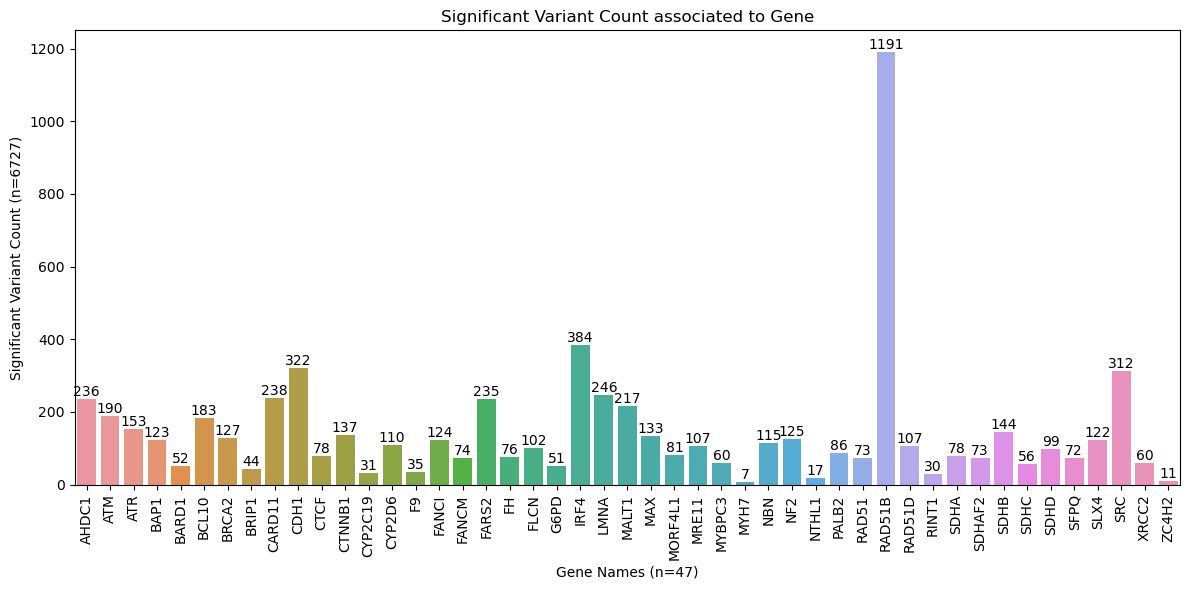

In [50]:
significant_results['tmp_gene_name'].nunique() # 37
genes_with_significant_variants_associated = list(significant_results['tmp_gene_name'].unique()) # 37
significant_results['significant_variant_is_associated'] = True
# write gene set with significant output from variant specific or element specific analysis
# columns of interest for the gene table: 'tmp_gene_name', 'significant_variant_is_associated'
gene_variant_info_table = significant_results[['tmp_gene_name', 'significant_variant_is_associated']]
output_name_gene_variant_table = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'gene_variant_association.tsv')
gene_variant_info_table.to_csv(output_name_gene_variant_table, index=False, sep="\t")

# groupby and size()
gene_name_significant_variant_associated = gene_variant_info_table.groupby('tmp_gene_name').size().reset_index()
gene_name_significant_variant_associated.columns = ['tmp_gene_name', 'significant_variant_count']

# merge cava_variant_to_gene_number and gene_name_significant_variant_associated
cava_variant_to_gene_significant_number = cava_variant_to_gene_number.merge(gene_name_significant_variant_associated, on='tmp_gene_name', how='left')


# set nan values to 0
cava_variant_to_gene_significant_number['significant_variant_count'] = cava_variant_to_gene_significant_number['significant_variant_count'].fillna(0)


# compute ration of significant variants in new column
cava_variant_to_gene_significant_number['proportion_significant_variants'] = cava_variant_to_gene_significant_number['significant_variant_count'] / cava_variant_to_gene_significant_number['number_of_variants']
cava_variant_to_gene_significant_number
output_name_gene_variant_table = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'gene_variant_association.tsv')
cava_variant_to_gene_significant_number.to_csv(output_name_gene_variant_table, index=False, sep="\t")

# plot number of designed variants per gene
plot_significant_count_per_gene(cava_variant_to_gene_significant_number, count_column_name='number_of_variants', type_of_count='Variant', output_path=os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'designed_number_of_variants_per_gene_with_readout.png'))


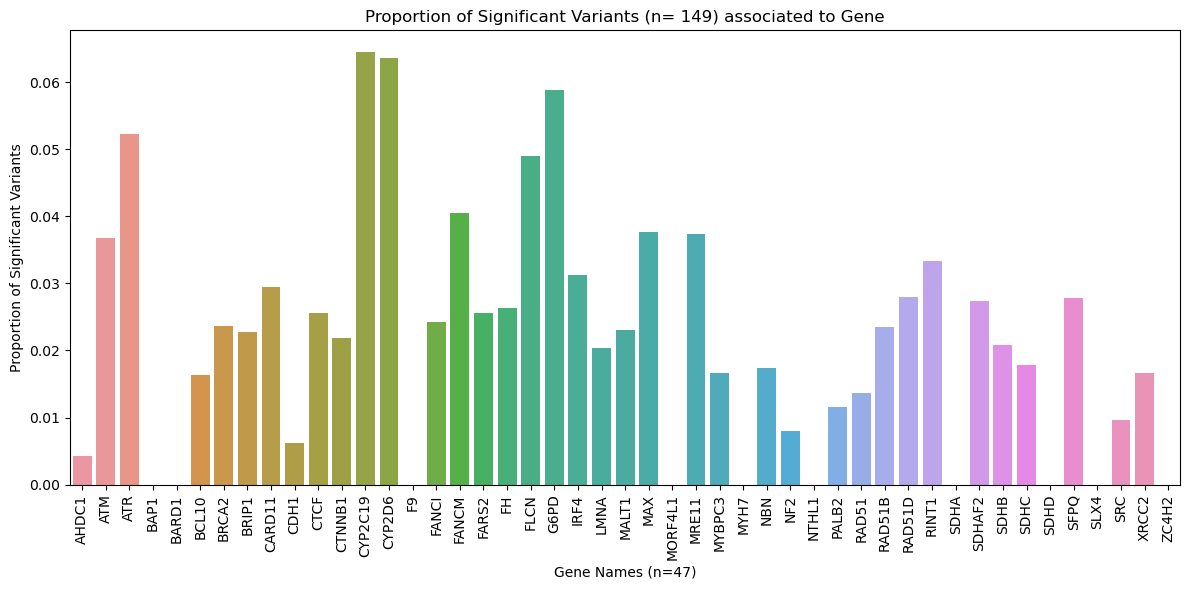

In [51]:
# plot

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
cava_variant_to_gene_significant_number
output_path=os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variant_proportion_per_gene.png')
count_column_name='proportion_significant_variants'
# Assuming your data is in a DataFrame called 'df'
# If it's not, you can create it like this:
# df = pd.DataFrame({'tmp_gene_name': [...], count_column_name: [...]})

# Sort the DataFrame by count_column_name in descending order
df_sorted = cava_variant_to_gene_significant_number.sort_values('tmp_gene_name', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 6))
plot = sns.barplot(x='tmp_gene_name', y=count_column_name, data=df_sorted)

# Customize the plot
plt.xlabel(f'Gene Names (n={df_sorted["tmp_gene_name"].nunique()})')
plt.ylabel(f'Proportion of Significant Variants')
plt.title(f'Proportion of Significant Variants (n= {int(df_sorted["significant_variant_count"].sum())}) associated to Gene')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# # Add value labels on top of each bar
# for i, v in enumerate(df_sorted[count_column_name]):
#     plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

# Adjust layout and display the plot
plt.tight_layout()

fig = plot.get_figure()
# store to path
if output_path != None:
    fig.savefig(output_path)
plt.show()


##### Investigate number of significant variants per CAVA associated genes

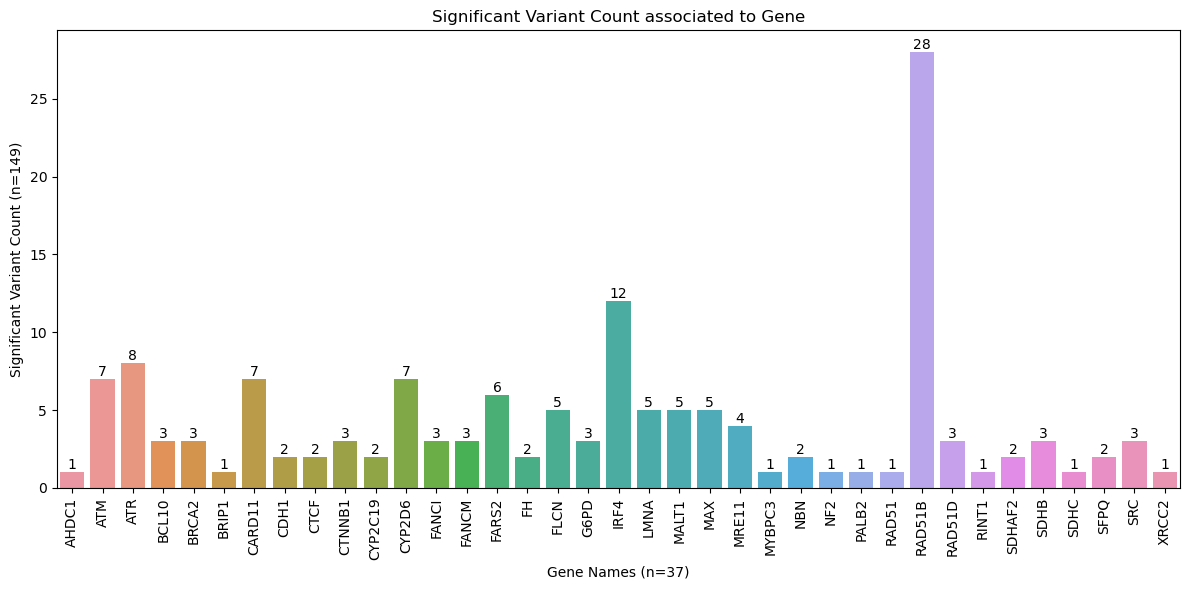

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Assuming your data is in a DataFrame called 'df'
# If it's not, you can create it like this:
# df = pd.DataFrame({'tmp_gene_name': [...], 'significant_variant_count': [...]})

# Sort the DataFrame by significant_variant_count in descending order
df_sorted = gene_name_significant_variant_associated.sort_values('tmp_gene_name', ascending=True)

# Create the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(x='tmp_gene_name', y='significant_variant_count', data=df_sorted)

# Customize the plot
plt.xlabel(f'Gene Names (n={gene_name_significant_variant_associated["tmp_gene_name"].nunique()})')
plt.ylabel(f'Significant Variant Count (n={gene_name_significant_variant_associated["significant_variant_count"].sum()})')
plt.title('Significant Variant Count associated to Gene')
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability

# Add value labels on top of each bar
for i, v in enumerate(df_sorted['significant_variant_count']):
    plt.text(i, v, str(v), ha='center', va='bottom')

# Adjust layout and display the plot
plt.tight_layout()
plt.show()


#### Investigate overlap of readout and number of genes (measured and significant)

In [53]:
metadata_file_alt_sequences.columns

# metadata_file_alt_sequences.tmp_label.value_counts() # all tested sequences (sanity check)

# interesting for variant analysis:
variant_interesting_becalm_cols = ['tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list']

In [54]:
# # join with variant information
# metadata_file_alt_sequences_alt_seqs_variant_info = metadata_file_alt_sequences.merge(variant_region_map, left_on=col_name, right_on='tmp_variant_map_ALT_ID', how='left')

# #

# # join with becalm variant info
# metadata_file_alt_seqs_variant_info_becalm = metadata_file_alt_sequences_alt_seqs_variant_info.merge(bcMPRAlm_table, left_on='tmp_variant_map_Variant_id', right_on='tmp_variant_BECALM_variant_id', how='left')

# metadata_file_alt_seqs_variant_info_becalm['is_significant'] = metadata_file_alt_seqs_variant_info_becalm['tmp_variant_BECALM_adj.P.Val'] < 0.05

element_analysis_r_result # elements
element_analysis_r_result.columns

# interesting columns:
element_interesting_cols_becalm = ['variant_id', 'adj.P.Val', 'logFC']
element_analaysis_becalm_df = element_analysis_r_result[element_interesting_cols_becalm]
element_analaysis_becalm_df.columns = ['tmp_element_BECALM_id', 'tmp_element_BECALM_adj.P.Val', 'tmp_element_BECALM_logFC']

# left join with variant region list => alt information => variant information for the ref sequences as well
element_analaysis_becalm_df_variant_info = element_analaysis_becalm_df.merge(variant_region_map, left_on='tmp_element_BECALM_id', right_on='tmp_variant_map_REF_ID', how='left')
 # 0
print('Number of elements with variant information: ', element_analaysis_becalm_df_variant_info.loc[~element_analaysis_becalm_df_variant_info['tmp_variant_map_ALT_ID'].isna()].shape[0]) # 37615
print('Number of elements without variant information: ', element_analaysis_becalm_df_variant_info['tmp_variant_map_ALT_ID'].isna().sum()) # 7582
# if na in variant_alt_id => is only an element
tested_bcMPRAlm_table = bcMPRAlm_table.loc[bcMPRAlm_table['tmp_variant_BECALM_variant_id'].str.startswith('cardiac_neuro_cava_random')]
element_analaysis_becalm_df_variant_info_becalm = element_analaysis_becalm_df_variant_info.merge(tested_bcMPRAlm_table, left_on='tmp_variant_map_Variant_id', right_on='tmp_variant_BECALM_variant_id', how='left')
print('Number of elements with variant information: ', element_analaysis_becalm_df_variant_info_becalm.loc[~element_analaysis_becalm_df_variant_info_becalm['tmp_variant_BECALM_adj.P.Val'].isna()].shape[0]) # 36530
print('Number of elements without variant information: ', element_analaysis_becalm_df_variant_info_becalm['tmp_variant_BECALM_adj.P.Val'].isna().sum()) # 8667

# metadata_file_alt_sequences = metadata_file.loc[metadata_file[col_allele].apply(hf.is_alternative)]



Number of elements with variant information:  37615
Number of elements without variant information:  7582
Number of elements with variant information:  36302
Number of elements without variant information:  8895


In [55]:
# investigate number of elements and variants with readouts
# add is_element column
element_analaysis_becalm_df_variant_info_becalm['is_element'] = element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'].isna() | ~element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_REF_ID'].isna()

# add is_variant column
element_analaysis_becalm_df_variant_info_becalm['is_variant'] = ~element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'].isna()

# print numbers of elements and variants
print('Number of elements: ', element_analaysis_becalm_df_variant_info_becalm['is_element'].sum()) # 45197
print('Number of variants: ', element_analaysis_becalm_df_variant_info_becalm['is_variant'].sum()) # 37615

Number of elements:  45197
Number of variants:  37615


In [56]:
element_analaysis_becalm_df_variant_info_becalm.columns

# add gene names to the table and find the overlap to the cava genes and their significant results
element_analaysis_becalm_df_variant_info_becalm['tmp_gene_name'] = element_analaysis_becalm_df_variant_info_becalm['tmp_element_BECALM_id'].apply(get_gene_name_from_element)

# add gene_set annotation
element_analaysis_becalm_df_variant_info_becalm['gene_set'] = element_analaysis_becalm_df_variant_info_becalm['tmp_gene_name'].apply(lambda gene: gene_lookup_dict[gene])

# add gene info boolean columns
element_analaysis_becalm_df_variant_info_becalm['is_neuro'] = element_analaysis_becalm_df_variant_info_becalm['gene_set'].apply(lambda x: 'neuro' in x)
element_analaysis_becalm_df_variant_info_becalm['is_cardiac'] = element_analaysis_becalm_df_variant_info_becalm['gene_set'].apply(lambda x: 'cardiac' in x)
element_analaysis_becalm_df_variant_info_becalm['is_cava'] = element_analaysis_becalm_df_variant_info_becalm['gene_set'].apply(lambda x: 'cava' in x)
element_analaysis_becalm_df_variant_info_becalm['is_random'] = element_analaysis_becalm_df_variant_info_becalm['gene_set'].apply(lambda x: 'random' in x)

# print numbers of elements and variants which are cava associated
print('Number of cava associated elements: ', element_analaysis_becalm_df_variant_info_becalm['is_cava'].sum()) # 6847
# add is_cava_is_element column
element_analaysis_becalm_df_variant_info_becalm['is_cava_is_element'] = element_analaysis_becalm_df_variant_info_becalm['is_cava'] & element_analaysis_becalm_df_variant_info_becalm['is_element']
print('Element specific results: ', element_analaysis_becalm_df_variant_info_becalm['is_cava_is_element'].sum()) # 6847

# add is_cava_is_variant column
element_analaysis_becalm_df_variant_info_becalm['is_cava_is_variant'] = element_analaysis_becalm_df_variant_info_becalm['is_cava'] & element_analaysis_becalm_df_variant_info_becalm['is_variant']
print('Variant specific results: ', element_analaysis_becalm_df_variant_info_becalm['is_cava_is_variant'].sum()) # 6694

Number of cava associated elements:  6847
Element specific results:  6847
Variant specific results:  6694


In [57]:
# add element_is_significant column
element_analaysis_becalm_df_variant_info_becalm['element_is_significant'] = element_analaysis_becalm_df_variant_info_becalm['tmp_element_BECALM_adj.P.Val'] < 0.05

# add variant_is_significant column
element_analaysis_becalm_df_variant_info_becalm['variant_is_significant'] = element_analaysis_becalm_df_variant_info_becalm['tmp_variant_BECALM_adj.P.Val'] < 0.05

# add variant_is_cava_is_significant column
element_analaysis_becalm_df_variant_info_becalm['variant_is_cava_is_significant'] = element_analaysis_becalm_df_variant_info_becalm['is_cava'] & element_analaysis_becalm_df_variant_info_becalm['variant_is_significant']

# add element_is_cava_is_significant column
element_analaysis_becalm_df_variant_info_becalm['element_is_cava_is_significant'] = element_analaysis_becalm_df_variant_info_becalm['is_cava'] & element_analaysis_becalm_df_variant_info_becalm['element_is_significant']

# print numbers of significant elements and variants
print('Number of significant elements: ', element_analaysis_becalm_df_variant_info_becalm['element_is_significant'].sum()) # 39917
print('Number of significant variants: ', element_analaysis_becalm_df_variant_info_becalm['variant_is_significant'].sum()) # 783

# print numbers of significant cava associated elements and variants
print('Number of significant cava associated elements: ', element_analaysis_becalm_df_variant_info_becalm['element_is_cava_is_significant'].sum()) # 6110
print('Number of significant cava associated variants: ', element_analaysis_becalm_df_variant_info_becalm['variant_is_cava_is_significant'].sum()) # 141

Number of significant elements:  39917
Number of significant variants:  773
Number of significant cava associated elements:  6110
Number of significant cava associated variants:  141


In [58]:
element_analaysis_becalm_df_variant_info_becalm

,tmp_element_BECALM_id,tmp_element_BECALM_adj.P.Val,tmp_element_BECALM_logFC,tmp_variant_map_Variant_id,tmp_variant_map_Region,tmp_variant_map_REF_ID,tmp_variant_map_ALT_ID,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val,...,is_neuro,is_cardiac,is_cava,is_random,is_cava_is_element,is_cava_is_variant,element_is_significant,variant_is_significant,variant_is_cava_is_significant,element_is_cava_is_significant
0,cardiac_neuro_cava_random:RBM20|ENSG0000020386...,0.0,1.651677,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,False,True,False,False,False,False,True,False,False,False
1,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,0.0,2.072247,cardiac_neuro_cava_random:PSMD12|ENSG000001971...,cardiac_neuro_cava_random:PSMD12|ENSG000001971...,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,cardiac_neuro_cava_random:ALT_PSMD12|ENSG00000...,cardiac_neuro_cava_random:PSMD12|ENSG000001971...,-0.164581,0.031045,...,True,False,False,False,False,False,True,True,False,False
2,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,0.0,2.072247,cardiac_neuro_cava_random:PSMD12|ENSG000001971...,cardiac_neuro_cava_random:PSMD12|ENSG000001971...,cardiac_neuro_cava_random:REF_PSMD12|ENSG00000...,cardiac_neuro_cava_random:ALT_PSMD12|ENSG00000...,cardiac_neuro_cava_random:PSMD12|ENSG000001971...,0.139211,0.123811,...,True,False,False,False,False,False,True,False,False,False
3,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,0.0,1.852506,cardiac_neuro_cava_random:WWOX|ENSG00000186153...,cardiac_neuro_cava_random:WWOX|ENSG00000186153...,cardiac_neuro_cava_random:REF_WWOX|ENSG0000018...,cardiac_neuro_cava_random:ALT_WWOX|ENSG0000018...,cardiac_neuro_cava_random:WWOX|ENSG00000186153...,-0.185281,0.002719,...,True,False,False,False,False,False,True,True,False,False
4,cardiac_neuro_cava_random:RERE|ENSG00000142599...,0.0,1.765497,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45192,cardiac_neuro_cava_random:REF_GNAI1|ENSG000001...,1.0,-0.969547,cardiac_neuro_cava_random:GNAI1|ENSG0000012795...,cardiac_neuro_cava_random:GNAI1|ENSG0000012795...,cardiac_neuro_cava_random:REF_GNAI1|ENSG000001...,cardiac_neuro_cava_random:ALT_GNAI1|ENSG000001...,cardiac_neuro_cava_random:GNAI1|ENSG0000012795...,0.084849,0.544209,...,True,False,False,False,False,False,False,False,False,False
45193,cardiac_neuro_cava_random:REF_CREBBP|ENSG00000...,1.0,-1.001650,cardiac_neuro_cava_random:CREBBP|ENSG000000053...,cardiac_neuro_cava_random:CREBBP|ENSG000000053...,cardiac_neuro_cava_random:REF_CREBBP|ENSG00000...,cardiac_neuro_cava_random:ALT_CREBBP|ENSG00000...,cardiac_neuro_cava_random:CREBBP|ENSG000000053...,0.234119,0.006746,...,True,False,False,False,False,False,False,True,False,False
45194,cardiac_neuro_cava_random:NCOA1|ENSG0000008467...,1.0,-1.010178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False
45195,cardiac_neuro_cava_random:NLGN4X|ENSG000001469...,1.0,-0.983895,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,True,False,False,False,False,False,False,False,False,False


In [59]:
bcMPRAlm_table.columns
bcMPRAlm_table['tmp_variant_BECALM_variant_id'].to_list()

['cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408059-A-G',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E3627037|5-14259916-C-T',
 'cardiac_neuro_cava_random:DISC1|ENSG00000162946.23|EH38E2873486|1-231734633-A-G',
 'cardiac_neuro_cava_random:ANKZF1|ENSG00000163516.14|EH38E2076021|2-219267001-T-C',
 'cardiac_neuro_cava_random:ATR|ENSG00000175054.16|EH38E3544406|3-142578095-C-G',
 'cardiac_neuro_cava_random:SLC1A2|ENSG00000110436.13|EH38E1532674|11-35289966-C-T',
 'cardiac_neuro_cava_random:CDH1|ENSG00000039068.20|EH38E3187943|16-68784390-A-G',
 'cardiac_neuro_cava_random:CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115723-G-T',
 'cardiac_neuro_cava_random:CYP2D6|ENSG00000100197.23|EH38E3484163|22-42115774-T-C',
 'cardiac_neuro_cava_random:TRIO|ENSG00000038382.23|EH38E2358394|5-14408083-G-T',
 'cardiac_neuro_cava_random:H1-3|ENSG00000124575.7|EH38E3697725|6-26269112-G-T',
 'cardiac_neuro_cava_random:R3HDML|ENSG00000101074.5|EH38E2114680|20-44320090-C-T',


In [60]:
variant_region_map

,tmp_variant_map_Variant_id,tmp_variant_map_Region,tmp_variant_map_REF_ID,tmp_variant_map_ALT_ID
0,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
1,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
2,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
3,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
4,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:SKI|ENSG00000157933....,cardiac_neuro_cava_random:REF_SKI|ENSG00000157...,cardiac_neuro_cava_random:ALT_SKI|ENSG00000157...
...,...,...,...,...
47038,C_positive_heart_CAD:rs7865618,C_positive_heart_CAD:rs7865618,C_positive_heart_CAD:REF_rs7865618,C_positive_heart_CAD:ALT_rs7865618_rs7865618
47039,C_positive_heart_CAD:rs4977757,C_positive_heart_CAD:rs4977757,C_positive_heart_CAD:REF_rs4977757,C_positive_heart_CAD:ALT_rs4977757_rs4977757
47040,C_positive_heart_CAD:rs1537373,C_positive_heart_CAD:rs1537373,C_positive_heart_CAD:REF_rs1537373,C_positive_heart_CAD:ALT_rs1537373_rs1537373
47041,C_positive_heart_CAD:rs10811656,C_positive_heart_CAD:rs10811656,C_positive_heart_CAD:REF_rs10811656,C_positive_heart_CAD:ALT_rs10811656_rs10811656


### Overlap with E2G predictions neuro progenitor: (TO BE DONE)
- use CAVA significant variants
- use all variants and filter for association to CAVA associated protein coding genes

### Overlap with E2G predictions within male neuro stem cells: (6 regions with signficant variant effects)
- First 3 regions are open according to H1 neural progenitor DNAse data 
- cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101507_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101507|14-68569590-G-C: chr14:68569390-68569660 (are within MPRA publication)
- cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E1723809_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E1723809|14-68585837-G-A
- cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E1723809_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E1723809|14-68585948-G-A
- cardiac_neuro_cava_random:ALT_MALT1|ENSG00000172175.16|EH38E3271627_fwd_tile1-1_MALT1|ENSG00000172175.16|EH38E3271627|18-58789253-A-G  
- cardiac_neuro_cava_random:ALT_ATR|ENSG00000175054.16|EH38E3544406_rev_tile1-1_ATR|ENSG00000175054.16|EH38E3544406|3-142578078-T-A      
- cardiac_neuro_cava_random:ALT_ATR|ENSG00000175054.16|EH38E3544406_rev_tile1-1_ATR|ENSG00000175054.16|EH38E3544406|3-142578095-C-G      

- additional information from MPRA publication Deng et al. 2024: 
- sequence1: is 10bp shifted upstream: `
`insert_chrom	insert_start	insert_end	insert_name	rna_dna_ratio	is_silencer	is_active	overlaps_atac_AstroOligo	overlaps_atac_dlEN	overlaps_atac_earlyEN	overlaps_atac_EndoMural	overlaps_atac_IN_CGE	overlaps_atac_IN_MGE	overlaps_atac_IPC	overlaps_atac_Microglia	overlaps_atac_RG	overlaps_atac_ulEN	overlaps_da_AstroOligo	overlaps_da_dlEN	overlaps_da_earlyEN	overlaps_da_EndoMural	overlaps_da_IN_CGE	overlaps_da_IN_MGE	overlaps_da_IPC	overlaps_da_Microglia	overlaps_da_RG	overlaps_da_ulEN	overlaps_k27ac_microglia	overlaps_k27ac_nonmicroglia	overlaps_k27ac_pfc_15gw	motif_total_usf	motif_total_all	overlaps_placseq_loop	overlaps_pchic_loop	looping_promoters_placseq_excitatory_neurons	looping_promoters_placseq_intermediate_progenitor_cells	looping_promoters_placseq_interneurons	looping_promoters_placseq_radial_glia	looping_promoters_pchic_astrocytes	looping_promoters_pchic_cortical_excitatory_neurons	looping_promoters_pchic_hippocampal_neurons	looping_promoters_pchic_lower_motor_neurons	abc_target_gene_name_AstroOligo	abc_target_gene_name_dlEN	abc_target_gene_name_earlyEN	abc_target_gene_name_EndoMural	abc_target_gene_name_IN_CGE	abc_target_gene_name_IN_MGE	abc_target_gene_name_IPC	abc_target_gene_name_Microglia	abc_target_gene_name_RG	abc_target_gene_name_ulEN	insert_conservation_mean
`
chr14	68569400	68569670	chr14:68569400-68569670	1,147759732	0	1	1	0	1	0	0	0	1	1	1	1	0	0	0	0	0	0	0	0	1	0	1	1	1	0	0	1	1				ZFP36L1															2,16338
`
=> primary cells: column names of the 1 values: is_active, overlaps_atac_AstroOligo, overlaps_atac_earlyEN, overlaps_atac_IPC, overlaps_atac_Microglia, overlaps_atac_RG, overlaps_atac_ulEN, overlaps_da_RG, overlaps_k27ac_microglia, overlaps_k27ac_nonmicroglia, overlaps_k27ac_pfc_15gw, overlaps_placseq_loop, overlaps_pchic_loop

=> organoid cells: 
`chr14	68569400	68569670	chr14:68569400-68569670	1,206620603	1	1	0	1	0	0	0	1	1	1	1	0	0	0	0	0	0	0	0	1	0	1	1	1	0	0	1	1				ZFP36L1`
=> columns with 1 value: is_active, overlaps_atac_AstroOligo, overlaps_atac_earlyEN, overlaps_atac_IPC, overlaps_atac_Microglia, overlaps_atac_RG, overlaps_atac_ulEN, overlaps_da_RG, overlaps_k27ac_microglia, overlaps_k27ac_nonmicroglia, overlaps_k27ac_pfc_15gw, overlaps_placseq_loop, overlaps_pchic_loop
- both lists are the same

In [61]:
# overlap with e2g predictions
significant_cava_with_e2g_predictions_matched = significant_results.loc[~significant_results['tmp_e2g_gene_name_range_list'].isna()] # 6
print(significant_cava_with_e2g_predictions_matched['is_upregulating'].sum()) # bwa_default: 2 bbmap: 3
print(significant_cava_with_e2g_predictions_matched['is_downregulating'].sum()) # bwa_default: 4 bbmap: 5

# write to file:
# significant_cava_with_e2g_predictions_matched.to_csv(os.path.join(config['files']['creating']['cava_analysis']['output_path'], f'significant_cava_E2G_overlap_male_neuro_stem_cell_predictions_{significant_cava_with_e2g_predictions_matched.shape[0]}.tsv' ), sep='\t', index=False)
# significant_cava_with_e2g_predictions_matched.to_csv(os.path.join(config['files']['creating']['cava_analysis']['output_path'], f'bbmap_significant_cava_E2G_overlap_male_neuro_stem_cell_predictions_{significant_cava_with_e2g_predictions_matched.shape[0]}.tsv' ), sep='\t', index=False)

3
5


In [62]:
# todo: put in readme
#  snakemake --profile slurm --sdm conda --conda-prefix /data/cephfs-1/work/groups/kircher/conda_envs/MPRAsnakeflow --snakefile /data/cephfs-1/work/groups/kircher/users/kisa11_c/projects/development_MPRAsnakeflow/workflow/Snakefile --configfile /data/cephfs-2/unmirrored/projects/periodontitis-mpra/pd-MPRA-analysis-code/config/merge_assignment_sequencing_with_correct_barcode_bwa.yaml --workflow-profile /data/cephfs-1/work/groups/kircher/users/kisa11_c/projects/development_MPRAsnakeflow/profiles/default --jobs 60 --rerun-incomplete --printshellcmds --keep-going --notemp

### Identify number of overlap between cava and developing cortex MPRA data
- 259

In [63]:
# use tmp_MPRA_primary_region_overlap and tmp_MPRA_organoid_region_overlap
human_cortex_cava_overlap_primary = cava_table.loc[cava_table['tmp_MPRA_primary_region_overlap']]
human_cortex_cava_overlap_organoid = cava_table.loc[cava_table['tmp_MPRA_organoid_region_overlap']]

print(f'Number of elements overlapping with primary region: {human_cortex_cava_overlap_primary.shape[0]}')
print(f'Number of elements overlapping with organoid region: {human_cortex_cava_overlap_organoid.shape[0]}')

cava_primary_name_set = set(human_cortex_cava_overlap_primary[col_name])
cava_organoid_name_set = set(human_cortex_cava_overlap_organoid[col_name])

cava_primary_name_set - cava_organoid_name_set # => all the same

human_cortex_cava_overlap_primary.columns

# how many are signficant? TODO

# how many different genes? Which genes specifically?


Number of elements overlapping with primary region: 259
Number of elements overlapping with organoid region: 259


Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list'],
      dtype='object')

In [64]:
# how many different protein coding genes?
human_cortex_cava_overlap_primary['tmp_gene_name'].nunique() # 20
human_cortex_cava_overlap_primary['tmp_gene_name'].unique()

# ['AHDC1', 'SFPQ', 'LMNA', 'SDHC', 'MYBPC3', 'SDHAF2', 'ATM', 'SDHD', 'MAX', 'RAD51B', 'MORF4L1', 'FANCI', 'PALB2', 'CDH1', 'FLCN', 'MALT1', 'SRC', 'NF2', 'SDHA', 'NBN']

# human_cortex_cava_overlap_primary[col_name].to_list()

array(['AHDC1', 'SFPQ', 'LMNA', 'SDHC', 'MYBPC3', 'SDHAF2', 'ATM', 'SDHD',
       'MAX', 'RAD51B', 'MORF4L1', 'FANCI', 'PALB2', 'CDH1', 'FLCN',
       'MALT1', 'SRC', 'NF2', 'SDHA', 'NBN'], dtype=object)

### Identify motifs with significant variants (using FIMO)
- default bwa
- 115 significant variants
- 60 upregulating
- 55 downregulating
- bbmap: 149 signficant variants
- 84 upregulating
- 65 downregulating


In [65]:
significant_results['is_downregulating'].sum()
significant_results['is_upregulating'].sum()

84

In [66]:
cava_table_alt_seqs_variant_info_becalm_matched
significant_results.shape[0]

149

In [67]:
significant_results['name'].to_list()

# only alt sequences

# need for reference and variant fasta for fimo
ref_ids_significant_list = significant_results['tmp_variant_map_REF_ID'].to_list() #122

significant_reference_sequences = significant_results.loc[significant_results[col_name].isin(ref_ids_significant_list)]
# unique_significant = set(ref_ids_significant_list)
# len(unique_significant) #122

In [87]:
def get_significant_ref_and_alt(cava_table, reference_list, alternative_list):
    """
    returns significant reference and alternative sequences
    """
    ref_and_alt_list = reference_list + alternative_list
    return cava_table.loc[cava_table[col_name].isin(ref_and_alt_list)]


def get_sequence_around_variant(row, window_size=10):
    """
    Get a subset of the sequence column based on the variant_pos column (+- window_size)
    assumes sequence and variant_pos is column name in row
    sequence pos is expected to be a list
    """
    # non is not allowed
    if row['variant_pos'] is None:
        return None

    variant_pos = row['variant_pos'][0] # e.g. variant_pos: [1]
    sequence = row['sequence']
    start = variant_pos - window_size
    end = variant_pos + window_size
    return sequence[start:end]


def get_info_for_ref(metadata_file, references_of_interest, columns_of_interest, variant_region_map, additional_info_df=None, additional_matching_column=None):
    """
    Returns the values of columns of interest for the given reference sequence from their associated alternative sequences
    @params: additional_info_df: df with additional_matching_column + columns of interest values
    """
    # 1. check for tested sequences
    metadata_file_tested = metadata_file.loc[metadata_file[col_name].str.startswith('cardiac_neuro_cava_random')]
    # 2. split in variant and not variant table
    variant_tested_meta_data_file_region = metadata_file_tested.loc[metadata_file_tested[col_category] == 'variant']
    variant_tested_meta_data_file_region # 64946
    # 2a. split in reference and alternative
    ref_variant_tested_meta_data_file_region = variant_tested_meta_data_file_region.loc[variant_tested_meta_data_file_region[col_allele].apply(hf.is_reference)]
    alt_variant_tested_meta_data_file_region = variant_tested_meta_data_file_region.loc[variant_tested_meta_data_file_region[col_allele].apply(hf.is_alternative)]

    # change column names of variant region map
    variant_region_map.columns = ['tmp_variant_map_Variant_id', 'tmp_variant_map_Region', 'tmp_variant_map_REF_ID', 'tmp_variant_map_ALT_ID']
    # 2b. add variant id information using REF_ID and ALT_ID from variant_region_map
    alt_variant_id_tested_meta_data_file_region = alt_variant_tested_meta_data_file_region.merge(variant_region_map[['tmp_variant_map_Variant_id', 'tmp_variant_map_ALT_ID', 'tmp_variant_map_REF_ID']], left_on=col_name, right_on='tmp_variant_map_ALT_ID', how='left')
    if additional_matching_column != None:
        alt_variant_id_tested_meta_data_file_region = alt_variant_id_tested_meta_data_file_region.merge(additional_info_df, left_on='tmp_variant_map_Variant_id', right_on=additional_matching_column, how='left')

    # left join on name and REF_ID
    ref_alt_tested_metadata_merged = ref_variant_tested_meta_data_file_region.merge(alt_variant_id_tested_meta_data_file_region[['tmp_variant_map_ALT_ID']+columns_of_interest], left_on=col_name, right_on='tmp_variant_map_REF_ID', how='left')
    # get results df
    reference_result = ref_alt_tested_metadata_merged.loc[ref_alt_tested_metadata_merged['tmp_variant_map_REF_ID'].isin(references_of_interest), columns_of_interest]
    return reference_result


In [80]:
# investigate if variant pos list is longer than 1
# significant_results_cava_ref_alt['variant_pos'].apply(lambda x: len(x) if x != None else 0).max() # 1

1

In [108]:
significant_results.columns

Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list',
       'tmp_variant_map_Variant_id', 'tmp_variant_map_Region',
       'tmp_variant_map_REF_ID', 'tmp_variant_map_ALT_ID',
       'tmp_variant_BECALM_variant_id', 'tmp_variant_BECALM_logFC',
       'tmp_variant_BECALM_adj.P.Val', 'is_significant', 'is_upregulating',
       'is_downregulating', 'significant_variant_is_associated'],
      dtype='object')

if the sequence is dependent from the variant position, the reference sequence is dependent on the alternative sequence it is associated with
- use the variant map: add the reference sequences and the alternative sequence together with the variant position 
- table1: variant_id, ref_id, alt_id 
- table2: header {{ref_id}, {alt_id}, {other}}, sequence 

- merge(table1, table2, by.x=c('ref_id', 'alt_id'), by.y='header')
- variant_id, ref_id, alt_id, header, sequence.x, sequence.y 

- 

- goal_table = variant_id, ref_id, alt_id, ref_sequence, alt_sequence, variant_position
- overall_goal = header, sequence[10bp] - variant_pos + sequence[10bp]

In [123]:
def get_variant_pos_sequences_for_ref_alt(row, sequence_column, window_size=10):
    """
    For each row get the sequence of variant_pos +- window_size
    """
    if row['variant_pos'] is None:
        return None
    variant_pos = row['variant_pos'][0] # e.g. variant_pos: [1]
    sequence = row[sequence_column]
    start = variant_pos - window_size
    end = variant_pos + window_size
    return sequence[start:end]

In [ ]:
variant_map = pd.read_csv(config['files']['final_design']['variant_table'], sep='\t')
variant_map

In [121]:
variant_map_tested = variant_map.loc[variant_map['ID'].str.startswith('cardiac_neuro_cava_random')]

variant_map_tested['sequence_ref'] = variant_map_tested.merge(metadata_file[[col_name, col_sequence]], left_on='REF', right_on=col_name, how='left')[col_sequence]
variant_map_tested['sequence_alt'] = variant_map_tested.merge(metadata_file[[col_name, col_sequence]], left_on='ALT', right_on=col_name, how='left')[col_sequence]

/tmp/ipykernel_289809/4176790083.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variant_map_tested['sequence_ref'] = variant_map_tested.merge(metadata_file[[col_name, col_sequence]], left_on='REF', right_on=col_name, how='left')[col_sequence]
/tmp/ipykernel_289809/4176790083.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variant_map_tested['sequence_alt'] = variant_map_tested.merge(metadata_file[[col_name, col_sequence]], left_on='ALT', right_on=col_name, how='left')[col_sequence]


In [118]:
# add significant results ref and alt sequences from variant_map_tested
significant_results_with_sequences = significant_results.merge(variant_map_tested, left_on=col_name, right_on='ALT', how='left')

In [126]:
# get variant pos sequences for ref and alt
significant_results_with_sequences['sequence_ref_variant_pos'] = significant_results_with_sequences.apply(lambda row: get_variant_pos_sequences_for_ref_alt(row, 'sequence_ref'), axis=1)
significant_results_with_sequences['sequence_alt_variant_pos'] = significant_results_with_sequences.apply(lambda row: get_variant_pos_sequences_for_ref_alt(row, 'sequence_alt'), axis=1)

In [164]:
significant_results_with_sequences['tmp_no_lable_name'] = significant_results_with_sequences[col_name].str.split(':').str[1]
significant_results_with_sequences['tmp_no_lable_REF'] = significant_results_with_sequences['REF'].str.split(':').str[1]
significant_results_with_sequences['tmp_no_lable_ALT'] = significant_results_with_sequences['ALT'].str.split(':').str[1]
print(significant_results_with_sequences['tmp_no_lable_ALT'].nunique()) # 149


149


In [156]:
# Step 1: Create a new DataFrame with the renamed columns
df_renamed = pd.DataFrame({
    f"{row['tmp_no_lable_name']}_{row['tmp_no_lable_REF']}": [row['sequence_ref_variant_pos']] for _, row in significant_results_with_sequences.iterrows()
}).join(pd.DataFrame({
    f"{row['tmp_no_lable_name']}_{row['tmp_no_lable_ALT']}": [row['sequence_alt_variant_pos']] for _, row in significant_results_with_sequences.iterrows()
}))

# Step 2: Transpose the DataFrame to get the sequences in rows
df_final = df_renamed.T.reset_index()
df_final.columns = ['header', 'sequence']

# Resulting DataFrame
print(df_final)

cava_output_name_variant_pos = f'significant_cava_variants_motif_scaning_FIMO_variant_pos_{df_final.shape[0]}'
output_directory = config['files']['creating']['variant_motif_analysis_output_directory']

output_path_variant_pos = os.path.join(output_directory, f'{cava_output_name_variant_pos}.fa')

hf.write_fasta(df_final, output_path=output_path_variant_pos, header=['header', 'sequence'])

                                                header              sequence
0    ALT_SDHB|ENSG00000117118.10|EH38E1322804_rev_t...  CACACCGAGAGCCACTTCCC
1    ALT_SDHB|ENSG00000117118.10|EH38E1322804_rev_t...  ACACACCGAGAGCCACTTCC
2    ALT_SDHB|ENSG00000117118.10|EH38E1322831_rev_t...  TACTTAAAAGTGTGTATCTT
3    ALT_AHDC1|ENSG00000126705.15|EH38E1331682_rev_...  GCACAGGGCCTGGCACATTC
4    ALT_SFPQ|ENSG00000116560.12|EH38E2802394_rev_t...  GCCTCGGTAAGGAATTTGGC
..                                                 ...                   ...
293  ALT_NBN|ENSG00000104320.15|EH38E3844147_rev_ti...  AAATTGTGGTGACGCCTTTG
294  ALT_NBN|ENSG00000104320.15|EH38E3844158_rev_ti...  TGAAAGGGAGAGTCATGCTT
295  ALT_G6PD|ENSG00000160211.20|EH38E3949691_rev_t...  TGACCTAAGAGATCCTTCAG
296  ALT_G6PD|ENSG00000160211.20|EH38E3949691_rev_t...  CTGCCTTTTCGTTGACAGGA
297  ALT_G6PD|ENSG00000160211.20|EH38E3949725_rev_t...  TGTTTGACTTGTTTCCAGTT

[298 rows x 2 columns]


True

In [157]:
# add fimo input id
significant_results_with_sequences['fimo_input_id_ref'] = significant_results_with_sequences['tmp_no_lable_name'] + '_' + significant_results_with_sequences['tmp_no_lable_REF']
significant_results_with_sequences['fimo_input_id_alt'] = significant_results_with_sequences['tmp_no_lable_name'] + '_' + significant_results_with_sequences['tmp_no_lable_ALT']

In [158]:
significant_results_with_sequences['fimo_input_id_ref'].to_list()

['ALT_SDHB|ENSG00000117118.10|EH38E1322804_rev_tile1-1_SDHB|ENSG00000117118.10|EH38E1322804|1-17014043-C-T_REF_SDHB|ENSG00000117118.10|EH38E1322804_rev_tile1-1',
 'ALT_SDHB|ENSG00000117118.10|EH38E1322804_rev_tile1-1_SDHB|ENSG00000117118.10|EH38E1322804|1-17014044-C-T_REF_SDHB|ENSG00000117118.10|EH38E1322804_rev_tile1-1',
 'ALT_SDHB|ENSG00000117118.10|EH38E1322831_rev_tile1-1_SDHB|ENSG00000117118.10|EH38E1322831|1-17052140-C-T_REF_SDHB|ENSG00000117118.10|EH38E1322831_rev_tile1-1',
 'ALT_AHDC1|ENSG00000126705.15|EH38E1331682_rev_tile1-1_AHDC1|ENSG00000126705.15|EH38E1331682|1-27650996-T-C_REF_AHDC1|ENSG00000126705.15|EH38E1331682_rev_tile1-1',
 'ALT_SFPQ|ENSG00000116560.12|EH38E2802394_rev_tile1-1_SFPQ|ENSG00000116560.12|EH38E2802394|1-35189610-C-T_REF_SFPQ|ENSG00000116560.12|EH38E2802394_rev_tile1-1',
 'ALT_SFPQ|ENSG00000116560.12|EH38E2802412_rev_tile1-1_SFPQ|ENSG00000116560.12|EH38E2802412|1-35210852-A-T_REF_SFPQ|ENSG00000116560.12|EH38E2802412_rev_tile1-1',
 'ALT_BCL10|ENSG000001428

In [135]:
# !fimo --max-stored-scores 1000000 --o fimo_cava_variants_only_variant_pos /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/significant_cava_variants_motif_scaning_FIMO_variant_pos_298.fa;


/bin/bash: line 1: fimo: command not found


In [168]:
fimo_result_path ='/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/fimo_cava_variants_only_variant_pos/fimo.tsv'
fimo_results = pd.read_csv(fimo_result_path, sep="\t", comment='#')
fimo_results # 258
fimo_results['sequence_name'].nunique() # 138
significant_level = 0.01
# q-value significant
fimo_results_significant = fimo_results.loc[fimo_results['q-value'] < 0.01]
fimo_results_significant['sequence_name'].nunique() # 12

12

In [170]:
fimo_results_significant['sequence_name'].to_list()

['ALT_FH|ENSG00000091483.8|EH38E1437047_rev_tile1-1_FH|ENSG00000091483.8|EH38E1437047|1-241533995-G-A_ALT_FH|ENSG00000091483.8|EH38E1437047_rev_tile1-1_FH|ENSG00000091483.8|EH38E1437047|1-241533995-G-A',
 'ALT_FH|ENSG00000091483.8|EH38E1437047_rev_tile1-1_FH|ENSG00000091483.8|EH38E1437047|1-241533995-G-A_REF_FH|ENSG00000091483.8|EH38E1437047_rev_tile1-1',
 'ALT_ATR|ENSG00000175054.16|EH38E2244285_rev_tile1-1_ATR|ENSG00000175054.16|EH38E2244285|3-142597321-A-G_ALT_ATR|ENSG00000175054.16|EH38E2244285_rev_tile1-1_ATR|ENSG00000175054.16|EH38E2244285|3-142597321-A-G',
 'ALT_ATR|ENSG00000175054.16|EH38E2244285_rev_tile1-1_ATR|ENSG00000175054.16|EH38E2244285|3-142597321-A-G_REF_ATR|ENSG00000175054.16|EH38E2244285_rev_tile1-1',
 'ALT_RAD51B|ENSG00000182185.19|EH38E3101416_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101416|14-68475034-A-G_ALT_RAD51B|ENSG00000182185.19|EH38E3101416_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101416|14-68475034-A-G',
 'ALT_RAD51B|ENSG00000182185.19|EH38E3101416_f

In [172]:
# I have now results for variant_id_variant_ref and variant_id_variant_alt
# I would like to add the reference_id and alt_id for each of the tested sequences
fimo_results_significant_ref = fimo_results_significant.merge(significant_results_with_sequences[['fimo_input_id_ref', 'fimo_input_id_alt', 'tmp_no_lable_name', 'REF', 'ALT']], left_on='sequence_name', right_on='fimo_input_id_ref', how='inner')
fimo_results_significant_alt = fimo_results_significant.merge(significant_results_with_sequences[['fimo_input_id_ref', 'fimo_input_id_alt', 'tmp_no_lable_name', 'REF', 'ALT']], left_on='sequence_name', right_on='fimo_input_id_alt', how='inner')

# concat ref and alt
fimo_results_significant_ref_alt = pd.concat([fimo_results_significant_ref, fimo_results_significant_alt])
fimo_results_significant_ref_alt.shape[0] # 258 # 12

12

In [173]:
fimo_results_significant_ref_alt.head()

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,fimo_input_id_ref,fimo_input_id_alt,tmp_no_lable_name,REF,ALT
0,AP2A.H12CORE.0.PSM.A,NaN,ALT_FH|ENSG00000091483.8|EH38E1437047_rev_tile...,5,19,-,16.7885,0.000001,0.00240,CTGCCTGAGGCCAGA,ALT_FH|ENSG00000091483.8|EH38E1437047_rev_tile...,ALT_FH|ENSG00000091483.8|EH38E1437047_rev_tile...,ALT_FH|ENSG00000091483.8|EH38E1437047_rev_tile...,cardiac_neuro_cava_random:REF_FH|ENSG000000914...,cardiac_neuro_cava_random:ALT_FH|ENSG000000914...
1,ZSCA1.H12CORE.0.SM.B,NaN,ALT_ATR|ENSG00000175054.16|EH38E2244285_rev_ti...,1,18,+,15.0526,0.000002,0.00160,CAAGTTCAGTGTGTGCCC,ALT_ATR|ENSG00000175054.16|EH38E2244285_rev_ti...,ALT_ATR|ENSG00000175054.16|EH38E2244285_rev_ti...,ALT_ATR|ENSG00000175054.16|EH38E2244285_rev_ti...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...
2,RFX3.H12CORE.1.PS.A,NaN,ALT_RAD51B|ENSG00000182185.19|EH38E3101416_fwd...,1,14,+,16.1857,0.000002,0.00381,CCGTTACCATGGTC,ALT_RAD51B|ENSG00000182185.19|EH38E3101416_fwd...,ALT_RAD51B|ENSG00000182185.19|EH38E3101416_fwd...,ALT_RAD51B|ENSG00000182185.19|EH38E3101416_fwd...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
3,VEZF1.H12CORE.0.P.C,NaN,ALT_RAD51D|ENSG00000185379.21|EH38E3219187_rev...,2,12,-,15.8387,0.000003,0.00728,TGGGGAGGGGG,ALT_RAD51D|ENSG00000185379.21|EH38E3219187_rev...,ALT_RAD51D|ENSG00000185379.21|EH38E3219187_rev...,ALT_RAD51D|ENSG00000185379.21|EH38E3219187_rev...,cardiac_neuro_cava_random:REF_RAD51D|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51D|ENSG00000...
4,TEAD1.H12CORE.0.PSM.A,NaN,ALT_RAD51B|ENSG00000182185.19|EH38E3101267_fwd...,8,20,+,15.2459,0.000003,0.00767,CTGCATTCCAAGC,ALT_RAD51B|ENSG00000182185.19|EH38E3101267_fwd...,ALT_RAD51B|ENSG00000182185.19|EH38E3101267_fwd...,ALT_RAD51B|ENSG00000182185.19|EH38E3101267_fwd...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...


In [162]:
# # add fimo information to significant_results_with_sequences with fimo_input_id_ref and fimo_input_id_alt
# significant_results_with_sequences_fimo = significant_results_with_sequences.merge(fimo_results, left_on='fimo_input_id_ref', right_on='sequence_name', how='left')

# # add fimo information to significant_results_with_sequences with fimo_input_id_ref and fimo_input_id_alt
# significant_results_with_sequences_fimo = significant_results_with_sequences_fimo.merge(fimo_results, left_on='fimo_input_id_alt', right_on='sequence_name', suffixes=('_ref', '_alt'), how='left')

# significant_results_with_sequences_fimo['motif_id_alt'].nunique() # 94
# significant_results_with_sequences_fimo['motif_id_ref'].nunique() # 94

94

In [127]:
significant_results_with_sequences.columns

Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list',
       'tmp_variant_map_Variant_id', 'tmp_variant_map_Region',
       'tmp_variant_map_REF_ID', 'tmp_variant_map_ALT_ID',
       'tmp_variant_BECALM_variant_id', 'tmp_variant_BECALM_logFC',
       'tmp_variant_BECALM_adj.P.Val', 'is_significant', 'is_upregulating',
       'is_downregulating', 'significant_variant_is_associated', 'ID',
       'Region', 

In [83]:
# # prepare the significant variants: ref and alt sequences: fast of significant ref and alt sequences without group name
# cava_output_name = f'all_cava_variants_motif_scaning_FIMO_{cava_table_variants.shape[0]}'
# output_directory = config['files']['creating']['variant_motif_analysis_output_directory']
# output_path = os.path.join(output_directory, f'{cava_output_name}.fa')

# cava_table_variants['tmp_no_lable_name'] = cava_table_variants['name'].str.split(':').str[1]
# hf.write_fasta(cava_table_variants, output_path=output_path, header=['tmp_no_lable_name', 'sequence'])

# # TODO make the analysis only with the significant sequences => less multiple testing
# ref_ids_significant_list = list(significant_results['tmp_variant_map_REF_ID'].unique()) #122 unique
# print(len(ref_ids_significant_list))
# alt_ids_significant_list = significant_results[col_name].to_list()

# significant_results_cava_ref_alt = get_significant_ref_and_alt(cava_table_variants, ref_ids_significant_list, alt_ids_significant_list)
# significant_results_cava_ref_alt['tmp_no_lable_name'] = significant_results_cava_ref_alt['name'].str.split(':').str[1]
# cava_output_name = f'significant_cava_variants_motif_scaning_FIMO_{significant_results_cava_ref_alt.shape[0]}'
# cava_output_name = f'significant_cava_variants_motif_scaning_FIMO_without_adapters_{significant_results_cava_ref_alt.shape[0]}'
# output_directory = config['files']['creating']['variant_motif_analysis_output_directory']
# output_path = os.path.join(output_directory, f'{cava_output_name}.fa')
# # remove the adapters: 15 first and last 15 bases
# significant_results_cava_ref_alt['sequence_without_adapters'] = significant_results_cava_ref_alt['sequence'].apply(lambda x: x[15:-15])

# # use the variant position to get the sequence window around the variant
# significant_results_cava_ref_alt['sequence_variant_subset'] = significant_results_cava_ref_alt.apply(get_sequence_around_variant, axis=1)

# # hf.write_fasta(significant_results_cava_ref_alt, output_path=output_path, header=['tmp_no_lable_name', 'sequence'])
# # write to file without adapters
# hf.write_fasta(significant_results_cava_ref_alt, output_path=output_path, header=['tmp_no_lable_name', 'sequence_without_adapters'])


# # read file: /home/kisa/coding/80K_MPRA/server_results/bc_MPRAlm/toptable_bbmap_standard_mapq35_no_length_NGN2.tsv

# # bc_MPRAlm_bbmap_variants_df = pd.read_csv(config['files']['creating']['bc_MPRAlm_bbmap_standard_mapq35_noLength'], sep="\t")
# # bc_MPRAlm_bbmap_variants_df # 38553

/tmp/ipykernel_289809/906352097.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cava_table_variants['tmp_no_lable_name'] = cava_table_variants['name'].str.split(':').str[1]


122


/tmp/ipykernel_289809/906352097.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_results_cava_ref_alt['tmp_no_lable_name'] = significant_results_cava_ref_alt['name'].str.split(':').str[1]
/tmp/ipykernel_289809/906352097.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_results_cava_ref_alt['sequence_without_adapters'] = significant_results_cava_ref_alt['sequence'].apply(lambda x: x[15:-15])


TypeError: 'NoneType' object is not subscriptable

In [71]:
significant_results_cava_ref_alt.columns

Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list',
       'tmp_no_lable_name', 'sequence_without_adapters'],
      dtype='object')

In [ ]:
asdfsfasdf

In [61]:
output_path

'/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/significant_cava_variants_motif_scaning_FIMO_without_adapters_271.fa'

In [62]:
motif_set = config['files']['creating']['local_h12core_tf_less_redundant_motif_set']
motif_set

'/home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme'

#### Remove similar motifs using tomtom
 thorben
```bash
# remove similar motifs using tomtom
python ./allMotifsWithSignificantEffects/removeSimilarMotifs.py \
--PWM_file ./results/${setUpComp}_${motifSource}/${motifSource}_PWMs.txt \
--outputPWM ./results/${setUpComp}_${motifSource}/condensed_${setUpComp}_PWMs.txt \
--tomtomSig 0.05
``` 
- for 80K cava: 

```bash
# remove similar motifs using tomtom
python /data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/allMotifsWithSignificantEffects/removeSimilarMotifs.py \
--PWM_file /data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant.meme \
--outputPWM /data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant_removed_similar_motifs_tomtom.txt \
--tomtomSig 0.05

python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/remove_similar_motifs_thorben.py \
--PWM_file /data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant.meme \
--outputPWM /data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant_removed_similar_motifs_tomtom.txt \
--tomtomSig 0.05
``` 

In [63]:
motif_set = '/data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant.meme'
motif_set = config['files']['creating']['local_h12core_tf_less_redundant_motif_set']
# Using H12CORE
# with adapter:
# !
# ```bash
# coa meme;
# cd /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search;
# fimo --max-stored-scores 1000000 --o fimo_cava_variants {motif_set} {output_path};
# ```
# fimo --max-stored-scores 1000000 --o fimo_cava_variants /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/significant_cava_variants_motif_scaning_FIMO_271.fa;

# with removed_similar_motifs
# fimo --max-stored-scores 1000000 --o fimo_cava_variants_removed_similar_motifs_H12CORE_402_remaining /data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant_removed_similar_motifs_tomtom.txt /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/significant_cava_variants_motif_scaning_FIMO_271.fa;


# without adapter:
# with removed_similar_motifs
# fimo --max-stored-scores 1000000 --o fimo_cava_variants_without_adapter_removed_similar_motifs_H12CORE_402_remaining /data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant_removed_similar_motifs_tomtom.txt /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/significant_cava_variants_motif_scaning_FIMO_without_adapters_271.fa;
# fimo --max-stored-scores 1000000 --o fimo_cava_variants_without_adapters /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/significant_cava_variants_motif_scaning_FIMO_without_adapters_271.fa;

# using JASPAR like Thorben
# fimo --max-stored-scores 1000000 --o fimo_cava_variants_without_adapters_JASPAR /data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/JASPAR2022_CORE_vertebrates_non-redundant_pfms_meme_nice.txt /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/significant_cava_variants_motif_scaning_FIMO_without_adapters_271.fa;

In [64]:
# because wrong directory was used to start fimo
# !mv /home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_cava_variants /home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/

In [65]:
# significant_fimo_results.columns

In [66]:
# read fimo results
# read file with comments #
fimo_result_path ='/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_cava_variants/fimo.tsv'
fimo_result_path ='/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/fimo_element_scrambled_mk_signficant_with_label/fimo.tsv'
fimo_result_path ='/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/fimo_cava_variants/fimo.tsv'
fimo_result_path ='/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/fimo_cava_variants_without_adapter_removed_similar_motifs_H12CORE_402_remaining/fimo.tsv'
fimo_result_path ='/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/fimo_cava_variants_without_adapters/fimo.tsv'
# fimo_result_path ='/home/kisa/coding/80K_MPRA/fimo_data/variant_tf_search/fimo_cava_variants_without_adapters_JASPAR/fimo.tsv'
fimo_results = pd.read_csv(fimo_result_path, sep="\t", comment='#')
fimo_results

# filtering based on q-value
# print number of all fimo findings
print(f'Number of all fimo findings: {fimo_results.shape[0]}') # 63266: using only significant: 17885

# findings in different sequences
fimo_results['sequence_name'].value_counts()
print(f'Hits in {fimo_results["sequence_name"].nunique()} different sequences') # 886 using only significant: 271

# print number of different motifs:
print(f'Number of different motifs: {fimo_results["motif_id"].nunique()}') # 523 using only significant: 512
# print number of significant results
# # according to p-value all hits are significant
# significant_fimo_results_pvalue = fimo_results[fimo_results['p-value'] < q_value_threshold]
# print(f'Number of significant results (p-value < 0.01): {significant_fimo_results_pvalue.shape[0]}') # 63266
# q-value:
print('-------\tinvestigating significant results: ')
q_value_threshold = 0.01
significant_fimo_results = fimo_results[fimo_results['q-value'] < q_value_threshold]
print(f'Number of significant results: {significant_fimo_results.shape[0]}') # 1255 using only significant: 268
significant_fimo_results
# findings in different sequences
significant_fimo_results['sequence_name'].value_counts()
print(f'Hits in {significant_fimo_results["sequence_name"].nunique()} different sequences') # 318 using only significant: 84
print(f'Hits in {significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("ALT_")]["sequence_name"].nunique()} different alternative sequences') # 40 using only significant: 84
print(f'Hits in {significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("REF_")]["sequence_name"].nunique()} different reference sequences') # 48 using only significant: 84

# print number of different motifs:
print(f'Number of different motifs: {significant_fimo_results["motif_id"].nunique()}') # 69 using only significant: 38
# from my observations: max(ref, alt) + max(ref, alt)/3
print(f'Approximitely, maximal {max(significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("ALT_")]["sequence_name"].nunique(), significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("REF_")]["sequence_name"].nunique()/2) + max(significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("ALT_")]["sequence_name"].nunique(), significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("REF_")]["sequence_name"].nunique()/2)/3} different variants with motifs')

# sort by q-value and show the top 10
significant_fimo_results.sort_values(by='q-value').head(10)


# significant_fimo_results.sort_values(by='q-value').to_csv('/home/kisa/coding/80K_MPRA/fimo_data/element_tf_search/all_cava_variants_fimo_results.tsv', sep="\t", index=False)
# are sequences overrepresented with the high confidence motifs?
# significant_fimo_results.sort_values(by='q-value').head(50)['sequence_name'].value_counts().head(50)
# significant_fimo_results['sequence_name'].value_counts().head(50)

# # write to file
# significant_fimo_results.to_csv(os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_fimo_results_H12CORE_without_adapters.tsv'), sep='\t', index=False)

# trick: from ultra need to ask


# 1. ref sequences and alt sequences: within ref + variant position => motifs which got a hit => intersting

# 2. alt sequences with a motif at the position of the variant => still motif or "knock-in motif" => interesting (which of these 2 possibilities is the case?)

# 57 significant hits without adapter and removed similar motifs (402 remaining)

# fimo with adapter and all motifs:
# -------	investigating significant results:
# Number of significant results: 268
# Hits in 84 different sequences
# Number of different motifs: 38


# fimo without adapter and removed similar motifs: nearly half of sequences have a hit
# -------	investigating significant results:
# Number of significant results: 57
# Hits in 45 different sequences
# Number of different motifs: 20

# fimo without adapter and all motifs: more hits than before
# -------	investigating significant results:
# Number of significant results: 276
# Hits in 88 different sequences
# Hits in 48 different alternative sequences
# Hits in 40 different reference sequences
# Number of different motifs: 39


# fimo without adapter and JASPAR motifs:
# -------	investigating significant results:
# Number of significant results: 95
# Hits in 58 different sequences
# Number of different motifs: 27


Number of all fimo findings: 16498
Hits in 271 different sequences
Number of different motifs: 511
-------	investigating significant results: 
Number of significant results: 276
Hits in 88 different sequences
Hits in 48 different alternative sequences
Hits in 40 different reference sequences
Number of different motifs: 39
Approximitely, maximal 64.0 different variants with motifs


,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence
1,ZN441.H12CORE.1.P.C,NaN,ALT_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,27,57,+,47.1224,5.280000e-16,3.390000e-11,TTGAGATGGAGTTTCGCTCTGTCACCCAGGC
0,ZN441.H12CORE.1.P.C,NaN,REF_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,27,57,+,47.1224,5.280000e-16,3.390000e-11,TTGAGATGGAGTTTCGCTCTGTCACCCAGGC
3,ZN560.H12CORE.0.P.C,NaN,ALT_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,48,70,-,40.2887,1.800000e-14,1.200000e-09,CCACTGCACTCCAGCCTGGGTGA
2,ZN560.H12CORE.0.P.C,NaN,REF_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,48,70,-,40.2887,1.800000e-14,1.200000e-09,CCACTGCACTCCAGCCTGGGTGA
5,ZN362.H12CORE.0.P.C,NaN,REF_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,182,204,-,29.8254,9.030000e-11,5.850000e-06,AAAAAGAAAAAAGAAAAAAAAAG
4,ZN362.H12CORE.0.P.C,NaN,ALT_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,182,204,-,29.8254,9.030000e-11,5.850000e-06,AAAAAGAAAAAAGAAAAAAAAAG
8,ZN362.H12CORE.0.P.C,NaN,ALT_RAD51B|ENSG00000182185.19|EH38E3101125_fwd...,121,143,-,28.7143,2.230000e-10,7.240000e-06,AAAAAAAAAGAAAAAGAAAAAAC
7,ZN362.H12CORE.0.P.C,NaN,REF_RAD51B|ENSG00000182185.19|EH38E3101125_fwd...,121,143,-,28.7143,2.230000e-10,7.240000e-06,AAAAAAAAAGAAAAAGAAAAAAC
6,ZN548.H12CORE.0.P.B,NaN,ALT_MAX|ENSG00000125952.20|EH38E1721673_rev_ti...,204,226,-,26.7182,9.760000e-11,1.270000e-05,CAGGATGAAGGTGGTGGCAGGGC
13,ZN362.H12CORE.0.P.C,NaN,REF_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,179,201,-,26.4127,9.080000e-10,1.960000e-05,AAGAAAAAAGAAAAAAAAAGAAG


Find number of different variants with at least one significant fimo result H12CORE

In [67]:
# find number of variants in the significant fimo results:
# 1. merge id column with variant region map (alt_id) => ref_id
significant_fimo_results['header'] = 'cardiac_neuro_cava_random:' + significant_fimo_results['sequence_name']
# 1.1 make new column in fimo results with sequence_name and motif_id and start and end and strand id column
significant_fimo_results['tmp_sequence_motif_id'] = significant_fimo_results['header'] + '_' + significant_fimo_results['motif_id'] + '_' + significant_fimo_results['start'].astype(str) + '_' + significant_fimo_results['stop'].astype(str) + '_' + significant_fimo_results['strand']
significant_fimo_results_variant_info = significant_fimo_results.merge(variant_region_map, left_on='header', right_on='tmp_variant_map_ALT_ID', how='left')
significant_fimo_results_variant_info
# 1.3 make new column in fimo results with ref_id and motif_id and start and end and strand id column
significant_fimo_results_variant_info['tmp_reference_motif_id'] = significant_fimo_results_variant_info['tmp_variant_map_REF_ID'] + '_' + significant_fimo_results_variant_info['motif_id'] + '_' + significant_fimo_results_variant_info['start'].astype(str) + '_' + significant_fimo_results_variant_info['stop'].astype(str) + '_' + significant_fimo_results_variant_info['strand']
# 2. get true in these columns if the ref_id_motif_id is in the sequence_name_motif_id column already
significant_fimo_results_variant_info['tmp_reference_motif_is_in_table'] = significant_fimo_results_variant_info['tmp_reference_motif_id'].isin(significant_fimo_results_variant_info['tmp_sequence_motif_id'].to_list())
significant_fimo_results_variant_info['tmp_reference_motif_is_in_table'].sum() # 137
significant_fimo_results_variant_info["sequence_name"].shape[0] # 276
# 3. shape of fimo results - number of true values (sequences ref and alt for same motif)
print(f'Number of different significant fimo motif results within different variants: {significant_fimo_results_variant_info["sequence_name"].shape[0] - significant_fimo_results_variant_info["tmp_reference_motif_is_in_table"].sum()}') # 139

print(f'Number of different alternative sequences with a motif associated: {significant_fimo_results.loc[significant_fimo_results["sequence_name"].str.contains("ALT_")]["sequence_name"].nunique()}') # 48

# make the same with focus on the number of different variants not taking different motifs into account
# Check if the ref_id is in the sequence_name column and sum the number up

significant_fimo_results_variant_info['tmp_reference_is_in_table'] = significant_fimo_results_variant_info['tmp_variant_map_REF_ID'].isin(significant_fimo_results_variant_info['header'].to_list())
# make new table with tmp reference is in table => get sequence names
refs_with_association_to_alt = significant_fimo_results_variant_info.loc[significant_fimo_results_variant_info['tmp_reference_is_in_table']]['sequence_name'].unique() # 46
# len(refs_with_association_to_alt) # 46
# check how many unique rows of the significant_fimo_results_variant_info have a sequence_name within tmp_reference_is_in_table
refs_with_association_to_alt_in_fimo_results = significant_fimo_results_variant_info.loc[significant_fimo_results_variant_info['sequence_name'].isin(refs_with_association_to_alt)]
print(f'Number of different fimo results with reference associated to an alternative of the fimo results: {refs_with_association_to_alt_in_fimo_results["sequence_name"].shape[0]}') # 140
print(f'Number of unique references associated to an alternative of the fimo results: {refs_with_association_to_alt_in_fimo_results["sequence_name"].nunique()}') # 46
# compute number of different variants by nunique of sequence_name - number of unique rows with tmp_reference_is_in_table
n_differnt_variants_with_significant_fimo_result = significant_fimo_results_variant_info["sequence_name"].nunique() - refs_with_association_to_alt_in_fimo_results["sequence_name"].nunique()
print(f'Number of variants with at least one significant fimo result: {n_differnt_variants_with_significant_fimo_result}') # 42

# print(f'Number of different significant fimo results within different variants: {significant_fimo_results.loc[significant_fimo_results["sequence_name"].shape[0] +  - significant_fimo_results_variant_info["tmp_reference_is_in_table"].sum()}')
# significant_fimo_results_variant_info['tmp_reference_is_in_table'].sum()

Number of different significant fimo motif results within different variants: 139
Number of different alternative sequences with a motif associated: 48
Number of different fimo results with reference associated to an alternative of the fimo results: 140
Number of unique references associated to an alternative of the fimo results: 46
Number of variants with at least one significant fimo result: 42


/tmp/ipykernel_250236/3011918817.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_fimo_results['header'] = 'cardiac_neuro_cava_random:' + significant_fimo_results['sequence_name']
/tmp/ipykernel_250236/3011918817.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  significant_fimo_results['tmp_sequence_motif_id'] = significant_fimo_results['header'] + '_' + significant_fimo_results['motif_id'] + '_' + significant_fimo_results['start'].astype(str) + '_' + significant_fimo_results['stop'].astyp

In [68]:
# get alts with motif:
alt_sequences_with_motif = significant_fimo_results.loc[significant_fimo_results['sequence_name'].str.contains('ALT_')]['sequence_name'].to_list()

# print number of alternatives with motif
print(f'Number of alternative sequences with motif: {len(alt_sequences_with_motif)}') # 30
# print unique alt sequences with motif
print(f'Unique alternative sequences with motif: {len(set(alt_sequences_with_motif))}') # 24


# # without adapter but with all motifs H12CORE
# Number of alternative sequences with motif: 142
# Unique alternative sequences with motif: 48


# without adapter and JASPAR motifs:
# Number of alternative sequences with motif: 52
# Unique alternative sequences with motif: 32
# ? have the associated reference sequences a motif at the same position? -> if not: motif is knock-in

# ? Does any associated alternative have a motif at the same position? -> if not: motif is lost because of the variant (?)

Number of alternative sequences with motif: 142
Unique alternative sequences with motif: 48


#### Find motifs which are hit by significant variants / which generate new motifs according to fimo
1. fimo on significant ref and alt sequences (done)
2. filter for q-values (done)
3. merge fimo results with cava table
  - get alt ref map within the significant results => if significant and ref: multiple variants could be interesting
  - goal: table of ID: + column with variant position list
    - if reference: use 


In [69]:
def get_info_for_ref_from_metadata(metadata_file, references_of_interest, columns_of_interest, variant_region_map, additional_info_df=None, additional_matching_column=None):
    """
    Returns the values of columns of interest for the given reference sequence from their associated alternative sequences
    @params: additional_info_df: df with additional_matching_column + columns of interest values
    """

    # 1. check for tested sequences
    metadata_file_tested = metadata_file.loc[metadata_file[col_name].str.startswith('cardiac_neuro_cava_random')]
    # 2. split in variant and not variant table
    variant_tested_meta_data_file_region = metadata_file_tested.loc[metadata_file_tested[col_category] == 'variant']
    variant_tested_meta_data_file_region # 64946
    # 2a. split in reference and alternative
    ref_variant_tested_meta_data_file_region = variant_tested_meta_data_file_region.loc[variant_tested_meta_data_file_region[col_allele].apply(hf.is_reference)]
    alt_variant_tested_meta_data_file_region = variant_tested_meta_data_file_region.loc[variant_tested_meta_data_file_region[col_allele].apply(hf.is_alternative)]
    try:
        columns_of_interest_in_reference_columns = [col for col in columns_of_interest if col in ref_variant_tested_meta_data_file_region.columns]
        # drop columns of interest from reference df
        ref_variant_tested_meta_data_file_region = ref_variant_tested_meta_data_file_region.drop(columns=columns_of_interest_in_reference_columns)
    except:
        print('No columns of interest in the metadata file.')
    # add reference id to columns_of_interest

    columns_of_interest = ['tmp_variant_map_REF_ID'] + columns_of_interest
    # change column names of variant region map
    variant_region_map.columns = ['tmp_variant_map_Variant_id', 'tmp_variant_map_Region', 'tmp_variant_map_REF_ID', 'tmp_variant_map_ALT_ID']
    # 2b. add variant id information using REF_ID and ALT_ID from variant_region_map
    alt_variant_id_tested_meta_data_file_region = alt_variant_tested_meta_data_file_region.merge(variant_region_map[['tmp_variant_map_Variant_id', 'tmp_variant_map_ALT_ID', 'tmp_variant_map_REF_ID']], left_on=col_name, right_on='tmp_variant_map_ALT_ID', how='left')
    if additional_matching_column != None:
        alt_variant_id_tested_meta_data_file_region = alt_variant_id_tested_meta_data_file_region.merge(additional_info_df, left_on='tmp_variant_map_Variant_id', right_on=additional_matching_column, how='left')
    alt_variant_id_tested_meta_data_file_region = alt_variant_id_tested_meta_data_file_region[list(set(['tmp_variant_map_Variant_id', 'tmp_variant_map_ALT_ID'] + columns_of_interest))]
    # left join on name and REF_ID
    ref_alt_tested_metadata_merged = ref_variant_tested_meta_data_file_region.merge(alt_variant_id_tested_meta_data_file_region, left_on=col_name, right_on='tmp_variant_map_REF_ID', how='left')
    # get results df
    reference_result = ref_alt_tested_metadata_merged.loc[ref_alt_tested_metadata_merged['tmp_variant_map_REF_ID'].isin(references_of_interest), columns_of_interest]
    return reference_result

Get variant pos for each reference sequence considered to be significant

In [70]:
significant_results_cava_ref_alt.columns

Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list',
       'tmp_no_lable_name', 'sequence_without_adapters'],
      dtype='object')

In [71]:
# all references in the significant cava results
ref_of_interest=significant_results_cava_ref_alt.loc[significant_results_cava_ref_alt[col_allele].apply(hf.is_reference)][col_name].to_list()

# read variant region map
variant_region_map = pd.read_csv(config['files']['final_design']['variant_table'], sep='\t')
variant_region_map.columns = ['tmp_variant_map_Variant_id', 'tmp_variant_map_Region', 'tmp_variant_map_REF_ID', 'tmp_variant_map_ALT_ID']

# get the variant position
reference_with_variant_position = get_info_for_ref_from_metadata(metadata_file=significant_results_cava_ref_alt, references_of_interest=ref_of_interest, columns_of_interest=[col_variant_pos, 'tmp_variant_map_ALT_ID'], variant_region_map=variant_region_map)
reference_with_variant_position.columns = [col_name, col_variant_pos, 'tmp_variant_map_ALT_ID']
reference_with_variant_position

,name,variant_pos,tmp_variant_map_ALT_ID
0,cardiac_neuro_cava_random:REF_SDHB|ENSG0000011...,[156],cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...
1,cardiac_neuro_cava_random:REF_SDHB|ENSG0000011...,[155],cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...
2,cardiac_neuro_cava_random:REF_SDHB|ENSG0000011...,[210],cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...
3,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,[138],cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...
4,cardiac_neuro_cava_random:REF_SFPQ|ENSG0000011...,[242],cardiac_neuro_cava_random:ALT_SFPQ|ENSG0000011...
...,...,...,...
144,cardiac_neuro_cava_random:REF_NBN|ENSG00000104...,[34],cardiac_neuro_cava_random:ALT_NBN|ENSG00000104...
145,cardiac_neuro_cava_random:REF_NBN|ENSG00000104...,[162],cardiac_neuro_cava_random:ALT_NBN|ENSG00000104...
146,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,[138],cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
147,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,[61],cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...


Prepare input for the variant hits fimo motif analysis (list of variant positions)

In [72]:
def make_list_of_elements(list_of_lists):
    """
    Returns a list of elements not list of lists
    """
    return [element for sublist in list_of_lists for element in sublist]


In [73]:
reference_with_variant_position

,name,variant_pos,tmp_variant_map_ALT_ID
0,cardiac_neuro_cava_random:REF_SDHB|ENSG0000011...,[156],cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...
1,cardiac_neuro_cava_random:REF_SDHB|ENSG0000011...,[155],cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...
2,cardiac_neuro_cava_random:REF_SDHB|ENSG0000011...,[210],cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...
3,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,[138],cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...
4,cardiac_neuro_cava_random:REF_SFPQ|ENSG0000011...,[242],cardiac_neuro_cava_random:ALT_SFPQ|ENSG0000011...
...,...,...,...
144,cardiac_neuro_cava_random:REF_NBN|ENSG00000104...,[34],cardiac_neuro_cava_random:ALT_NBN|ENSG00000104...
145,cardiac_neuro_cava_random:REF_NBN|ENSG00000104...,[162],cardiac_neuro_cava_random:ALT_NBN|ENSG00000104...
146,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,[138],cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...
147,cardiac_neuro_cava_random:REF_G6PD|ENSG0000016...,[61],cardiac_neuro_cava_random:ALT_G6PD|ENSG0000016...


In [74]:
# groupby => dataframe of values for each reference sequence
variant_pos_ref = reference_with_variant_position.groupby(col_name).agg(list).reset_index()
# variant_pos_ref = reference_with_variant_position.groupby(col_name)[col_variant_pos, col_SPDI].size()
# ref_alt_tested_metadata_merged.loc[ref_alt_tested_metadata_merged['tmp_variant_map_REF_ID'].isin(references_of_interest), columns_of_interest]

#TODO remove the adapters from the fimo analysis (if not removed the following line is important)
# variant_pos_ref['tmp_fimo_ref_alt_variant_pos'] = variant_pos_ref['tmp_variant_pos_with_adapter'].apply(make_list_of_elements)

variant_pos_ref
# # TODO: make list of lists to list of elements
variant_pos_ref['tmp_fimo_ref_alt_variant_pos'] = variant_pos_ref['variant_pos'].apply(make_list_of_elements)
# make variant_pos 1-based
variant_pos_ref['tmp_fimo_ref_alt_variant_pos'] = variant_pos_ref['tmp_fimo_ref_alt_variant_pos'].apply(lambda x: [int(pos) + 1 for pos in x])
# it is important to take the variant position with the adapters and not without or remove the adapters from the fimo analysis

# variant_pos_ref['tmp_variant_map_ALT_ID_list'] = variant_pos_ref['tmp_variant_map_ALT_ID'].apply(lambda list_of_lists : [element for element in x])
variant_pos_ref
# add no label name
variant_pos_ref['tmp_no_lable_name'] = variant_pos_ref[col_name].str.split(':').str[1]
variant_pos_ref = variant_pos_ref[[col_name, 'tmp_variant_map_ALT_ID', 'tmp_no_lable_name', 'tmp_fimo_ref_alt_variant_pos']]
variant_pos_ref.head()
# variant_pos_ref['name'].to_list()
# variant_pos_ref.loc[variant_pos_ref['name'] == 'cardiac_neuro_cava_random:REF_ATM|ENSG00000149311.20|EH38E2983000_fwd_tile1-1']
# variant_pos_ref.loc[variant_pos_ref['name'] == 'cardiac_neuro_cava_random:REF_ATM|ENSG00000149311.20|EH38E2983005_fwd_tile1-1']
# variant_pos_ref.loc[variant_pos_ref['name'] == 'cardiac_neuro_cava_random:REF_ATM|ENSG00000149311.20|EH38E2982984_fwd_tile1-1']['tmp_variant_map_ALT_ID_list'].to_list()
# go through Fimo results and check for variants in the range of mentioned motifs

,name,tmp_variant_map_ALT_ID,tmp_no_lable_name,tmp_fimo_ref_alt_variant_pos
0,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,[cardiac_neuro_cava_random:ALT_AHDC1|ENSG00000...,REF_AHDC1|ENSG00000126705.15|EH38E1331682_rev_...,[139]
1,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,[cardiac_neuro_cava_random:ALT_ATM|ENSG0000014...,REF_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,[245]
2,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,[cardiac_neuro_cava_random:ALT_ATM|ENSG0000014...,REF_ATM|ENSG00000149311.20|EH38E2982964_fwd_ti...,[81]
3,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,[cardiac_neuro_cava_random:ALT_ATM|ENSG0000014...,REF_ATM|ENSG00000149311.20|EH38E2982984_fwd_ti...,"[41, 41, 145]"
4,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,[cardiac_neuro_cava_random:ALT_ATM|ENSG0000014...,REF_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,[200]


In [75]:
significant_fimo_results.columns

Index(['motif_id', 'motif_alt_id', 'sequence_name', 'start', 'stop', 'strand',
       'score', 'p-value', 'q-value', 'matched_sequence', 'header',
       'tmp_sequence_motif_id'],
      dtype='object')

In [76]:
# 'motif_id', 'motif_alt_id', 'sequence_name', 'start', 'stop', 'strand',       'score', 'p-value', 'q-value', 'matched_sequence', 'header',       'tmp_sequence_motif_id'
significant_fimo_columns = ['tmp_fimo_results_motif_id', 'tmp_fimo_results_motif_alt_id', 'tmp_fimo_results_sequence_name', 'tmp_fimo_results_start', 'tmp_fimo_results_stop', 'tmp_fimo_results_strand', 'tmp_fimo_results_score', 'tmp_fimo_results_p-value', 'tmp_fimo_results_q-value', 'tmp_fimo_results_matched_sequence', 'tmp_fimo_results_header', 'tmp_sequence_motif_id']
significant_fimo_results.columns = significant_fimo_columns
significant_fimo_results.columns
significant_fimo_results = significant_fimo_results[significant_fimo_columns]
significant_fimo_results.head()
# significant_fimo_results['motif_alt_id'].value_counts()

,tmp_fimo_results_motif_id,tmp_fimo_results_motif_alt_id,tmp_fimo_results_sequence_name,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_score,tmp_fimo_results_p-value,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence,tmp_fimo_results_header,tmp_sequence_motif_id
0,ZN441.H12CORE.1.P.C,NaN,REF_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,27,57,+,47.1224,5.280000e-16,3.390000e-11,TTGAGATGGAGTTTCGCTCTGTCACCCAGGC,cardiac_neuro_cava_random:REF_FLCN|ENSG0000015...,cardiac_neuro_cava_random:REF_FLCN|ENSG0000015...
1,ZN441.H12CORE.1.P.C,NaN,ALT_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,27,57,+,47.1224,5.280000e-16,3.390000e-11,TTGAGATGGAGTTTCGCTCTGTCACCCAGGC,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...
2,ZN560.H12CORE.0.P.C,NaN,REF_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,48,70,-,40.2887,1.800000e-14,1.200000e-09,CCACTGCACTCCAGCCTGGGTGA,cardiac_neuro_cava_random:REF_FLCN|ENSG0000015...,cardiac_neuro_cava_random:REF_FLCN|ENSG0000015...
3,ZN560.H12CORE.0.P.C,NaN,ALT_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,48,70,-,40.2887,1.800000e-14,1.200000e-09,CCACTGCACTCCAGCCTGGGTGA,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...
4,ZN362.H12CORE.0.P.C,NaN,ALT_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,182,204,-,29.8254,9.030000e-11,5.850000e-06,AAAAAGAAAAAAGAAAAAAAAAG,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...


In [77]:
significant_fimo_results.shape[0] # 268 with all motifs 57 (only not similar motifs)

276

In [78]:
significant_results_cava_ref_alt.shape[0] # 271
significant_results_cava_ref_alt.columns # 271
# 3. merge cava table with fimo results using no_lable_name
significant_results_cava_ref_alt_fimo_results = significant_results_cava_ref_alt.merge(significant_fimo_results, left_on='tmp_no_lable_name', right_on='tmp_fimo_results_sequence_name')
significant_results_cava_ref_alt_fimo_results # 268
print(f'Number of sequences with significant hits from motifs: {significant_results_cava_ref_alt_fimo_results.shape[0]}')
# all motifs but without adapters
# Number of sequences with significant hits from motifs: 276

# only not similar motifs and without adapters
# Number of sequences with significant hits from motifs: 57

Number of sequences with significant hits from motifs: 276


In [79]:
def list_contains_true(list_of_bool):
    """
    Returns True if True is in the list
    """
    return True in list_of_bool


def get_variant_hits_motif(row, col_variant_pos='tmp_fimo_ref_alt_variant_pos'):
    """
    Returns True if the variant is within the motif
    - case 1: if tmp_fimo_results_strand == "+" => forward strand hit: if variant_pos >= tmp_fimo_results_start or variant_pos <= tmp_fimo_results_stop return True else False
    - case 2: if tmp_fimo_results_strand == "-": variant_pos = sequence length - variant_pos: if variant_pos >= tmp_fimo_results_start or variant_pos <= tmp_fimo_results_stop return True else False
    """
    # iterate over col_variant_pos (list)
    variant_hits_motif_list = []
    for variant_pos in row[col_variant_pos]:
        # check if + strand or minux strand
        # if row['tmp_fimo_results_strand'] == '-': # minus strand
        #     variant_pos = 270 - variant_pos
        variant_hits_motif = variant_pos >= row['tmp_fimo_results_start'] and variant_pos <= row['tmp_fimo_results_stop']
        variant_hits_motif_list.append(variant_hits_motif)
    return variant_hits_motif_list


def find_variants_within_motifs(fimo_results, ref_table_with_variant_pos, alt_table_with_variant_pos, sequence_length = 270, verbose=False):
    """
    Iterate over fimo results (start, end of motifs on + or - strand) if which motifs are overlapping the significant variants
    - case 1: if tmp_fimo_results_strand == "+" => forward strand hit: if variant_pos >= tmp_fimo_results_start or variant_pos <= tmp_fimo_results_stop mark this as interesting
    - case 2: else: variant_pos = sequence length - variant_pos and do the same
    """
    # two inner joins => one for ref and one for alt
    # ref fimo results
    ref_fimo_results = fimo_results.merge(ref_table_with_variant_pos, left_on='tmp_fimo_results_sequence_name', right_on='tmp_no_lable_name', how='inner')
    print('Number of Reference sequences with motifs from Fimo: ', ref_fimo_results.shape[0])
    # alt fimo results
    alt_fimo_results = fimo_results.merge(alt_table_with_variant_pos, left_on='tmp_fimo_results_sequence_name', right_on='tmp_no_lable_name', how='inner')
    print('Number of Alternative sequences with motifs from Fimo: ', alt_fimo_results.shape[0])
    # concat ref and alt table
    fimo_results_ref_alt = pd.concat([ref_fimo_results, alt_fimo_results])
    # use apply plus second function for identifying variants within the motif (additional column: variant_hits_motif (true or false))
    fimo_results_ref_alt['tmp_variant_hits_motif'] = fimo_results_ref_alt.apply(lambda x: get_variant_hits_motif(x, col_variant_pos='tmp_fimo_ref_alt_variant_pos'), axis=1)
    fimo_results_ref_alt['tmp_one_motif_is_hit_by_variant'] = fimo_results_ref_alt['tmp_variant_hits_motif'].apply(list_contains_true)
    # return the resulting table (col_name, 'tmp_no_lable_name', col_variant_pos, 'tmp_fimo_results_start', 'tmp_fimo_results_stop', 'tmp_fimo_results_strand' 'tmp_fimo_results_q-value')
    if verbose:
        print('Number of variants with hit in motif from FIMO: ', fimo_results_ref_alt['tmp_one_motif_is_hit_by_variant'].sum())
    return fimo_results_ref_alt[['tmp_fimo_results_motif_id', col_name, 'tmp_variant_map_ALT_ID', 'tmp_fimo_ref_alt_variant_pos', 'tmp_fimo_results_start', 'tmp_fimo_results_stop', 'tmp_fimo_results_strand', 'tmp_fimo_results_q-value', 'tmp_variant_hits_motif', 'tmp_one_motif_is_hit_by_variant', 'tmp_fimo_results_matched_sequence']]

In [80]:
variant_pos_alt = significant_results_cava_ref_alt.loc[significant_results_cava_ref_alt[col_allele].apply(hf.is_alternative)]
variant_pos_alt['tmp_fimo_ref_alt_variant_pos'] = variant_pos_alt[col_variant_pos]
# make variant_pos 1-based
variant_pos_alt['tmp_fimo_ref_alt_variant_pos'] = variant_pos_alt['tmp_fimo_ref_alt_variant_pos'].apply(lambda x: [int(pos) + 1 for pos in x])
variant_pos_alt = variant_pos_alt[[col_name, 'tmp_no_lable_name', 'tmp_fimo_ref_alt_variant_pos']]
variant_pos_alt.head()

/tmp/ipykernel_250236/1119086819.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variant_pos_alt['tmp_fimo_ref_alt_variant_pos'] = variant_pos_alt[col_variant_pos]
/tmp/ipykernel_250236/1119086819.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  variant_pos_alt['tmp_fimo_ref_alt_variant_pos'] = variant_pos_alt['tmp_fimo_ref_alt_variant_pos'].apply(lambda x: [int(pos) + 1 for pos in x])


,name,tmp_no_lable_name,tmp_fimo_ref_alt_variant_pos
1315,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,ALT_SDHB|ENSG00000117118.10|EH38E1322804_rev_t...,[157]
1316,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,ALT_SDHB|ENSG00000117118.10|EH38E1322804_rev_t...,[156]
1374,cardiac_neuro_cava_random:ALT_SDHB|ENSG0000011...,ALT_SDHB|ENSG00000117118.10|EH38E1322831_rev_t...,[211]
2063,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,ALT_AHDC1|ENSG00000126705.15|EH38E1331682_rev_...,[139]
2104,cardiac_neuro_cava_random:ALT_SFPQ|ENSG0000011...,ALT_SFPQ|ENSG00000116560.12|EH38E2802394_rev_t...,[243]


In [81]:
variant_pos_ref.head()

,name,tmp_variant_map_ALT_ID,tmp_no_lable_name,tmp_fimo_ref_alt_variant_pos
0,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,[cardiac_neuro_cava_random:ALT_AHDC1|ENSG00000...,REF_AHDC1|ENSG00000126705.15|EH38E1331682_rev_...,[139]
1,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,[cardiac_neuro_cava_random:ALT_ATM|ENSG0000014...,REF_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,[245]
2,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,[cardiac_neuro_cava_random:ALT_ATM|ENSG0000014...,REF_ATM|ENSG00000149311.20|EH38E2982964_fwd_ti...,[81]
3,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,[cardiac_neuro_cava_random:ALT_ATM|ENSG0000014...,REF_ATM|ENSG00000149311.20|EH38E2982984_fwd_ti...,"[41, 41, 145]"
4,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...,[cardiac_neuro_cava_random:ALT_ATM|ENSG0000014...,REF_ATM|ENSG00000149311.20|EH38E2983000_fwd_ti...,[200]


In [82]:
print('Investigating significant found fimo motifs: q-value < 0.01')
fimo_results_ref_alt = find_variants_within_motifs(fimo_results=significant_fimo_results, ref_table_with_variant_pos=variant_pos_ref, alt_table_with_variant_pos=variant_pos_alt, sequence_length=270, verbose=True)

# 12 motifs are hit by significant variants
fimo_variants_hit_motif = fimo_results_ref_alt.loc[fimo_results_ref_alt['tmp_one_motif_is_hit_by_variant']]
fimo_variants_hit_motif

# merge back to data_freeze:
significant_results_cava_ref_alt_var_hit_motif = significant_results_cava_ref_alt.merge(fimo_variants_hit_motif, left_on=col_name, right_on=col_name, how='left')

# Questions:
# - For References with variants: Is the variant increasing the motif score?
# - For Alternatives with variants: Does the associated reference has a motif as well? If not: new motif knocked-in


# without adapter: without similar motifs H12CORE
# Investigating significant found fimo motifs: q-value < 0.01
# Number of Reference sequences with motifs from Fimo:  27
# Number of Alternative sequences with motifs from Fimo:  30
# Number of variants with hit in motif from FIMO:  3

# without adapter: with all motifs H12CORE
# Investigating significant found fimo motifs: q-value < 0.01
# Number of Reference sequences with motifs from Fimo:  134
# Number of Alternative sequences with motifs from Fimo:  142
# Number of variants with hit in motif from FIMO:  30

# without adapter: all motifs JASPAR
# Investigating significant found fimo motifs: q-value < 0.01
# Number of Reference sequences with motifs from Fimo:  43
# Number of Alternative sequences with motifs from Fimo:  52
# Number of variants with hit in motif from FIMO:  8

Investigating significant found fimo motifs: q-value < 0.01
Number of Reference sequences with motifs from Fimo:  134
Number of Alternative sequences with motifs from Fimo:  142
Number of variants with hit in motif from FIMO:  30


In [83]:
fimo_variants_hit_motif.columns

Index(['tmp_fimo_results_motif_id', 'name', 'tmp_variant_map_ALT_ID',
       'tmp_fimo_ref_alt_variant_pos', 'tmp_fimo_results_start',
       'tmp_fimo_results_stop', 'tmp_fimo_results_strand',
       'tmp_fimo_results_q-value', 'tmp_variant_hits_motif',
       'tmp_one_motif_is_hit_by_variant', 'tmp_fimo_results_matched_sequence'],
      dtype='object')

In [84]:
significant_results_cava_ref_alt_var_hit_motif.columns

Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list',
       'tmp_no_lable_name', 'sequence_without_adapters',
       'tmp_fimo_results_motif_id', 'tmp_variant_map_ALT_ID',
       'tmp_fimo_ref_alt_variant_pos', 'tmp_fimo_results_start',
       'tmp_fimo_results_stop', 'tmp_fimo_results_strand',
       'tmp_fimo_results_q-value', 'tmp_variant_hits_motif',
       'tmp_one_motif_is_hit_by_variant', 'tmp_fim

In [85]:
# merge back to the metadata file
significant_results_cava_ref_alt.columns

Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list',
       'tmp_no_lable_name', 'sequence_without_adapters'],
      dtype='object')

In [86]:
significant_results_cava_ref_alt_fimo_results.columns

Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list',
       'tmp_no_lable_name', 'sequence_without_adapters',
       'tmp_fimo_results_motif_id', 'tmp_fimo_results_motif_alt_id',
       'tmp_fimo_results_sequence_name', 'tmp_fimo_results_start',
       'tmp_fimo_results_stop', 'tmp_fimo_results_strand',
       'tmp_fimo_results_score', 'tmp_fimo_results_p-value',
       'tmp_fimo_results_q-value', 'tmp_f

In [87]:
significant_results_cava_ref_alt_fimo_results['SPDI']

0                            [NC_000001.11:27650995:T:C]
1                            [NC_000001.11:27650995:T:C]
2                            [NC_000001.11:35189609:C:T]
3                            [NC_000001.11:35189609:C:T]
4                            [NC_000001.11:35189609:C:T]
                             ...                        
271    [NC_000006.12:408245:T:C, NC_000006.12:408310:...
272    [NC_000006.12:408245:T:C, NC_000006.12:408310:...
273    [NC_000006.12:408245:T:C, NC_000006.12:408310:...
274    [NC_000006.12:425221:G:A, NC_000006.12:425236:...
275    [NC_000008.11:89992827:C:T, NC_000008.11:89992...
Name: SPDI, Length: 276, dtype: object

In [88]:
# 4. find motifs around variant position:
# 1. add variant position to reference variants
# - add alt_id list to the reference sequences / "NA" if already alt using variant_region_map
# - left join using this new column to add variant position to associated reference sequences
# case 1: if tmp_fimo_results_strand == "+" => forward strand hit: if variant_pos >= tmp_fimo_results_start or variant_pos <= tmp_fimo_results_stop

# case 2: else: variant_pos = sequence length - variant_pos
significant_results_cava_ref_alt_fimo_results.columns



Index(['header', 'sequence', 'tmp_label', 'name', 'category', 'class',
       'source', 'ref', 'variant_class', 'variant_pos', 'SPDI', 'allele',
       'info', 'tmp_matching_header', 'chr', 'start', 'end', 'region_name',
       'strand', 'tmp_region_id', 'tmp_open_NGN2_WTC11_NP_screen_regions',
       'tmp_chr_start_end', 'tmp_open_NGN2_WTC11_NP',
       'tmp_open_h1_neuro_dnase_screen', 'tmp_MPRA_primary_region_overlap',
       'tmp_MPRA_organoid_region_overlap', 'tmp_gene_name', 'tmp_gene_set',
       'tmp_is_neuro', 'tmp_is_cardiac', 'tmp_is_cava', 'tmp_is_random',
       'tmp_variant_pos_with_adapter', 'tmp_e2g_gene_name_range_list',
       'tmp_no_lable_name', 'sequence_without_adapters',
       'tmp_fimo_results_motif_id', 'tmp_fimo_results_motif_alt_id',
       'tmp_fimo_results_sequence_name', 'tmp_fimo_results_start',
       'tmp_fimo_results_stop', 'tmp_fimo_results_strand',
       'tmp_fimo_results_score', 'tmp_fimo_results_p-value',
       'tmp_fimo_results_q-value', 'tmp_f

#### Align Motifs back to sequence: 
- I want to automate the process of aligning the motifs back to the sequences (PWMs, fimo results)
- using Thorbens scripts from: 
##### Questions for Thorben: 
- What is this `check whether CNN motifs lead to significantly higher exp. activity,` step doing? 
- What means extracting Variant effects from Motifs? 
##### Understanding the steps of his bash script
- he used JASPAR: `/data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/JASPAR2022_CORE_vertebrates_non-redundant_pfms_meme_nice.txt`
- Copy all motifs to the results directory (if one want to use different sources of motifs) (I guess)
- Variables of his script: 
```bash
# set Wildcards
variants="jointPos_Alec"
setUpComp="noInDels_HASMC_vs_HASMC_chol_jointPos"
setUpOne="HASMC_untreatedPilot"
setUpTwo="HASMC_Chol"
motifSource="JASPAR"
alecFile="./alec_p-vals/HASMC_Chol-vs-HASMC_untreatedPilot.csv"

mkdir ./results/${setUpComp}_${motifSource}
```
- Remove similar motifs using TomTom
```bash
# remove similar motifs using tomtom
python ./allMotifsWithSignificantEffects/removeSimilarMotifs.py \
--PWM_file ./results/${setUpComp}_${motifSource}/${motifSource}_PWMs.txt \
--outputPWM ./results/${setUpComp}_${motifSource}/condensed_${setUpComp}_PWMs.txt \
--tomtomSig 0.05
```
- run fimo (all sequences in this case, we did only the significant ones)
```bash
# run fimo (all motifs, all seqs)
bash ExpSetUpSpecificCNN/sanityCheck_expMotifAcitvity/FIMO.sh \
./results/${setUpComp}_${motifSource}/condensed_${setUpComp}_PWMs.txt \
all_seqs.fa \

# copy fimo output to results
mkdir ./results/${setUpComp}_${motifSource}/fimo_all_seqs
cp fimo_out/fimo.tsv ./results/${setUpComp}_${motifSource}/fimo_all_seqs/
```
- cnn output check: not applicable for me: 
```bash
# check whether CNN motifs lead to significantly higher exp. activity, write sig motifs to new file, check for JASPAR matches, plot
python ./allMotifsWithSignificantEffects/plot_experimental_activities_perSetUp_comp.py \
--output ./results/${setUpComp}_${motifSource}/${setUpComp} \
--outputPWMs ./results/${setUpComp}_${motifSource}/${setUpComp}_sigPWMs.txt \
--setUps ${setUpOne} \
--setUps ${setUpTwo} \
--PWMfile ./results/${setUpComp}_${motifSource}/condensed_${setUpComp}_PWMs.txt \
--tomtomSig 0.05 \
--number-motifs_to_plot 0 \
--fimoQual 1 \
--fimoFile ./results/${setUpComp}_${motifSource}/fimo_all_seqs/fimo.tsv \
--smaller_plots True
```

- ? What means extracting Variant effects from Motifs? 
```bash 
# check varaint effects
python VariantEffects/extractVariantEffectsFromMatchFile.py \
--output ./results/${setUpComp}_${motifSource}/${variants}_${setUpComp} \
--p_value 0.01 \
--matchFile ${alecFile} \
--p_val_source jointPost \
--rerun_indel_exculsion False
```

- More my case: run fimo + get variant, motif overlap:
```bash
#HARD CODED!
# run fimo sh (significant motifs, variants seqs)
bash ExpSetUpSpecificCNN/sanityCheck_expMotifAcitvity/FIMO.sh \
./results/${setUpComp}_${motifSource}/${setUpComp}_sigPWMs.txt \
./results/${setUpComp}_${motifSource}/${variants}_${setUpComp}_seqs.fa
# copy fimo output to results
mkdir ./results/${setUpComp}_${motifSource}/fimo_variant_seqs
cp fimo_out/fimo.tsv ./results/${setUpComp}_${motifSource}/fimo_variant_seqs/


# gives Number of variants that can be explained by overlapping with a motif (not same as of number of motifs that align with a variant!!!! This would be the output of plot_alignment..    . script).
# check whether variants align with motifs
python VariantEffects/check_variant_within_motif.py \
--variantsFile ./results/${setUpComp}_${motifSource}/${variants}_${setUpComp}.csv \
--output ./results/${setUpComp}_${motifSource}/${variants}_${setUpComp}_withMotifs \
--q_thres 1 \
--p_thres 0.00002 \
--fimoFile ./results/${setUpComp}_${motifSource}/fimo_variant_seqs/fimo.tsv \
--p_val_source jointPost
```
- Plot varaint motif aligment:
```bash
# plot variant motif alignments 
python VariantEffects/plot_alignment_withPWM.py \
--aligMotifFile ./results/${setUpComp}_${motifSource}/${variants}_${setUpComp}_withMotifs.csv \
--PWMsFile ./results/${setUpComp}_${motifSource}/${setUpComp}_sigPWMs.txt \
--output ./results/${setUpComp}_${motifSource}/plot_${variants}_${setUpComp} \
--chunk_size 50
```

In [89]:
fimo_variants_hit_motif['tmp_variant_hits_motif']
fimo_variants_hit_motif
# fimo_variants_hit_motif['name'].to_list()[5]
# [True, False]
# fimo_variants_hit_motif.loc[fimo_variants_hit_motif['name'] == 'cardiac_neuro_cava_random:REF_RAD51D|ENSG00000185379.21|EH38E3219187_rev_tile1-1']['tmp_variant_map_ALT_ID'].to_list()
# fimo_variants_hit_motif.loc[fimo_variants_hit_motif['name'] == 'cardiac_neuro_cava_random:REF_RAD51D|ENSG00000185379.21|EH38E3219187_rev_tile1-1']
# [['cardiac_neuro_cava_random:ALT_RAD51D|ENSG00000185379.21|EH38E3219187_rev_tile1-1_RAD51D|ENSG00000185379.21|EH38E3219187|17-35147513-T-C',
#   'cardiac_neuro_cava_random:ALT_RAD51D|ENSG00000185379.21|EH38E3219187_rev_tile1-1_RAD51D|ENSG00000185379.21|EH38E3219187|17-35147680-A-T']]

,tmp_fimo_results_motif_id,name,tmp_variant_map_ALT_ID,tmp_fimo_ref_alt_variant_pos,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_variant_hits_motif,tmp_one_motif_is_hit_by_variant,tmp_fimo_results_matched_sequence
31,ZN548.H12CORE.0.P.B,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,[cardiac_neuro_cava_random:ALT_MAX|ENSG0000012...,"[212, 206]",204,226,-,0.000021,"[True, True]",True,CAGGATGAAGGTGGGGGCAGGGC
32,ZN148.H12CORE.0.P.B,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,[cardiac_neuro_cava_random:ALT_MAX|ENSG0000012...,"[212, 206]",202,220,-,0.005940,"[True, True]",True,GAAGGTGGGGGCAGGGCCT
36,ZNF3.H12CORE.0.P.B,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,[cardiac_neuro_cava_random:ALT_AHDC1|ENSG00000...,[139],138,160,+,0.000081,[True],True,AATATTTGTTGAATGAATGGATG
59,SP5.H12CORE.1.P.B,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,[cardiac_neuro_cava_random:ALT_RAD51B|ENSG0000...,[115],91,115,-,0.000331,[True],True,TTGGGGAGGGAGAGGGGAGGAGATG
60,ZN281.H12CORE.1.SM.B,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,[cardiac_neuro_cava_random:ALT_RAD51B|ENSG0000...,[115],99,124,-,0.003530,[True],True,TGTGTGGCGTTGGGGAGGGAGAGGGG
67,ZN467.H12CORE.0.P.C,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,[cardiac_neuro_cava_random:ALT_RAD51B|ENSG0000...,[115],95,117,-,0.006210,[True],True,CGTTGGGGAGGGAGAGGGGAGGA
68,SP5.H12CORE.1.P.B,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,[cardiac_neuro_cava_random:ALT_RAD51B|ENSG0000...,[115],96,120,-,0.007080,[True],True,TGGCGTTGGGGAGGGAGAGGGGAGG
72,ZN148.H12CORE.0.P.B,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,[cardiac_neuro_cava_random:ALT_IRF4|ENSG000001...,[193],181,199,-,0.004440,[True],True,GCAGGTGGGGGATGGGCCT
78,ZN467.H12CORE.0.P.C,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,[cardiac_neuro_cava_random:ALT_CYP2D6|ENSG0000...,[203],194,216,-,0.005200,[True],True,CTGGAAGGAAGGGGGGGGCAGGA
101,SPI1.H12CORE.0.P.B,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,[cardiac_neuro_cava_random:ALT_SRC|ENSG0000019...,[97],97,110,-,0.004080,[True],True,GGAAGAGGAAGTGG


In [90]:
# goals: write PWMs from the motifs of interest to a file
# Script writes significant motifs to file: /data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/allMotifsWithSignificantEffects/plot_experimental_activities_perSetUp_comp.py

# read PWMs file: in our case motif_set = config['files']['creating']['local_h12core_tf_less_redundant_motif_set']
# example input of plot_alignment_withPWM.py: `/data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/results/noInDels_HASMC_vs_HASMC_chol_jointPos_JASPAR/jointPos_Alec_noInDels_HASMC_vs_HASMC_chol_jointPos_withMotifs.csv`
# our case: fimo output:

# for the plotting script: ref_id, alt_id, ref_sequence, alt_sequence, motif_id, start,stop, variant_pos
# Plan:

fimo_variants_hit_motif.head()

def reverse_complement(sequence):
    """
    Returns the reverse complement of a given sequence
    """
    complement_base_dict = {'A': 'T', 'T': 'A', 'C': 'G', 'G': 'C'}

    return ''.join([complement_base_dict[base] for base in sequence[::-1]])

# make id sequence table
id_sequence_table = metadata_file[[col_name, col_sequence]]
id_sequence_table.columns = ['tmp_header_name', 'sequence']
# add reverse complement sequence
id_sequence_table['sequence_reverse_complement'] = id_sequence_table['sequence'].apply(reverse_complement)

# sequence without adapter:
id_sequence_table['sequence_without_adapters'] = id_sequence_table['sequence'].apply(lambda x: x[15:-15])

# TODO: From one list of bools get the position of the other listed column values (tmp_variant_hits_motif: [True, False, True], tmp_variant_map_ALT_ID: [1, 2, 3]) => [1, 3]
def get_results_based_on_position_of_true(row, column_of_interest, column_of_bools):
    """
    Returns the values of the column of interest if the given column of bools is True
    """
    # iterate over col_variant_pos (list)
    results_list = []
    for i, bool_value in enumerate(row[column_of_bools]):
        if bool_value:
            results_list.append(row[column_of_interest][i])
    return results_list

# ATTENTION could still return a list but not in this case:

# TODO: split the table in REF_ID - (only one !!) ALT_ID
# # divide into ref and alt results
ref_fimo_variants_hit_motif = fimo_variants_hit_motif.loc[fimo_variants_hit_motif[col_name].str.contains(':REF_')]
ref_fimo_variants_hit_motif['tmp_variant_fimo_hit_REF_ID'] = ref_fimo_variants_hit_motif[col_name]
# get only true ALT_IDs
ref_fimo_variants_hit_motif['tmp_variant_fimo_hit_ALT_ID'] = ref_fimo_variants_hit_motif.apply(lambda x: get_results_based_on_position_of_true(x, column_of_interest='tmp_variant_map_ALT_ID', column_of_bools='tmp_variant_hits_motif'), axis=1)
# resolve list of ALT_IDs: currently ['ALT_ID1'] => 'ALT_ID1'
ref_fimo_variants_hit_motif['tmp_variant_fimo_hit_ALT_ID'] = ref_fimo_variants_hit_motif['tmp_variant_fimo_hit_ALT_ID'].apply(lambda x: x[0])

# get only true variant positions
ref_fimo_variants_hit_motif['tmp_variant_fimo_hit_variant_pos'] = ref_fimo_variants_hit_motif.apply(lambda x: get_results_based_on_position_of_true(x, column_of_interest='tmp_fimo_ref_alt_variant_pos', column_of_bools='tmp_variant_hits_motif'), axis=1)

# drop the unused columns
fimo_variants_hit_motif_columns_of_interest = ['tmp_variant_fimo_hit_ALT_ID', 'tmp_variant_fimo_hit_REF_ID', 'tmp_variant_fimo_hit_variant_pos', 'tmp_fimo_results_motif_id', 'tmp_fimo_results_start', 'tmp_fimo_results_stop', 'tmp_fimo_results_strand', 'tmp_fimo_results_q-value', 'tmp_fimo_results_matched_sequence']
ref_fimo_variants_hit_motif_cols_of_interest = ref_fimo_variants_hit_motif[fimo_variants_hit_motif_columns_of_interest]
# for alt: add REF_ID
alt_fimo_variants_hit_motif = fimo_variants_hit_motif.loc[fimo_variants_hit_motif[col_name].str.contains(':ALT_')]
alt_fimo_variants_hit_motif['tmp_variant_fimo_hit_ALT_ID'] = alt_fimo_variants_hit_motif[col_name]
variant_region_map_tmp = variant_region_map[['tmp_variant_map_ALT_ID', 'tmp_variant_map_REF_ID']]
variant_region_map_tmp.columns = ['tmp_variant_map_header_ALT_ID', 'tmp_variant_map_REF_ID']

alt_fimo_variants_hit_motif = alt_fimo_variants_hit_motif.merge(variant_region_map_tmp, left_on='tmp_variant_fimo_hit_ALT_ID', right_on='tmp_variant_map_header_ALT_ID', how='left')
alt_fimo_variants_hit_motif['tmp_variant_fimo_hit_REF_ID'] = alt_fimo_variants_hit_motif['tmp_variant_map_REF_ID']
# get variant positions
alt_fimo_variants_hit_motif['tmp_variant_fimo_hit_variant_pos'] = alt_fimo_variants_hit_motif.apply(lambda x: get_results_based_on_position_of_true(x, column_of_interest='tmp_fimo_ref_alt_variant_pos', column_of_bools='tmp_variant_hits_motif'), axis=1)
alt_fimo_variants_hit_motif

# make ref_id and alt_id and
alt_fimo_variants_hit_motif_cols_of_interest = alt_fimo_variants_hit_motif[fimo_variants_hit_motif_columns_of_interest]

# concat ref and alt
fimo_variants_hit_motif_cols_of_interest = pd.concat([ref_fimo_variants_hit_motif_cols_of_interest, alt_fimo_variants_hit_motif_cols_of_interest])
fimo_variants_hit_motif_cols_of_interest

# add ref and alt sequences using id_sequence_table
fimo_variants_hit_motif_cols_of_interest = fimo_variants_hit_motif_cols_of_interest.merge(id_sequence_table[['tmp_header_name', 'sequence_without_adapters']], left_on='tmp_variant_fimo_hit_REF_ID', right_on='tmp_header_name', how='left')
# rename sequence column => ref_sequence
fimo_variants_hit_motif_cols_of_interest = fimo_variants_hit_motif_cols_of_interest.rename(columns={'sequence_without_adapters': 'ref_sequence'})

# drop tmp_header_name
fimo_variants_hit_motif_cols_of_interest = fimo_variants_hit_motif_cols_of_interest.drop(columns=['tmp_header_name'])

# add alt sequence
fimo_variants_hit_motif_cols_of_interest = fimo_variants_hit_motif_cols_of_interest.merge(id_sequence_table[['tmp_header_name', 'sequence_without_adapters']], left_on='tmp_variant_fimo_hit_ALT_ID', right_on='tmp_header_name', how='left')
# rename sequence column => alt_sequence
fimo_variants_hit_motif_cols_of_interest = fimo_variants_hit_motif_cols_of_interest.rename(columns={'sequence_without_adapters': 'alt_sequence'})

# drop tmp_header_name
fimo_variants_hit_motif_cols_of_interest = fimo_variants_hit_motif_cols_of_interest.drop(columns=['tmp_header_name'])

# make variant position to int
fimo_variants_hit_motif_cols_of_interest['tmp_variant_fimo_hit_variant_pos'] = fimo_variants_hit_motif_cols_of_interest['tmp_variant_fimo_hit_variant_pos'].apply(lambda x: x[0])
# drop sequence and reverse_complement_
fimo_variants_hit_motif_cols_of_interest

# add variant effect
variant_input_path = config['files']['creating']['bc_MPRAlm_bbmap_standard_mapq35_noLength']
variant_becalm_raw = pd.read_csv(variant_input_path, sep="\t")
variant_becalm_raw.columns = ['tmp_variant_BECALM_logFC', 'tmp_variant_BECALM_AveExpr', 'tmp_variant_BECALM_t', 'tmp_variant_BECALM_P.Value', 'tmp_variant_BECALM_adj.P.Val', 'tmp_variant_BECALM_B', 'tmp_variant_BECALM_variant_id']

# important columns:
becalm_variant_important_columns = ['tmp_variant_BECALM_variant_id', 'tmp_variant_BECALM_logFC', 'tmp_variant_BECALM_adj.P.Val']
bcMPRAlm_table = variant_becalm_raw[becalm_variant_important_columns]

variant_region_map_alt_variant_id = variant_region_map[['tmp_variant_map_ALT_ID', 'tmp_variant_map_Variant_id']]
# rename alt_id to tmp_variant_fimo_hit_ALT_ID
variant_region_map_alt_variant_id = variant_region_map_alt_variant_id.rename(columns={'tmp_variant_map_ALT_ID': 'tmp_variant_fimo_hit_ALT_ID'})
# merge with fimo_variants_hit_motif_cols_of_interest
fimo_variants_hit_motif_cols_of_interest_variant_info = fimo_variants_hit_motif_cols_of_interest.merge(variant_region_map_alt_variant_id, on='tmp_variant_fimo_hit_ALT_ID', how='left')

fimo_variants_hit_motif_cols_of_interest_mpralm = fimo_variants_hit_motif_cols_of_interest_variant_info.merge(bcMPRAlm_table, left_on='tmp_variant_map_Variant_id', right_on='tmp_variant_BECALM_variant_id', how='left')
fimo_variants_hit_motif_cols_of_interest_mpralm

# TODO: Add add variant effect flag to plotting script


# drop duplicates in ['tmp_variant_fimo_hit_ALT_ID', 'tmp_fimo_results_motif_id', 'tmp_fimo_results_start', 'tmp_fimo_results_strand']
fimo_variants_hit_motif_cols_of_interest_uniq = fimo_variants_hit_motif_cols_of_interest_mpralm.drop_duplicates(subset=['tmp_variant_fimo_hit_ALT_ID', 'tmp_fimo_results_motif_id', 'tmp_fimo_results_start', 'tmp_fimo_results_stop', 'tmp_fimo_results_strand'], keep='first')
fimo_variants_hit_motif_cols_of_interest_uniq

# write to file:
output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variants_hit_motifs_without_adapters_allMotifs_H12CORE.tsv')
# output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variants_hit_motifs_removed_similar_motifs_H12Core_without_adapters.tsv')
# output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variants_hit_motifs_without_adapters_allMotifs_JASPAR_2022.tsv')
# fimo_variants_hit_motif_cols_of_interest_uniq.sort_values(by='tmp_variant_fimo_hit_ALT_ID').to_csv(output_path, sep='\t', index=False)

/tmp/ipykernel_250236/1789879992.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_sequence_table['sequence_reverse_complement'] = id_sequence_table['sequence'].apply(reverse_complement)
/tmp/ipykernel_250236/1789879992.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  id_sequence_table['sequence_without_adapters'] = id_sequence_table['sequence'].apply(lambda x: x[15:-15])
/tmp/ipykernel_250236/1789879992.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [91]:
fimo_variants_hit_motif_cols_of_interest_mpralm

,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence,ref_sequence,alt_sequence,tmp_variant_map_Variant_id,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val
0,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,212,ZN548.H12CORE.0.P.B,204,226,-,0.000021,CAGGATGAAGGTGGGGGCAGGGC,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,cardiac_neuro_cava_random:MAX|ENSG00000125952....,cardiac_neuro_cava_random:MAX|ENSG00000125952....,-0.404497,3.323203e-14
1,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,212,ZN148.H12CORE.0.P.B,202,220,-,0.005940,GAAGGTGGGGGCAGGGCCT,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,cardiac_neuro_cava_random:MAX|ENSG00000125952....,cardiac_neuro_cava_random:MAX|ENSG00000125952....,-0.404497,3.323203e-14
2,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,139,ZNF3.H12CORE.0.P.B,138,160,+,0.000081,AATATTTGTTGAATGAATGGATG,AAGCGAGTCTCACCAGTGATGTCACACATCTGTTGATTGTCTCCTC...,AAGCGAGTCTCACCAGTGATGTCACACATCTGTTGATTGTCTCCTC...,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,-0.557990,8.564960e-10
3,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,SP5.H12CORE.1.P.B,91,115,-,0.000331,TTGGGGAGGGAGAGGGGAGGAGATG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02
4,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,ZN281.H12CORE.1.SM.B,99,124,-,0.003530,TGTGTGGCGTTGGGGAGGGAGAGGGG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02
5,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,ZN467.H12CORE.0.P.C,95,117,-,0.006210,CGTTGGGGAGGGAGAGGGGAGGA,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02
6,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,SP5.H12CORE.1.P.B,96,120,-,0.007080,TGGCGTTGGGGAGGGAGAGGGGAGG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02
7,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,193,ZN148.H12CORE.0.P.B,181,199,-,0.004440,GCAGGTGGGGGATGGGCCT,GAGTGATGACTGCTTGTAGGTATGTCTGTGCCATTTCTCAGGGAAG...,GAGTGATGACTGCTTGTAGGTATGTCTGTGCCATTTCTCAGGGAAG...,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,-0.411988,8.458337e-04
8,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,203,ZN467.H12CORE.0.P.C,194,216,-,0.005200,CTGGAAGGAAGGGGGGGGCAGGA,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,0.559425,3.894077e-07
9,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...

In [92]:
fimo_variants_hit_motif_cols_of_interest_uniq
# Print number of unique alt_id and motif id combinations
print(f'Number of unique alt_id and motif id combinations: {fimo_variants_hit_motif_cols_of_interest_uniq.loc[~fimo_variants_hit_motif_cols_of_interest_uniq.duplicated(subset=["tmp_variant_fimo_hit_ALT_ID", "tmp_fimo_results_motif_id"], keep="first")].shape[0]}')
# all duplicates
print(f'Number of duplicated motif and alt id combinations: {fimo_variants_hit_motif_cols_of_interest_uniq.loc[fimo_variants_hit_motif_cols_of_interest_uniq.duplicated(subset=["tmp_variant_fimo_hit_ALT_ID", "tmp_fimo_results_motif_id"], keep=False)].shape[0]}')

# all unique alt_id and motif id combinations
fimo_variants_hit_motif_cols_of_interest_uniq.loc[~fimo_variants_hit_motif_cols_of_interest_uniq.duplicated(subset=["tmp_variant_fimo_hit_ALT_ID", "tmp_fimo_results_motif_id"], keep="first")]

# print number of unique motifs found
print(f'Number of unique motifs found: {fimo_variants_hit_motif_cols_of_interest_uniq["tmp_fimo_results_motif_id"].nunique()}')
print(f'Number of unique variants which hit the motifs found: {fimo_variants_hit_motif_cols_of_interest_uniq["tmp_variant_fimo_hit_ALT_ID"].nunique()}')

Number of unique alt_id and motif id combinations: 19
Number of duplicated motif and alt id combinations: 4
Number of unique motifs found: 11
Number of unique variants which hit the motifs found: 11


In [93]:
fimo_variants_hit_motif_cols_of_interest_uniq.loc[~fimo_variants_hit_motif_cols_of_interest_uniq.duplicated(subset=["tmp_variant_fimo_hit_ALT_ID", "tmp_fimo_results_motif_id"], keep="first")]['tmp_variant_fimo_hit_ALT_ID'].to_list()


['cardiac_neuro_cava_random:ALT_MAX|ENSG00000125952.20|EH38E1721673_rev_tile1-1_MAX|ENSG00000125952.20|EH38E1721673|14-65081453-G-T',
 'cardiac_neuro_cava_random:ALT_MAX|ENSG00000125952.20|EH38E1721673_rev_tile1-1_MAX|ENSG00000125952.20|EH38E1721673|14-65081453-G-T',
 'cardiac_neuro_cava_random:ALT_AHDC1|ENSG00000126705.15|EH38E1331682_rev_tile1-1_AHDC1|ENSG00000126705.15|EH38E1331682|1-27650996-T-C',
 'cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101513|14-68575599-A-G',
 'cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101513|14-68575599-A-G',
 'cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101513|14-68575599-A-G',
 'cardiac_neuro_cava_random:ALT_IRF4|ENSG00000137265.16|EH38E2438413_fwd_tile1-1_IRF4|ENSG00000137265.16|EH38E2438413|6-408346-C-A',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENS

In [94]:
# investigate the genes of the significant motifs
fimo_variants_hit_motif_cols_of_interest_uniq['tmp_gene_name'] = fimo_variants_hit_motif_cols_of_interest_uniq['tmp_variant_fimo_hit_ALT_ID'].apply(lambda header: get_gene_name(header, with_controls=False))
fimo_variants_hit_motif_cols_of_interest_uniq['tmp_gene_name'].to_list()

/tmp/ipykernel_250236/429091485.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fimo_variants_hit_motif_cols_of_interest_uniq['tmp_gene_name'] = fimo_variants_hit_motif_cols_of_interest_uniq['tmp_variant_fimo_hit_ALT_ID'].apply(lambda header: get_gene_name(header, with_controls=False))


['MAX',
 'MAX',
 'AHDC1',
 'RAD51B',
 'RAD51B',
 'RAD51B',
 'RAD51B',
 'IRF4',
 'CYP2D6',
 'SRC',
 'CTNNB1',
 'CTNNB1',
 'CTNNB1',
 'CTNNB1',
 'RAD51',
 'RAD51B',
 'MAX',
 'CYP2D6',
 'CYP2D6',
 'CYP2D6',
 'ATR']

#### Investigate the genes with motifs that are hit by significant variants
- investigate overlap and the associated genes

In [95]:
# significant_variants_hit_motifs_h12core_all
# significant_variants_hit_motifs_h12core_all['tmp_variant_fimo_hit_ALT_ID'].to_list() # investigate the variants (all rare?)

Length of overlap of H12CORE similar and all motifs: 2
Overlap of H12CORE similar and all motifs: {'cardiac_neuro_cava_random:ALT_MAX|ENSG00000125952.20|EH38E1721673_rev_tile1-1_MAX|ENSG00000125952.20|EH38E1721673|14-65081459-G-A', 'cardiac_neuro_cava_random:ALT_MAX|ENSG00000125952.20|EH38E1721673_rev_tile1-1_MAX|ENSG00000125952.20|EH38E1721673|14-65081453-G-T'}
Number of unique motifs in H12CORE similar: 1
Number of unique motifs in H12CORE all: 11
Length of overlap of H12CORE similar and all motifs: 1
Overlap of H12CORE similar and all motifs: {'ZN548.H12CORE.0.P.B'}
Length of overlap of H12CORE similar and all motifs: 2
The same alternative sequences are in the tables.
Number of alternative sequences in H12CORE all 11
Number of alternative sequences in JASPAR 2022: 5
Length of overlap of H12CORE all and JASPAR 2022: 1
Overlap of H12CORE all and JASPAR 2022: {'cardiac_neuro_cava_random:ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1_SRC|ENSG00000197122.13|EH38E2110584|20-37316592

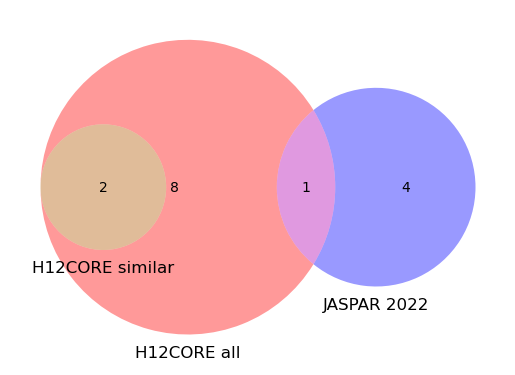

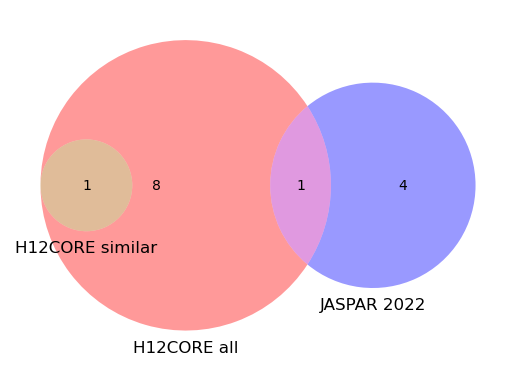

In [96]:
# read the file
significant_variants_hit_motifs_h12core_similar = pd.read_csv(os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variants_hit_motifs_removed_similar_motifs_H12Core_without_adapters.tsv'), sep='\t')
significant_variants_hit_motifs_h12core_similar

significant_variants_hit_motifs_h12core_all = pd.read_csv(os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variants_hit_motifs_without_adapters_allMotifs_H12CORE.tsv'), sep='\t')
significant_variants_hit_motifs_h12core_all

significant_variants_hit_motifs_jaspar2022_all = pd.read_csv(os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variants_hit_motifs_without_adapters_allMotifs_JASPAR_2022.tsv'), sep='\t')
significant_variants_hit_motifs_jaspar2022_all
alt_ids_jaspar_2022_all = set(significant_variants_hit_motifs_jaspar2022_all['tmp_variant_fimo_hit_ALT_ID'])

# set of alternative sequences
alt_ids_h12core_similar = set(significant_variants_hit_motifs_h12core_similar['tmp_variant_fimo_hit_ALT_ID'])
alt_ids_h12core_all = set(significant_variants_hit_motifs_h12core_all['tmp_variant_fimo_hit_ALT_ID'])
# overlap
overlap_h12core = alt_ids_h12core_similar.intersection(alt_ids_h12core_all)
print(f'Length of overlap of H12CORE similar and all motifs: {len(overlap_h12core)}')
print(f'Overlap of H12CORE similar and all motifs: {overlap_h12core}') # 2 since only 2 alternative sequences are in alt_ids_h12core_similar

# based on motif id:
motif_ids_h12core_similar = set(significant_variants_hit_motifs_h12core_similar['tmp_fimo_results_motif_id'])
motif_ids_h12core_all = set(significant_variants_hit_motifs_h12core_all['tmp_fimo_results_motif_id'])

# overlap
overlap_h12core_motif = motif_ids_h12core_similar.intersection(motif_ids_h12core_all)
# print the unique number of motifs in the lists
print(f'Number of unique motifs in H12CORE similar: {len(motif_ids_h12core_similar)}')
print(f'Number of unique motifs in H12CORE all: {len(motif_ids_h12core_all)}')
print(f'Length of overlap of H12CORE similar and all motifs: {len(overlap_h12core_motif)}')
print(f'Overlap of H12CORE similar and all motifs: {overlap_h12core_motif}') # 2 since only 2 alternative sequences are in alt_ids_h12core_similar

# print both tables with the motif is of 'ZN548.H12CORE.0.P.B'
significant_variants_hit_motifs_h12core_similar.loc[significant_variants_hit_motifs_h12core_similar['tmp_fimo_results_motif_id'] == 'ZN548.H12CORE.0.P.B']
# significant_variants_hit_motifs_h12core_all.loc[significant_variants_hit_motifs_h12core_all['tmp_fimo_results_motif_id'] == 'ZN548.H12CORE.0.P.B']

# check if the same alternative sequences are in the tables
alt_ids_h12core_similar = set(significant_variants_hit_motifs_h12core_similar['tmp_variant_fimo_hit_ALT_ID'])
alt_ids_h12core_all = set(significant_variants_hit_motifs_h12core_all['tmp_variant_fimo_hit_ALT_ID'])
# overlap
overlap_h12core = alt_ids_h12core_similar.intersection(alt_ids_h12core_all)
print(f'Length of overlap of H12CORE similar and all motifs: {len(overlap_h12core)}')
if len(overlap_h12core) == min(significant_variants_hit_motifs_h12core_similar.loc[significant_variants_hit_motifs_h12core_similar['tmp_fimo_results_motif_id'] == 'ZN548.H12CORE.0.P.B'].shape[0], significant_variants_hit_motifs_h12core_all.loc[significant_variants_hit_motifs_h12core_all['tmp_fimo_results_motif_id'] == 'ZN548.H12CORE.0.P.B'].shape[0]):
    print('The same alternative sequences are in the tables.')


# overlap with the JASPAR motifs (based on motifs found in alt_ids)
alt_id_overlap_h12core_all_jaspar_2022 = alt_ids_jaspar_2022_all.intersection(alt_ids_h12core_all)
print(f'Number of alternative sequences in H12CORE all {len(alt_ids_h12core_all)}')
print(f'Number of alternative sequences in JASPAR 2022: {len(alt_ids_jaspar_2022_all)}')
print(f'Length of overlap of H12CORE all and JASPAR 2022: {len(alt_id_overlap_h12core_all_jaspar_2022)}')
print(f'Overlap of H12CORE all and JASPAR 2022: {alt_id_overlap_h12core_all_jaspar_2022}')

# overlap is 'cardiac_neuro_cava_random:ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1_SRC|ENSG00000197122.13|EH38E2110584|20-37316592-C-T'
# check the tables with this alt_id 'cardiac_neuro_cava_random:ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1_SRC|ENSG00000197122.13|EH38E2110584|20-37316592-C-T'
h12core_all_overlap_alt_id_Jaspar = significant_variants_hit_motifs_h12core_all.loc[significant_variants_hit_motifs_h12core_all['tmp_variant_fimo_hit_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1_SRC|ENSG00000197122.13|EH38E2110584|20-37316592-C-T']
# https://hocomoco12.autosome.org/motif/SPI1.H12CORE.0.P.B#mainInfo
jaspar_all_overlap_alt_id_h12core = significant_variants_hit_motifs_jaspar2022_all.loc[significant_variants_hit_motifs_jaspar2022_all['tmp_variant_fimo_hit_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1_SRC|ENSG00000197122.13|EH38E2110584|20-37316592-C-T']

# check if both tmp_fimo_results_start  and tmp_fimo_results_stop are the same
h12core_all_overlap_alt_id_Jaspar[['tmp_fimo_results_start', 'tmp_fimo_results_stop']]
jaspar_all_overlap_alt_id_h12core[['tmp_fimo_results_start', 'tmp_fimo_results_stop']]
if h12core_all_overlap_alt_id_Jaspar[['tmp_fimo_results_start', 'tmp_fimo_results_stop']].equals(jaspar_all_overlap_alt_id_h12core[['tmp_fimo_results_start', 'tmp_fimo_results_stop']]):
    print('The start and stop positions are the same.')

jaspar_start = jaspar_all_overlap_alt_id_h12core['tmp_fimo_results_start'].to_list()
jaspar_stop = jaspar_all_overlap_alt_id_h12core['tmp_fimo_results_stop'].to_list()
print('jaspar')
print(jaspar_start, jaspar_stop)
h12core_start = h12core_all_overlap_alt_id_Jaspar['tmp_fimo_results_start'].to_list()
h12core_stop = h12core_all_overlap_alt_id_Jaspar['tmp_fimo_results_stop'].to_list()
print('h12core')
print(h12core_start, h12core_stop)

# check if the start and stop positions are the same
if jaspar_start == h12core_start and jaspar_stop == h12core_stop:
    print('The start and stop positions are the same.')
h12core_all_overlap_alt_id_Jaspar

# plot venn diagramm for alt ids
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
venn3([alt_ids_h12core_all, alt_ids_h12core_similar, alt_ids_jaspar_2022_all], ('H12CORE all', 'H12CORE similar', 'JASPAR 2022'))
plt.show()

# check overlap based on ref id
ref_ids_h12core_all = set(significant_variants_hit_motifs_h12core_all['tmp_variant_fimo_hit_REF_ID'])
ref_ids_h12core_similar = set(significant_variants_hit_motifs_h12core_similar['tmp_variant_fimo_hit_REF_ID'])
ref_ids_jaspar2022_all = set(significant_variants_hit_motifs_jaspar2022_all['tmp_variant_fimo_hit_REF_ID'])
# plot a venn diagramm of the overlap
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
venn3([ref_ids_h12core_all, ref_ids_h12core_similar, ref_ids_jaspar2022_all], ('H12CORE all', 'H12CORE similar', 'JASPAR 2022'))
plt.show()


In [97]:
jaspar_all_overlap_alt_id_h12core

,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence,ref_sequence,alt_sequence,tmp_variant_map_Variant_id,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val
4,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,97,MA0080.6_Spi1,95,111,-,0.00157,AGGAAGAGGAAGTGGTG,GCATTCCAGGCTCAGGGTCTGAGGAGGCTGTGACGCCCTATGACCG...,GCATTCCAGGCTCAGGGTCTGAGGAGGCTGTGACGCCCTATGACCG...,cardiac_neuro_cava_random:SRC|ENSG00000197122....,cardiac_neuro_cava_random:SRC|ENSG00000197122....,0.31041,4.446794e-07
5,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,97,MA0081.2_SPIB,95,110,+,0.00555,CACCACTTCCTCTTCC,GCATTCCAGGCTCAGGGTCTGAGGAGGCTGTGACGCCCTATGACCG...,GCATTCCAGGCTCAGGGTCTGAGGAGGCTGTGACGCCCTATGACCG...,cardiac_neuro_cava_random:SRC|ENSG00000197122....,cardiac_neuro_cava_random:SRC|ENSG00000197122....,0.31041,4.446794e-07


In [98]:
print(len(set(significant_variants_hit_motifs_h12core_all['tmp_variant_fimo_hit_ALT_ID'].to_list())))
significant_variants_hit_motifs_h12core_all['tmp_variant_fimo_hit_ALT_ID'].to_list()


11


['cardiac_neuro_cava_random:ALT_AHDC1|ENSG00000126705.15|EH38E1331682_rev_tile1-1_AHDC1|ENSG00000126705.15|EH38E1331682|1-27650996-T-C',
 'cardiac_neuro_cava_random:ALT_ATR|ENSG00000175054.16|EH38E3544373_rev_tile1-1_ATR|ENSG00000175054.16|EH38E3544373|3-142447396-C-G',
 'cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000168036.18|EH38E2194647_fwd_tile1-1_CTNNB1|ENSG00000168036.18|EH38E2194647|3-41158686-G-T',
 'cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000168036.18|EH38E2194647_fwd_tile1-1_CTNNB1|ENSG00000168036.18|EH38E2194647|3-41158686-G-T',
 'cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000168036.18|EH38E2194647_fwd_tile1-1_CTNNB1|ENSG00000168036.18|EH38E2194647|3-41158686-G-T',
 'cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000168036.18|EH38E2194647_fwd_tile1-1_CTNNB1|ENSG00000168036.18|EH38E2194647|3-41158686-G-T',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G

In [99]:
significant_variants_hit_motifs_h12core_all.loc[significant_variants_hit_motifs_h12core_all['tmp_fimo_results_motif_id'] == 'ZN548.H12CORE.0.P.B']

,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence,ref_sequence,alt_sequence,tmp_variant_map_Variant_id,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val
12,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,212,ZN548.H12CORE.0.P.B,204,226,-,0.000021,CAGGATGAAGGTGGGGGCAGGGC,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,cardiac_neuro_cava_random:MAX|ENSG00000125952....,cardiac_neuro_cava_random:MAX|ENSG00000125952....,-0.404497,3.323203e-14
13,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,206,ZN548.H12CORE.0.P.B,204,226,-,0.000730,CAGGATGAAGGTGGGGGCAGAGC,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,cardiac_neuro_cava_random:MAX|ENSG00000125952....,cardiac_neuro_cava_random:MAX|ENSG00000125952....,-0.317499,9.663900e-08


##### Make vcf file of all variants we have readouts for

In [100]:
### Temp position:
# make vcf of signifciant variants from variant based mpralm results
tested_bcMPRAlm_table = bcMPRAlm_table.loc[bcMPRAlm_table['tmp_variant_BECALM_variant_id'].str.startswith('cardiac_neuro_cava_random')]
# replace "," with "~" in the variant id
tested_bcMPRAlm_table['tmp_variant_BECALM_variant_id'] = tested_bcMPRAlm_table['tmp_variant_BECALM_variant_id'].str.replace(',', '~')

print(f"Number of all variants with readout from bcMPRAlm: {tested_bcMPRAlm_table.shape[0]}")
significant_variants = tested_bcMPRAlm_table.loc[tested_bcMPRAlm_table['tmp_variant_BECALM_adj.P.Val'] < 0.05]
print(f"Number of significant variants: {significant_variants.shape[0]}")
tested_variant_region_map_alt_variant_id = variant_region_map.loc[variant_region_map['tmp_variant_map_ALT_ID'].str.startswith('cardiac_neuro_cava_random')]



# merge with significant variants
tested_variant_region_map_alt_variant_id_bcMPRAlm = tested_bcMPRAlm_table.merge(tested_variant_region_map_alt_variant_id, left_on='tmp_variant_BECALM_variant_id', right_on='tmp_variant_map_Variant_id', how='left')
# make vcf from header (CHROM, POS, ID, REF, ALT, QUAL, FILTER, INFO)
tested_variant_region_map_alt_variant_id_bcMPRAlm['tmp_variant_map_Variant_id'].isna().sum()
# # 1. chrom_pos_ref_alt_pattern => split
tested_variant_region_map_alt_variant_id_bcMPRAlm['chr_pos_ref_alt'] = tested_variant_region_map_alt_variant_id_bcMPRAlm['tmp_variant_map_ALT_ID'].apply(hf.get_chrom_pos_ref_alt_pattern)
# split the chr_pos_ref_alt column into CHROM, POS, REF, ALT columns for VCF file
tested_variant_region_map_alt_variant_id_bcMPRAlm[['#CHROM', 'POS', 'REF', 'ALT']] = tested_variant_region_map_alt_variant_id_bcMPRAlm['chr_pos_ref_alt'].str.split('-', expand=True)

# add chr for CHROM (should not be done according to Thorben for the CADD webserver)
# tested_variant_region_map_alt_variant_id_bcMPRAlm['CHROM'] = 'chr' + tested_variant_region_map_alt_variant_id_bcMPRAlm['CHROM']

# QUAL = -10 * log10(adj.P-value)
tested_variant_region_map_alt_variant_id_bcMPRAlm['QUAL'] = -10 * np.log10(tested_variant_region_map_alt_variant_id_bcMPRAlm['tmp_variant_BECALM_adj.P.Val'])
# FILTER = PASS
tested_variant_region_map_alt_variant_id_bcMPRAlm['FILTER'] = 'PASS'
# INFO = "P-value"=P-value; "logFC"=logFC
tested_variant_region_map_alt_variant_id_bcMPRAlm['INFO'] = 'P-value=' + tested_variant_region_map_alt_variant_id_bcMPRAlm['tmp_variant_BECALM_adj.P.Val'].astype(str) + ';logFC=' + tested_variant_region_map_alt_variant_id_bcMPRAlm['tmp_variant_BECALM_logFC'].astype(str)
tested_variant_region_map_alt_variant_id_bcMPRAlm['ID'] = tested_bcMPRAlm_table['tmp_variant_BECALM_variant_id']

# write to file
vcf_columns = ['#CHROM', 'POS', 'ID', 'REF', 'ALT', 'QUAL', 'FILTER', 'INFO']
output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'all_80K_MPRA_variants_from_bcMPRAlm_bbmap_q35.vcf')
tested_variant_region_map_alt_variant_id_bcMPRAlm[vcf_columns].to_csv(output_path, sep='\t', index=False)


# with header upload failed: forgot adding ID

Number of all variants with readout from bcMPRAlm: 37996
Number of significant variants: 808


/tmp/ipykernel_250236/2301919466.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tested_bcMPRAlm_table['tmp_variant_BECALM_variant_id'] = tested_bcMPRAlm_table['tmp_variant_BECALM_variant_id'].str.replace(',', '~')


File written => remove filter and info column (less storage) => zip the result and sort it (removed the header)
- `(grep '^#' all_80K_MPRA_variants_from_bcMPRAlm_bbmap_q35.vcf; grep -v '^#' all_80K_MPRA_variants_from_bcMPRAlm_bbmap_q35.vcf) | sort -k1,1n -k2,2n | gzip -c > all_80K_MPRA_variants_from_bcMPRAlm_bbmap_q35_sorted.vcf.gz`

- uploaded to CADD server (german) => `https://cadd.bihealth.org/check_avail/GRCh38-v1.7_anno_99968cba0f45ff34bd9d5a4d06b36ea1.tsv.gz` + email notification (`Read 38015 lines, 38014 variants saved.`)
- you can add the following lines then: 
```bash 
##fileformat=VCFv4.2
##FILTER=<ID=minbc,Description="minimal 10 barcodes per Oligo">
##INFO=<ID=P-value,Number=A,Type=Float,Description="Adjusted P-Value from BECALM">
##INFO=<ID=logFC,Number=A,Type=Float,Description="LogFC of ALT - REF ">
##source=KilianSalomon
```


##### Investigate the Numbers of the motif variant overlap

In [101]:
tested_variant_region_map_alt_variant_id_bcMPRAlm.columns

Index(['tmp_variant_BECALM_variant_id', 'tmp_variant_BECALM_logFC',
       'tmp_variant_BECALM_adj.P.Val', 'tmp_variant_map_Variant_id',
       'tmp_variant_map_Region', 'tmp_variant_map_REF_ID',
       'tmp_variant_map_ALT_ID', 'chr_pos_ref_alt', '#CHROM', 'POS', 'REF',
       'ALT', 'QUAL', 'FILTER', 'INFO', 'ID'],
      dtype='object')

In [102]:
fimo_variants_hit_motif_cols_of_interest_mpralm

,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence,ref_sequence,alt_sequence,tmp_variant_map_Variant_id,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val
0,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,212,ZN548.H12CORE.0.P.B,204,226,-,0.000021,CAGGATGAAGGTGGGGGCAGGGC,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,cardiac_neuro_cava_random:MAX|ENSG00000125952....,cardiac_neuro_cava_random:MAX|ENSG00000125952....,-0.404497,3.323203e-14
1,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,212,ZN148.H12CORE.0.P.B,202,220,-,0.005940,GAAGGTGGGGGCAGGGCCT,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,cardiac_neuro_cava_random:MAX|ENSG00000125952....,cardiac_neuro_cava_random:MAX|ENSG00000125952....,-0.404497,3.323203e-14
2,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,139,ZNF3.H12CORE.0.P.B,138,160,+,0.000081,AATATTTGTTGAATGAATGGATG,AAGCGAGTCTCACCAGTGATGTCACACATCTGTTGATTGTCTCCTC...,AAGCGAGTCTCACCAGTGATGTCACACATCTGTTGATTGTCTCCTC...,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,-0.557990,8.564960e-10
3,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,SP5.H12CORE.1.P.B,91,115,-,0.000331,TTGGGGAGGGAGAGGGGAGGAGATG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02
4,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,ZN281.H12CORE.1.SM.B,99,124,-,0.003530,TGTGTGGCGTTGGGGAGGGAGAGGGG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02
5,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,ZN467.H12CORE.0.P.C,95,117,-,0.006210,CGTTGGGGAGGGAGAGGGGAGGA,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02
6,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,SP5.H12CORE.1.P.B,96,120,-,0.007080,TGGCGTTGGGGAGGGAGAGGGGAGG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02
7,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,193,ZN148.H12CORE.0.P.B,181,199,-,0.004440,GCAGGTGGGGGATGGGCCT,GAGTGATGACTGCTTGTAGGTATGTCTGTGCCATTTCTCAGGGAAG...,GAGTGATGACTGCTTGTAGGTATGTCTGTGCCATTTCTCAGGGAAG...,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,-0.411988,8.458337e-04
8,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,203,ZN467.H12CORE.0.P.C,194,216,-,0.005200,CTGGAAGGAAGGGGGGGGCAGGA,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,0.559425,3.894077e-07
9,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...

In [103]:
fimo_variants_hit_motif_cols_of_interest

,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence,ref_sequence,alt_sequence
0,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,212,ZN548.H12CORE.0.P.B,204,226,-,0.000021,CAGGATGAAGGTGGGGGCAGGGC,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...
1,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,212,ZN148.H12CORE.0.P.B,202,220,-,0.005940,GAAGGTGGGGGCAGGGCCT,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...
2,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,139,ZNF3.H12CORE.0.P.B,138,160,+,0.000081,AATATTTGTTGAATGAATGGATG,AAGCGAGTCTCACCAGTGATGTCACACATCTGTTGATTGTCTCCTC...,AAGCGAGTCTCACCAGTGATGTCACACATCTGTTGATTGTCTCCTC...
3,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,SP5.H12CORE.1.P.B,91,115,-,0.000331,TTGGGGAGGGAGAGGGGAGGAGATG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...
4,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,ZN281.H12CORE.1.SM.B,99,124,-,0.003530,TGTGTGGCGTTGGGGAGGGAGAGGGG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...
5,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,ZN467.H12CORE.0.P.C,95,117,-,0.006210,CGTTGGGGAGGGAGAGGGGAGGA,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...
6,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,SP5.H12CORE.1.P.B,96,120,-,0.007080,TGGCGTTGGGGAGGGAGAGGGGAGG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...
7,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,193,ZN148.H12CORE.0.P.B,181,199,-,0.004440,GCAGGTGGGGGATGGGCCT,GAGTGATGACTGCTTGTAGGTATGTCTGTGCCATTTCTCAGGGAAG...,GAGTGATGACTGCTTGTAGGTATGTCTGTGCCATTTCTCAGGGAAG...
8,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,203,ZN467.H12CORE.0.P.C,194,216,-,0.005200,CTGGAAGGAAGGGGGGGGCAGGA,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...
9,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,97,SPI1.H12CORE.0.P.B,97,110,-,0.004080,GGAAGAGGAAGTGG,GCATTCCAGGCTCAGGGTCTGAGGAGGCTGTGACGCCCTATGACCG...,GCATTCCAGGCTCAGGGTCTGAGGAGGCTGTGACGCCCTATGACCG...


In [104]:
# ### Write only a subset to test plotting:
# output_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variants_hit_motifs_subset_testing.csv')
# fimo_variants_hit_motif_cols_of_interest_uniq.head(4).to_csv(output_path, sep='\t', index=False)


In [105]:
### validate that sequences are correct:
alt_fimo_variants_hit_motif_cols_of_interest
# alt_fimo_variants_hit_motif_cols_of_interest['tmp_variant_fimo_hit_ALT_ID'].to_list()
# cardiac_neuro_cava_random:ALT_FLCN|ENSG00000154803.13|EH38E3211689_rev_tile1-1_FLCN|ENSG00000154803.13|EH38E3211689|17-17275890-C-T
# AGGACCGGATCAACTTATTTTTATTTATTTATTTATATTTTTTGAGATGGAGTTTCGCTCTGTCACCCAGGCTGGAGTGCAGTGGCACATTCTTAGCACACTGCAAGCTCCGCCTCCCGGGTTCACTCCATTCTCTTGCCTCAGCCTCTTGAGTAGCTGGGACTACAGGCACTCGCCACCCGCCCCAGCTAATTTTTGTATTTTTAGTAGAGACAGGGTTTCACCATGTTAGCCAGGATGATCTCGATCTCCTGACCTCTTGGTCCGCCCACCTTGGCCTCCCAACATTGCGTGAACCGA
# cardiac_neuro_cava_random:REF_FLCN|ENSG00000154803.13|EH38E3211689_rev_tile1-1
# alt_fimo_variants_hit_motif_cols_of_interest['tmp_variant_fimo_hit_REF_ID'].to_list()
# cardiac_neuro_cava_random:REF_FLCN|ENSG00000154803.13|EH38E3211689_rev_tile1-1
# AGGACCGGATCAACTTATTTTTATTTATTTATTTATATTTTTTGAGATGGAGTTTCGCTCTGTCACCCAGGCTGGAGTGCAGTGGCACATTCTTGGCACACTGCAAGCTCCGCCTCCCGGGTTCACTCCATTCTCTTGCCTCAGCCTCTTGAGTAGCTGGGACTACAGGCACTCGCCACCCGCCCCAGCTAATTTTTGTATTTTTAGTAGAGACAGGGTTTCACCATGTTAGCCAGGATGATCTCGATCTCCTGACCTCTTGGTCCGCCCACCTTGGCCTCCCAACATTGCGTGAACCGA
# - sequences seem fine, but C-T is actually G-A because the reverse complement is taken
# - checking variant position: it is given without considering the adapter (15 bp off)

,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence
0,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,[212],ZN548.H12CORE.0.P.B,204,226,-,0.000013,CAGGATGAAGGTGGTGGCAGGGC
1,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,[139],ZNF3.H12CORE.0.P.B,138,160,+,0.000081,AGTATTTGTTGAATGAATGGATG
2,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,[115],SP5.H12CORE.1.P.B,91,115,-,0.000331,CTGGGGAGGGAGAGGGGAGGAGATG
3,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,[115],ZN281.H12CORE.1.SM.B,99,124,-,0.003530,TGTGTGGCGCTGGGGAGGGAGAGGGG
4,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,[115],PATZ1.H12CORE.0.P.B,97,119,-,0.007610,GGCGCTGGGGAGGGAGAGGGGAG
5,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,[115],ZN467.H12CORE.0.P.C,95,117,-,0.005980,CGCTGGGGAGGGAGAGGGGAGGA
6,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,[115],SP5.H12CORE.1.P.B,96,120,-,0.005890,TGGCGCTGGGGAGGGAGAGGGGAGG
7,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,[206],ZN548.H12CORE.0.P.B,204,226,-,0.000730,CAGGATGAAGGTGGGGGCAGAGC
8,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,[203],KLF16.H12CORE.1.P.B,192,214,-,0.006530,GGAAGGAAGGGCGGGGCAGGATG
9,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,[203],ZN467.H12CORE.0.P.C,194,216,-,0.005980,CTGGAAGGAAGGGCGGGGCAGGA


In [106]:
asdfasdf

NameError: name 'asdfasdf' is not defined

In [107]:
fimo_variants_hit_motif_cols_of_interest['tmp_variant_fimo_hit_ALT_ID'].nunique()
# 2 for only non similar motifs without adapters
# 11 for all motifs without adapters

11

In [108]:
print(fimo_variants_hit_motif_cols_of_interest.shape[0])
print('Number of unique variants: ', fimo_variants_hit_motif_cols_of_interest['tmp_variant_fimo_hit_ALT_ID'].nunique())
fimo_variants_hit_motif_cols_of_interest.sort_values(by='tmp_variant_fimo_hit_ALT_ID')

unique_combinations = fimo_variants_hit_motif_cols_of_interest.groupby(['tmp_variant_fimo_hit_ALT_ID', 'tmp_fimo_results_motif_id', 'tmp_fimo_results_start', 'tmp_fimo_results_strand']).size().reset_index()
num_unique_combinations = len(unique_combinations)

print(f"Number of unique combinations: {num_unique_combinations}")
print(f"Number of unique motifs hit by significant variants: {fimo_variants_hit_motif_cols_of_interest['tmp_fimo_results_motif_id'].nunique()}")

# for all motifs without adapters
# 30
# 11 (different variants)
# Number of unique combinations: 21

# for only non similar motifs without adapters
# 3
# 2 (different variants)
# Number of unique combinations: 2

# JASPAR motifs
# 8
# Number of unique variants:  5
# Number of unique combinations: 6
# Number of unique motifs hit by significant variants: 5

30
Number of unique variants:  11
Number of unique combinations: 21
Number of unique motifs hit by significant variants: 11


In [109]:
unique_combinations

,tmp_variant_fimo_hit_ALT_ID,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_strand,0
0,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,ZNF3.H12CORE.0.P.B,138,+,2
1,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,PATZ1.H12CORE.0.P.B,191,-,1
2,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,SP5.H12CORE.1.P.B,176,+,1
3,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,SP5.H12CORE.1.P.B,181,+,2
4,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,ZN148.H12CORE.0.P.B,182,+,1
5,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,ZN467.H12CORE.0.P.C,180,+,1
6,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,KLF16.H12CORE.1.P.B,192,-,1
7,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,SP5.H12CORE.1.P.B,196,-,1
8,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,ZN467.H12CORE.0.P.C,194,-,2
9,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,ZN613.H12CORE.0.P.C,233,+,1


#### Running plot_alitnment_withPWM script (modified from Thorben)
- note: conda environment tf_analysis: `mamba create -n tf_analysis python=3.9 bioconda::meme matplotlib=3.9 numpy pandas click logomaker`
- first try with variants position changed for hits on minus strand (variant position = 270 - variant position)
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs.csv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /ho
me/kisa/coding/80K_MPRA/cava_analysis_output/plot_significant_variants_hit_motif.png`

- second try with reverse complement of the sequences and just one chunk
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs.csv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_significant_variants_hit_motif_ref_comp_minus_strand.png`


- using only unique subset of these columns: ['tmp_variant_fimo_hit_ALT_ID', 'tmp_fimo_results_motif_id', 'tmp_fimo_results_start', 'tmp_fimo_results_strand'] (23 results)
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs.csv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_significant_variants_hit_unique`

- testing improving plot: 
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs_subset_testing.csv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_testing_variants`
- variant position fixed: 0-based for removed similar motifs and without adapter: 
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs_removed_similar_motifs_H12Core_without_adapters.tsv --PWMsFile /data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant_removed_similar_motifs_tomtom.txt --chunk_size 1 --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_variants_without_adapter_removed_similar_motifs_H12Core`
- only 2 varaints (same motif)

- variant position fixed: 0-based for all and without adapter: 
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs_without_adapters_allMotifs_H12CORE.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 -- --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_variants_without_adapter_all_motifs_H12Core`
- 11 varaints

- annotated with variant effect: 
- all motifs: without adapters:
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs_without_adapters_allMotifs_H12CORE.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --variantEffectColumn tmp_variant_BECALM_logFC --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_variants_logFC_without_adapter_all_motifs_H12Core`

- with different plottingBackground: 0.1: 
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs_without_adapters_allMotifs_H12CORE.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --variantEffectColumn tmp_variant_BECALM_logFC --plottingBackground 0.1 --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_variants_logFC_without_adapter_all_motifs_H12Core_bg_01`

- only non similar motifs: 
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs_removed_similar_motifs_H12Core_without_adapters.tsv --PWMsFile /data/cephfs-2/unmirrored/groups/kircher/MPRA/MPRA_ultra/projects/motif_analysis/resources/H12CORE_less_redundant_removed_similar_motifs_tomtom.txt --chunk_size 1 --variantEffectColumn tmp_variant_BECALM_logFC --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_variants_logFC_without_adapter_removed_similar_motifs_H12Core`


- USING JASPAR: 
significant_variants_hit_motifs_without_adapters_allMotifs_JASPAR_2022
- all motifs: without adapters:
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs_without_adapters_allMotifs_JASPAR_2022.tsv --PWMsFile /data/cephfs-2/unmirrored/groups/kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/JASPAR2022_CORE_vertebrates_non-redundant_pfms_meme_nice.txt --chunk_size 1 --variantEffectColumn tmp_variant_BECALM_logFC --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_variants_logFC_without_adapter_all_motifs_JASPAR_2022`

- added hocomoco links to the plot: (not working)
`python /home/kisa/coding/80K_MPRA/80K-Analysis/06_variant_element_analysis/scripts/plot_alignment_withPWM_thorben.py --aligMotifFile /home/kisa/coding/80K_MPRA/cava_analysis_output/significant_variants_hit_motifs_without_adapters_allMotifs_H12CORE.tsv --PWMsFile /home/kisa/coding/80K_MPRA/fimo_data/H12CORE_less_redundant.meme --chunk_size 1 --variantEffectColumn tmp_variant_BECALM_logFC --hocomoco True --output /home/kisa/coding/80K_MPRA/cava_analysis_output/plot_variants_logFC_without_adapter_all_motifs_H12Core_with_motiflinks`

In [110]:
ref_fimo_variants_hit_motif['tmp_variant_fimo_hit_ALT_ID']

31     cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...
32     cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...
36     cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...
59     cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
60     cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
67     cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
68     cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
72     cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...
78     cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...
101    cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...
103    cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...
104    cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...
105    cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...
106    cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...
108    cardiac_neuro_cava_random:ALT_RAD51|ENSG000000...
Name: tmp_variant_fimo_hit_ALT_ID, dtype: object

In [111]:
variant_region_map.columns
alt_fimo_variants_hit_motif.columns

Index(['tmp_fimo_results_motif_id', 'name', 'tmp_variant_map_ALT_ID',
       'tmp_fimo_ref_alt_variant_pos', 'tmp_fimo_results_start',
       'tmp_fimo_results_stop', 'tmp_fimo_results_strand',
       'tmp_fimo_results_q-value', 'tmp_variant_hits_motif',
       'tmp_one_motif_is_hit_by_variant', 'tmp_fimo_results_matched_sequence',
       'tmp_variant_fimo_hit_ALT_ID', 'tmp_variant_map_header_ALT_ID',
       'tmp_variant_map_REF_ID', 'tmp_variant_fimo_hit_REF_ID',
       'tmp_variant_fimo_hit_variant_pos'],
      dtype='object')

### Biological findings from Motifs overlapping significant variants (Which TFBSs are responsible for the significant variant effects?)

#### Investigate AF: Lea asked for GWAS overlap
1. Get AF of the variants: 
- table of alt_id, chrom, pos, ref, alt
- store to `/data/cephfs-1/home/users/kisa11_c/unmirrored/projects/MPRA/IGVF_Y1_design/projects/gnomadDB`
2. Run gnomad script
3. Get the common significant variants 
4. look into gwas catalog for any hits

In [112]:
element_analaysis_becalm_df_variant_info_becalm.columns

Index(['tmp_element_BECALM_id', 'tmp_element_BECALM_adj.P.Val',
       'tmp_element_BECALM_logFC', 'tmp_variant_map_Variant_id',
       'tmp_variant_map_Region', 'tmp_variant_map_REF_ID',
       'tmp_variant_map_ALT_ID', 'tmp_variant_BECALM_variant_id',
       'tmp_variant_BECALM_logFC', 'tmp_variant_BECALM_adj.P.Val',
       'is_element', 'is_variant', 'tmp_gene_name', 'gene_set', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random', 'is_cava_is_element',
       'is_cava_is_variant', 'element_is_significant',
       'variant_is_significant', 'variant_is_cava_is_significant',
       'element_is_cava_is_significant'],
      dtype='object')

In [113]:
cava_variants = element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['is_cava_is_variant']]
print(cava_variants['tmp_element_BECALM_id'].nunique())
# get chrom_pos_ref_alt pattern
cava_variants['tmp_chrom_pos_ref_alt'] = cava_variants['tmp_variant_map_ALT_ID'].apply(hf.get_chrom_pos_ref_alt_pattern)

# split in columns: chrom, pos, ref, alt
cava_variants[['chrom', 'pos', 'ref', 'alt']] = cava_variants['tmp_chrom_pos_ref_alt'].str.split('-', expand=True)

# write to file
output_path = os.path.join('/data/cephfs-1/home/users/kisa11_c/unmirrored/projects/MPRA/IGVF_Y1_design/projects/gnomadDB', 'cava_variants_for_gnomadDB.tsv')
gnomad_cols = ['tmp_variant_map_ALT_ID', 'chrom', 'pos', 'ref', 'alt']

# cava_variants[gnomad_cols].to_csv(output_path, sep='\t', index=False)

# var_df.to_csv(output_path, sep='\t', index=False)
# cava_variants['chrom'].value_counts()
# 14    1374
# 1      984
# 6      620
# 16     619
# 11     529
# 3      429
# 7      325
# 20     308
# 15     291
# 17     258
# 22     233
# 18     219
# 13     130
# 8      117
# X       95
# 5       82
# 2       48
# 10      33

1480


/tmp/ipykernel_250236/88717175.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cava_variants['tmp_chrom_pos_ref_alt'] = cava_variants['tmp_variant_map_ALT_ID'].apply(hf.get_chrom_pos_ref_alt_pattern)
/tmp/ipykernel_250236/88717175.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cava_variants[['chrom', 'pos', 'ref', 'alt']] = cava_variants['tmp_chrom_pos_ref_alt'].str.split('-', expand=True)
/tmp/ipykernel_250236/88717175.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [115]:
# import results from gnomadDB
af_cava_variants = pd.read_csv('/data/cephfs-1/home/users/kisa11_c/unmirrored/projects/MPRA/IGVF_Y1_design/projects/gnomadDB/cava_variants_for_gnomadDB_with_AF.tsv', sep='\t')
af_cava_variants

,tmp_variant_map_ALT_ID,chrom,pos,ref,alt,AF
0,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,14,68473929,A,G,0.000007
1,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,14,68473944,T,C,0.000013
2,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,14,68473959,C,T,0.000013
3,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,14,68474011,G,C,0.000039
4,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,14,68474012,T,C,0.000007
...,...,...,...,...,...,...
6689,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,14,68560298,G,T,0.000099
6690,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,14,67977718,T,A,0.000013
6691,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,14,67977745,A,G,0.015501
6692,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,14,67977785,A,G,0.000020


In [116]:
# add to cava analysis table
cava_variants = cava_variants.merge(af_cava_variants[['tmp_variant_map_ALT_ID', 'AF']], on='tmp_variant_map_ALT_ID', how='left')

In [117]:
cava_variants.columns

Index(['tmp_element_BECALM_id', 'tmp_element_BECALM_adj.P.Val',
       'tmp_element_BECALM_logFC', 'tmp_variant_map_Variant_id',
       'tmp_variant_map_Region', 'tmp_variant_map_REF_ID',
       'tmp_variant_map_ALT_ID', 'tmp_variant_BECALM_variant_id',
       'tmp_variant_BECALM_logFC', 'tmp_variant_BECALM_adj.P.Val',
       'is_element', 'is_variant', 'tmp_gene_name', 'gene_set', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random', 'is_cava_is_element',
       'is_cava_is_variant', 'element_is_significant',
       'variant_is_significant', 'variant_is_cava_is_significant',
       'element_is_cava_is_significant', 'tmp_chrom_pos_ref_alt', 'chrom',
       'pos', 'ref', 'alt', 'AF'],
      dtype='object')

In [118]:
cava_variants['is_common_variant'] = cava_variants['AF'] > 0.01

# number of significant variants in cava analysis
n_cava_significant_variants = cava_variants.loc[cava_variants['variant_is_significant']].shape[0] # 141
cava_significant_variants = cava_variants.loc[cava_variants['variant_is_significant']] # 141
n_cava_common_significant_variants = cava_variants.loc[cava_variants['is_common_variant'] & cava_variants['variant_is_significant']].shape[0] # 25
cava_common_significant_variants = cava_variants.loc[cava_variants['is_common_variant'] & cava_variants['variant_is_significant']] # 25

n_cava_significant_variants/n_cava_common_significant_variants # 5.64

5.64

In [119]:
cava_common_significant_variants['tmp_gene_name'].value_counts()
cava_common_significant_variants['tmp_gene_name'].nunique() # 16
# IRF4       5
# FARS2      3
# FLCN       2
# FANCM      2
# MALT1      2
# G6PD       1
# CYP2D6     1
# CARD11     1
# LMNA       1
# MRE11      1
# CYP2C19    1
# SFPQ       1
# RAD51B     1
# BRCA2      1
# SDHB       1
# ATR        1

# print the values of AF and logFC rounded to 2 decimal places
print(cava_common_significant_variants[['tmp_gene_name', 'tmp_chrom_pos_ref_alt', 'AF', 'tmp_variant_BECALM_logFC', 'tmp_element_BECALM_logFC']].round(2).sort_values(by=['tmp_gene_name','tmp_variant_BECALM_logFC'], ascending=False))
# print(cava_common_significant_variants[['tmp_gene_name', 'tmp_chrom_pos_ref_alt', 'AF', 'tmp_variant_BECALM_logFC', 'tmp_element_BECALM_logFC']].sort_values(by=['tmp_gene_name','tmp_variant_BECALM_logFC'], ascending=False))
print(cava_common_significant_variants[['tmp_gene_name', 'tmp_chrom_pos_ref_alt', 'AF', 'tmp_variant_BECALM_logFC', 'tmp_element_BECALM_logFC']].sort_values(by=['tmp_variant_BECALM_logFC'], ascending=False))


     tmp_gene_name tmp_chrom_pos_ref_alt    AF  tmp_variant_BECALM_logFC  \
3981          SFPQ        1-35210852-A-T  0.25                      0.67   
5077          SDHB        1-17052140-C-T  0.56                      0.19   
4340        RAD51B       14-68575599-A-G  0.09                     -0.36   
1555         MRE11       11-94537016-A-G  0.31                     -0.21   
6478         MALT1       18-58699861-T-C  0.12                      0.37   
5697         MALT1       18-58629988-A-G  0.18                      0.27   
2428          LMNA       1-156178005-C-A  0.27                     -0.32   
6085          IRF4          6-357046-A-G  0.09                      0.40   
5778          IRF4          6-405889-C-T  0.02                      0.23   
40            IRF4          6-411554-C-A  0.12                     -0.16   
4029          IRF4          6-434953-C-T  0.03                     -0.26   
4224          IRF4          6-396321-C-T  0.10                     -0.55   
1367        

#### Investigate high activity elements

In [120]:
element_analaysis_becalm_df_variant_info_becalm.columns

Index(['tmp_element_BECALM_id', 'tmp_element_BECALM_adj.P.Val',
       'tmp_element_BECALM_logFC', 'tmp_variant_map_Variant_id',
       'tmp_variant_map_Region', 'tmp_variant_map_REF_ID',
       'tmp_variant_map_ALT_ID', 'tmp_variant_BECALM_variant_id',
       'tmp_variant_BECALM_logFC', 'tmp_variant_BECALM_adj.P.Val',
       'is_element', 'is_variant', 'tmp_gene_name', 'gene_set', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random', 'is_cava_is_element',
       'is_cava_is_variant', 'element_is_significant',
       'variant_is_significant', 'variant_is_cava_is_significant',
       'element_is_cava_is_significant'],
      dtype='object')

In [121]:
cava_all_elements = element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['is_cava_is_element']] # 6847

# add AF to cava_all_elements
cava_all_elements = cava_all_elements.merge(af_cava_variants[['tmp_variant_map_ALT_ID', 'AF']], on='tmp_variant_map_ALT_ID', how='left')


highest_activity_threshold = 0.5
print(f'Numbers for highest activity threshold: {highest_activity_threshold}')
# highest active elements
cava_highest_active_elements = cava_all_elements.loc[cava_all_elements['tmp_element_BECALM_logFC'] > highest_activity_threshold] #9

print(f'Number of highest active elements (logFC >{highest_activity_threshold}): {cava_highest_active_elements.shape[0]}')

# gene names of highest active elements

print('Associated genes:\n', cava_highest_active_elements['tmp_gene_name'].value_counts())
print('Associated genes:\n', cava_highest_active_elements['tmp_gene_name'].unique())
# CYP2D6    7
# BCL10     1
# FLCN      1


# significant variants of highest active elements
print(f'Number of significant variants of highest active elements: {cava_highest_active_elements.loc[cava_highest_active_elements["variant_is_significant"]].shape[0]}')


# print gene names of the significant varaints
print('Associated genes of significant variants:\n', cava_highest_active_elements.loc[cava_highest_active_elements["variant_is_significant"]]['tmp_gene_name'].value_counts())
print('Associated genes of significant variants:\n', cava_highest_active_elements.loc[cava_highest_active_elements["variant_is_significant"]]['tmp_gene_name'].unique())

# print logFC of the significant variants
print('LogFC of significant variants of highest active elements:\n', cava_highest_active_elements.loc[cava_highest_active_elements["variant_is_significant"]]['tmp_variant_BECALM_logFC'].value_counts())

# number of positive and negative logFC
print('Number of positive and negative logFC of significant variants of highest active elements:\n', cava_highest_active_elements.loc[cava_highest_active_elements["variant_is_significant"]]['tmp_variant_BECALM_logFC'].apply(lambda x: 'positive' if x > 0 else 'negative').value_counts())
# to be continued:
# print(f'Number of common significant variants of highest active elements: {cava_highest_active_elements.loc[cava_highest_active_elements["is_common_variant"] & cava_highest_active_elements["variant_is_significant"]].shape[0]}')
cava_highest_active_elements_significant_variants = cava_highest_active_elements.loc[cava_highest_active_elements['variant_is_significant']]
cava_highest_active_elements_significant_variants['tmp_chrom_pos_ref_alt'] = cava_highest_active_elements_significant_variants['tmp_variant_map_ALT_ID'].apply(hf.get_chrom_pos_ref_alt_pattern)
cava_highest_active_elements_significant_variants[['tmp_element_BECALM_id', 'tmp_chrom_pos_ref_alt', 'AF', 'tmp_gene_name', 'tmp_variant_BECALM_logFC']].sort_values(by='tmp_variant_BECALM_logFC', ascending=False)
cava_highest_active_elements_significant_variants['tmp_element_BECALM_id'].to_list()

Numbers for highest activity threshold: 0.5
Number of highest active elements (logFC >0.5): 86
Associated genes:
 RAD51B    32
MAX       14
CARD11    13
SRC       11
CYP2D6     7
AHDC1      4
LMNA       3
FLCN       1
BCL10      1
Name: tmp_gene_name, dtype: int64
Associated genes:
 ['RAD51B' 'CYP2D6' 'BCL10' 'MAX' 'FLCN' 'AHDC1' 'CARD11' 'LMNA' 'SRC']
Number of significant variants of highest active elements: 8
Associated genes of significant variants:
 CYP2D6    3
MAX       2
RAD51B    2
CARD11    1
Name: tmp_gene_name, dtype: int64
Associated genes of significant variants:
 ['CYP2D6' 'MAX' 'CARD11' 'RAD51B']
LogFC of significant variants of highest active elements:
 -0.365879    1
 0.799875    1
-0.960738    1
-0.404497    1
-0.317499    1
-0.272523    1
 0.574460    1
-0.629702    1
Name: tmp_variant_BECALM_logFC, dtype: int64
Number of positive and negative logFC of significant variants of highest active elements:
 negative    6
positive    2
Name: tmp_variant_BECALM_logFC, dtype:

/tmp/ipykernel_250236/2952237534.py:39: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cava_highest_active_elements_significant_variants['tmp_chrom_pos_ref_alt'] = cava_highest_active_elements_significant_variants['tmp_variant_map_ALT_ID'].apply(hf.get_chrom_pos_ref_alt_pattern)


['cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_MAX|ENSG00000125952.20|EH38E1721673_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_MAX|ENSG00000125952.20|EH38E1721673_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_CARD11|ENSG00000198286.11|EH38E3754773_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_RAD51B|ENSG00000182185.19|EH38E1723809_fwd_tile1-1',
 'cardiac_neuro_cava_random:REF_RAD51B|ENSG00000182185.19|EH38E1723809_fwd_tile1-1']

In [169]:
cava_highest_active_elements_significant_variants.loc[cava_highest_active_elements_significant_variants['tmp_gene_name'] == "CARD11"]['tmp_element_BECALM_id'].to_list()
cava_highest_active_elements_significant_variants.loc[cava_highest_active_elements_significant_variants['tmp_gene_name'] == "CARD11"]['tmp_variant_map_ALT_ID'].to_list()
cava_highest_active_elements_significant_variants.loc[cava_highest_active_elements_significant_variants['tmp_gene_name'] == "CARD11"].columns
# cardiac_neuro_cava_random:REF_CARD11|ENSG00000198286.11|EH38E3754773_rev_tile1-1, cardiac_neuro_cava_random:ALT_CARD11|ENSG00000198286.11|EH38E3754773_rev_tile1-1_CARD11|ENSG00000198286.11|EH38E3754773|7-3067407-T-C
# ref: 0.840463
# variant logfc: -0.272523
# af: 0.000026
# 7-3067407-T-C

Index(['tmp_element_BECALM_id', 'tmp_element_BECALM_adj.P.Val',
       'tmp_element_BECALM_logFC', 'tmp_variant_map_Variant_id',
       'tmp_variant_map_Region', 'tmp_variant_map_REF_ID',
       'tmp_variant_map_ALT_ID', 'tmp_variant_BECALM_variant_id',
       'tmp_variant_BECALM_logFC', 'tmp_variant_BECALM_adj.P.Val',
       'is_element', 'is_variant', 'tmp_gene_name', 'gene_set', 'is_neuro',
       'is_cardiac', 'is_cava', 'is_random', 'is_cava_is_element',
       'is_cava_is_variant', 'element_is_significant',
       'variant_is_significant', 'variant_is_cava_is_significant',
       'element_is_cava_is_significant', 'AF', 'tmp_chrom_pos_ref_alt'],
      dtype='object')

#### Lea: full-data-set genes

In [123]:
full_dataset_genes = ["IRF4", "G6PD", "CARD11", "CYP2C19", "SFPQ"]

In [162]:
# cardiac_neuro_cava_random:ALT_IRF4|ENSG00000137265.16|EH38E2438413_fwd_tile1-1_IRF4|ENSG00000137265.16|EH38E2438413|6-408346-C-A # motif lost according to full length fimo results
element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_IRF4|ENSG00000137265.16|EH38E2438413_fwd_tile1-1_IRF4|ENSG00000137265.16|EH38E2438413|6-408346-C-A']

# element logFC: 0.35389
# variant logFC: -0.411988



,tmp_element_BECALM_id,tmp_element_BECALM_adj.P.Val,tmp_element_BECALM_logFC,tmp_variant_map_Variant_id,tmp_variant_map_Region,tmp_variant_map_REF_ID,tmp_variant_map_ALT_ID,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val,...,is_neuro,is_cardiac,is_cava,is_random,is_cava_is_element,is_cava_is_variant,element_is_significant,variant_is_significant,variant_is_cava_is_significant,element_is_cava_is_significant
22477,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,8.635605e-16,0.35389,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,-0.411988,0.000846,...,False,False,True,False,True,True,True,True,True,True


#### Investigate the overlap of the different motif and variant hits


In [124]:
variants_hit_motifs_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_variants_hit_motifs_without_adapters_allMotifs_H12CORE.tsv')
variants_hit_motifs = pd.read_csv(variants_hit_motifs_path, sep='\t')
variants_hit_motifs

significant_fimo_results_path = os.path.join(config['files']['creating']['cava_analysis']['output_path'], 'significant_fimo_results_H12CORE_without_adapters.tsv')
significant_fimo_results = pd.read_csv(significant_fimo_results_path, sep='\t')
significant_fimo_results
# add the label to the sequence_name again
significant_fimo_results['header'] = 'cardiac_neuro_cava_random:' + significant_fimo_results['sequence_name']
significant_fimo_results

,motif_id,motif_alt_id,sequence_name,start,stop,strand,score,p-value,q-value,matched_sequence,header
0,ZN441.H12CORE.1.P.C,NaN,REF_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,27,57,+,47.1224,5.280000e-16,3.390000e-11,TTGAGATGGAGTTTCGCTCTGTCACCCAGGC,cardiac_neuro_cava_random:REF_FLCN|ENSG0000015...
1,ZN441.H12CORE.1.P.C,NaN,ALT_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,27,57,+,47.1224,5.280000e-16,3.390000e-11,TTGAGATGGAGTTTCGCTCTGTCACCCAGGC,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...
2,ZN560.H12CORE.0.P.C,NaN,REF_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,48,70,-,40.2887,1.800000e-14,1.200000e-09,CCACTGCACTCCAGCCTGGGTGA,cardiac_neuro_cava_random:REF_FLCN|ENSG0000015...
3,ZN560.H12CORE.0.P.C,NaN,ALT_FLCN|ENSG00000154803.13|EH38E3211689_rev_t...,48,70,-,40.2887,1.800000e-14,1.200000e-09,CCACTGCACTCCAGCCTGGGTGA,cardiac_neuro_cava_random:ALT_FLCN|ENSG0000015...
4,ZN362.H12CORE.0.P.C,NaN,ALT_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,182,204,-,29.8254,9.030000e-11,5.850000e-06,AAAAAGAAAAAAGAAAAAAAAAG,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...
...,...,...,...,...,...,...,...,...,...,...,...
271,ZN467.H12CORE.0.P.C,NaN,ALT_RAD51B|ENSG00000182185.19|EH38E3101301_fwd...,62,84,+,14.5161,3.170000e-06,9.980000e-03,CCAGGGAGTGGGCGGGAGGAGGA,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...
272,ZN362.H12CORE.0.P.C,NaN,ALT_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,176,198,-,11.2381,3.210000e-06,8.000000e-03,AAAAAAGAAAAAAAAAGAAGTAA,cardiac_neuro_cava_random:ALT_ATM|ENSG00000149...
273,ZN362.H12CORE.0.P.C,NaN,REF_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,176,198,-,11.2381,3.210000e-06,8.000000e-03,AAAAAAGAAAAAAAAAGAAGTAA,cardiac_neuro_cava_random:REF_ATM|ENSG00000149...
274,ZN362.H12CORE.0.P.C,NaN,ALT_RAD51B|ENSG00000182185.19|EH38E3101125_fwd...,128,150,-,10.8730,3.760000e-06,9.010000e-03,ATGGGGGAAAAAAAAAGAAAAAG,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...


In [125]:
## investigate number of unique sequences with a motif hit
print(f"Number of different sequences: {significant_fimo_results['sequence_name'].nunique()}")
print(f"Number of different motifs found: {significant_fimo_results['motif_id'].nunique()}")

# check different combinations of sequence_name and motif_id:
print(f"Number of unique combinations of sequence_name and motif_id: {significant_fimo_results.groupby(['sequence_name', 'motif_id']).size().reset_index().shape[0]}")

Number of different sequences: 88
Number of different motifs found: 39
Number of unique combinations of sequence_name and motif_id: 177


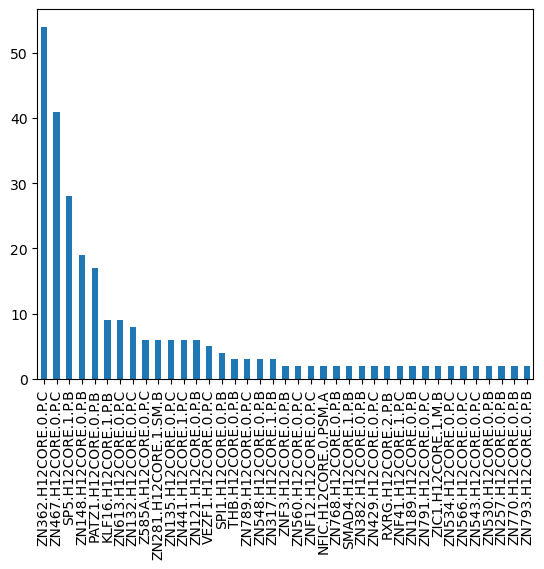

In [126]:
# plot the number of motifs found in the sequences (histogram per motif id)
# add a title: Among the significant variants, significant_fimo_results.groupby(['sequence_name', 'motif_id']).size().reset_index().shape[0] sequence motif combinations were found to be significant.
significant_fimo_results['motif_id'].value_counts().plot(kind='bar')
plt.show()

In [127]:
significant_fimo_results['sequence_name'].value_counts().reset_index(name='count')
# some sequences are found to have many motifs

,index,count
0,ALT_LMNA|ENSG00000160789.24|EH38E1387656_fwd_t...,18
1,REF_LMNA|ENSG00000160789.24|EH38E1387656_fwd_t...,18
2,ALT_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,18
3,REF_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,18
4,ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd...,12
...,...,...
83,REF_SDHAF2|ENSG00000167985.7|EH38E2960531_fwd_...,1
84,ALT_FH|ENSG00000091483.8|EH38E1437047_rev_tile...,1
85,REF_FH|ENSG00000091483.8|EH38E1437047_rev_tile1-1,1
86,REF_FLCN|ENSG00000154803.13|EH38E3211698_rev_t...,1


In [128]:
significant_fimo_results.groupby(['sequence_name', 'motif_id']).size().reset_index()

,sequence_name,motif_id,0
0,ALT_AHDC1|ENSG00000126705.15|EH38E1331682_rev_...,ZIC1.H12CORE.1.M.B,1
1,ALT_AHDC1|ENSG00000126705.15|EH38E1331682_rev_...,ZNF3.H12CORE.0.P.B,1
2,ALT_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,Z585A.H12CORE.0.P.C,3
3,ALT_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,ZN362.H12CORE.0.P.C,11
4,ALT_ATM|ENSG00000149311.20|EH38E1567637_fwd_ti...,ZN613.H12CORE.0.P.C,4
...,...,...,...
172,REF_SRC|ENSG00000197122.13|EH38E2110582_fwd_ti...,PATZ1.H12CORE.0.P.B,1
173,REF_SRC|ENSG00000197122.13|EH38E2110582_fwd_ti...,SPI1.H12CORE.0.P.B,1
174,REF_SRC|ENSG00000197122.13|EH38E2110582_fwd_ti...,ZN768.H12CORE.0.P.B,1
175,REF_SRC|ENSG00000197122.13|EH38E2110584_fwd_ti...,SPI1.H12CORE.0.P.B,1


Which variants reference overlapping a motif has a high logFC?

In [129]:
# TODO:

#### Not all Alternatives and References of the significant variants which hit a motif are within the significant fimo results with the associated motif
- check the original fimo results with significant hits: are the references or alternatives found to have this motif?

| alt_id_associated_with_same_motif | ref_id_associated_with_same_motif | count |
|----------------------------------|------------------------------------|-------|
| True                             | True                               | 10    |
| False                            | True                               | 6     |
| True                             | False                              | 5     |
- 21 variants with motif hits
- 6 motif only found in ref 
- 5 motif only found in alt
- investigate number of unique variants: 

    | alt_id_associated_with_same_motif | ref_id_associated_with_same_motif | count |
    |----------------------------------|------------------------------------|-------|
    | False                            | True                               | 4     |
    | True                             | False                              | 4     |
    | True                             | True                               | 7     |

Make a true false column for ref and alt in the variants_hit_motifs file 

In [130]:
significant_fimo_results.columns

Index(['motif_id', 'motif_alt_id', 'sequence_name', 'start', 'stop', 'strand',
       'score', 'p-value', 'q-value', 'matched_sequence', 'header'],
      dtype='object')

In [131]:

# add new column for sequence and motif id
significant_fimo_results['tmp_new_seq_motif_id'] = significant_fimo_results['header'] + "_" + significant_fimo_results['motif_id'] + "_" + significant_fimo_results['start'].astype(str) + "_" + significant_fimo_results['stop'].astype(str) + "_" + significant_fimo_results['strand']


In [132]:
variants_hit_motifs['tmp_variant_fimo_hit_ALT_ID'].nunique()

11

In [133]:
variants_hit_motifs
# add new column for sequence and motif id
variants_hit_motifs['tmp_new_alt_seq_motif_id'] = variants_hit_motifs['tmp_variant_fimo_hit_ALT_ID'] + "_" + variants_hit_motifs['tmp_fimo_results_motif_id'] + "_" + variants_hit_motifs['tmp_fimo_results_start'].astype(str) + "_" + variants_hit_motifs['tmp_fimo_results_stop'].astype(str) + "_" + variants_hit_motifs['tmp_fimo_results_strand']
variants_hit_motifs['tmp_new_ref_seq_motif_id'] = variants_hit_motifs['tmp_variant_fimo_hit_REF_ID'] + "_" + variants_hit_motifs['tmp_fimo_results_motif_id'] + "_" + variants_hit_motifs['tmp_fimo_results_start'].astype(str) + "_" + variants_hit_motifs['tmp_fimo_results_stop'].astype(str) + "_" + variants_hit_motifs['tmp_fimo_results_strand']

In [134]:
variants_hit_motifs['alt_id_associated_with_same_motif'] = variants_hit_motifs['tmp_new_alt_seq_motif_id'].isin(significant_fimo_results['tmp_new_seq_motif_id'])
variants_hit_motifs['ref_id_associated_with_same_motif'] = variants_hit_motifs['tmp_new_ref_seq_motif_id'].isin(significant_fimo_results['tmp_new_seq_motif_id'])
variants_hit_motifs

variants_hit_motifs[['alt_id_associated_with_same_motif', 'ref_id_associated_with_same_motif']].value_counts()

# alt_id_associated_with_same_motif  ref_id_associated_with_same_motif
# True                               True                                 10
# False                              True                                  6
# True                               False                                 5
# prepare markdown table:
# | alt_id_associated_with_same_motif | ref_id_associated_with_same_motif | count |
# |----------------------------------|------------------------------------|-------|
# | True                             | True                               | 10    |
# | False                            | True                               | 6     |
# | True                             | False                              | 5     |

# number of differnt alt_ids for these groups
variants_hit_motifs.groupby(['alt_id_associated_with_same_motif', 'ref_id_associated_with_same_motif'])['tmp_variant_fimo_hit_ALT_ID'].nunique()

# prepare markdown table:
# | alt_id_associated_with_same_motif | ref_id_associated_with_same_motif | count |
# |----------------------------------|------------------------------------|-------|
# | False                            | True                               | 4     |
# | True                             | False                              | 4     |
# | True                             | True                               | 7     |

alt_id_associated_with_same_motif  ref_id_associated_with_same_motif
False                              True                                 4
True                               False                                4
                                   True                                 7
Name: tmp_variant_fimo_hit_ALT_ID, dtype: int64

In [135]:
# Show the examples of the rows where only alt (knock in motif) or ref (knocked out motif) is found in the fimo results
# only ref: if alt_id_associated_with_same_motif is False
variants_hit_motifs.loc[variants_hit_motifs['alt_id_associated_with_same_motif'] == False] # 6 results (CTNNB1 (3), IRF4, MAX, RAD51)


# only alt: if ref_id_associated_with_same_motif is False (knock in motif)
variants_hit_motifs.loc[variants_hit_motifs['ref_id_associated_with_same_motif'] == False] # 5 results: (ATR, CYP2D6 (3), CRAD51B)
variants_hit_motifs.loc[variants_hit_motifs['ref_id_associated_with_same_motif'] == False]['tmp_variant_fimo_hit_ALT_ID'].to_list()



['cardiac_neuro_cava_random:ALT_ATR|ENSG00000175054.16|EH38E3544373_rev_tile1-1_ATR|ENSG00000175054.16|EH38E3544373|3-142447396-C-G',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166940~TCF20|ENSG00000100207.21|EH38E2166940_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166940|22-42177439-T-G',
 'cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101513|14-68575599-A-G']

Investigate the cases where the Reference is not found in the fimo results

#### Investigate the Reference of the significant variants
- SRC: not to interesting becasue we can not annotate the gene with a disease

In [136]:
# investigate SRC gene: 'cardiac_neuro_cava_random:ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1_SRC|ENSG00000197122.13|EH38E2110584|20-37316592-C-T'
element_analaysis_becalm_df_variant_info_becalm.columns
# tmp_variant_map_ALT_ID =
element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_SRC|ENSG00000197122.13|EH38E2110584_fwd_tile1-1_SRC|ENSG00000197122.13|EH38E2110584|20-37316592-C-T']

# => ref effect is 0.224569

# check the distribution of significant element BECALM logFC

,tmp_element_BECALM_id,tmp_element_BECALM_adj.P.Val,tmp_element_BECALM_logFC,tmp_variant_map_Variant_id,tmp_variant_map_Region,tmp_variant_map_REF_ID,tmp_variant_map_ALT_ID,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val,...,is_neuro,is_cardiac,is_cava,is_random,is_cava_is_element,is_cava_is_variant,element_is_significant,variant_is_significant,variant_is_cava_is_significant,element_is_cava_is_significant
3923,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,4.806935e-51,0.224569,cardiac_neuro_cava_random:SRC|ENSG00000197122....,cardiac_neuro_cava_random:SRC|ENSG00000197122....,cardiac_neuro_cava_random:REF_SRC|ENSG00000197...,cardiac_neuro_cava_random:ALT_SRC|ENSG00000197...,cardiac_neuro_cava_random:SRC|ENSG00000197122....,0.31041,4.446794e-07,...,False,False,True,False,True,True,True,True,True,True


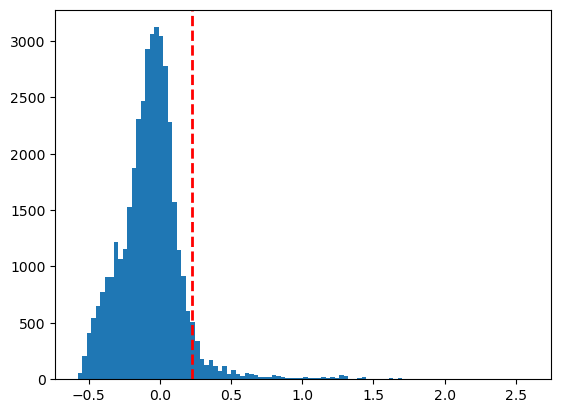

In [137]:
significant_elements_becalm_info = element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['element_is_significant']]
cava_significant_elements_becalm_info = element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['element_is_cava_is_significant']]
# mark 0.224569 with red line in hist of tmp_element_BECALM_logFC values
plt.hist(significant_elements_becalm_info['tmp_element_BECALM_logFC'], bins=100)
plt.axvline(x=0.224569, color='r', linestyle='dashed', linewidth=2)
plt.show()

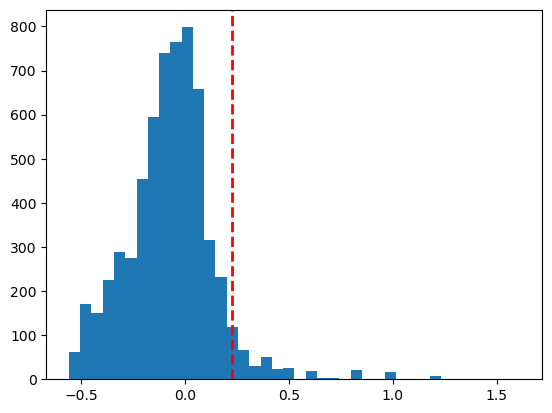

In [138]:
cava_significant_elements_becalm_info = element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['element_is_cava_is_significant']]
# mark 0.224569 with red line in hist of tmp_element_BECALM_logFC values
plt.hist(cava_significant_elements_becalm_info['tmp_element_BECALM_logFC'], bins=40)
plt.axvline(x=0.224569, color='r', linestyle='dashed', linewidth=2)
plt.show()

##### Get the TFs of the motifs

In [139]:
# TODO

##### Get the list of genes and 2-3 sentences about them
- ATR (Ataxia Telangiectasia and Rad3-related):
  - Disease association: 
    - No deleterious germline mutations were identified in French Canadian breast cancer cases.
    - ATR mutations are associated with changes in chromatin accessibility at active regulatory elements.
  - Expression effects:
    - ATR enrichment at gene regulatory regions correlates with openes and level of gene expression

- CYP2D6: https://en.wikipedia.org/wiki/CYP2D6 
  - expressed mainly in liver and areas of the central nervous system
  - member of xytochrome P450 mixed-function oxidase system (important for drug metabolism "xenobiotics)
  - 
- TCF20: 
  - diseases: 
    - https://www.malacards.org/search/results?q=TCF20
      - Developmental delay: https://www.malacards.org/card/developmental_delay_with_variable_intellectual_impairment_and_behavioral_abnormalities?search=TCF20 (7 publications)
      - find images: 

In [170]:
# all genes with tfs in alternative and reference
variants_hit_motifs.loc[(variants_hit_motifs['alt_id_associated_with_same_motif'] == True) & (variants_hit_motifs['ref_id_associated_with_same_motif'] == True)]


,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence,ref_sequence,alt_sequence,tmp_variant_map_Variant_id,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val,tmp_new_alt_seq_motif_id,tmp_new_ref_seq_motif_id,alt_id_associated_with_same_motif,ref_id_associated_with_same_motif
0,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,139,ZNF3.H12CORE.0.P.B,138,160,+,0.000081,AATATTTGTTGAATGAATGGATG,AAGCGAGTCTCACCAGTGATGTCACACATCTGTTGATTGTCTCCTC...,AAGCGAGTCTCACCAGTGATGTCACACATCTGTTGATTGTCTCCTC...,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,cardiac_neuro_cava_random:AHDC1|ENSG0000012670...,-0.557990,8.564960e-10,cardiac_neuro_cava_random:ALT_AHDC1|ENSG000001...,cardiac_neuro_cava_random:REF_AHDC1|ENSG000001...,True,True
5,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNB1|ENSG00000...,182,SP5.H12CORE.1.P.B,181,205,+,0.004750,GGGATTGGGGGGATGGGCAGAGCAG,GAACAGCTGATAAAAGAAGCCCTCCTTTGTTCTACATTTCCTGCCC...,GAACAGCTGATAAAAGAAGCCCTCCTTTGTTCTACATTTCCTGCCC...,cardiac_neuro_cava_random:CTNNB1|ENSG000001680...,cardiac_neuro_cava_random:CTNNB1|ENSG000001680...,-0.326044,1.535338e-02,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNB1|ENSG00000...,True,True
6,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,203,ZN467.H12CORE.0.P.C,194,216,-,0.005200,CTGGAAGGAAGGGGGGGGCAGGA,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,0.559425,3.894077e-07,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,True,True
12,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,212,ZN548.H12CORE.0.P.B,204,226,-,0.000021,CAGGATGAAGGTGGGGGCAGGGC,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,cardiac_neuro_cava_random:MAX|ENSG00000125952....,cardiac_neuro_cava_random:MAX|ENSG00000125952....,-0.404497,3.323203e-14,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,True,True
13,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,206,ZN548.H12CORE.0.P.B,204,226,-,0.000730,CAGGATGAAGGTGGGGGCAGAGC,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,cardiac_neuro_cava_random:MAX|ENSG00000125952....,cardiac_neuro_cava_random:MAX|ENSG00000125952....,-0.317499,9.663900e-08,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,True,True
14,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,SP5.H12CORE.1.P.B,96,120,-,0.007080,TGGCGTTGGGGAGGGAGAGGGGAGG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,True,True
15,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,ZN281.H12CORE.1.SM.B,99,124,-,0.003530,TGTGTGGCGTTGGGGAGGGAGAGGGG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00

In [164]:
# TODO
# CTNNB1 (3), IRF4, MAX, RAD51 motif is only found in the reference sequence according to the significant fimo results => evidence that motif gets lost
variants_hit_motifs.loc[variants_hit_motifs['alt_id_associated_with_same_motif'] == False]['tmp_variant_fimo_hit_ALT_ID'].to_list()
variants_hit_motifs.loc[variants_hit_motifs['alt_id_associated_with_same_motif'] == False]
# cardiac_neuro_cava_random:ALT_IRF4|ENSG00000137265.16|EH38E2438413_fwd_tile1-1_IRF4|ENSG00000137265.16|EH38E2438413|6-408346-C-A
# ZN148.H12CORE.0.P.B

# find info about the genes

# find info about the effect size

# find info about the TFs (expectation: if known to be activators, then the effect size should be negative since the motif is lost)

,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence,ref_sequence,alt_sequence,tmp_variant_map_Variant_id,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val,tmp_new_alt_seq_motif_id,tmp_new_ref_seq_motif_id,alt_id_associated_with_same_motif,ref_id_associated_with_same_motif
2,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNB1|ENSG00000...,182,ZN467.H12CORE.0.P.C,180,202,+,0.00730,GGGGATTGGGGGGATGGGCAGAG,GAACAGCTGATAAAAGAAGCCCTCCTTTGTTCTACATTTCCTGCCC...,GAACAGCTGATAAAAGAAGCCCTCCTTTGTTCTACATTTCCTGCCC...,cardiac_neuro_cava_random:CTNNB1|ENSG000001680...,cardiac_neuro_cava_random:CTNNB1|ENSG000001680...,-0.326044,1.535338e-02,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNB1|ENSG00000...,False,True
3,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNB1|ENSG00000...,182,ZN148.H12CORE.0.P.B,182,200,+,0.00594,GGATTGGGGGGATGGGCAG,GAACAGCTGATAAAAGAAGCCCTCCTTTGTTCTACATTTCCTGCCC...,GAACAGCTGATAAAAGAAGCCCTCCTTTGTTCTACATTTCCTGCCC...,cardiac_neuro_cava_random:CTNNB1|ENSG000001680...,cardiac_neuro_cava_random:CTNNB1|ENSG000001680...,-0.326044,1.535338e-02,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNB1|ENSG00000...,False,True
4,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNB1|ENSG00000...,182,SP5.H12CORE.1.P.B,176,200,+,0.00589,GTAAGGGGATTGGGGGGATGGGCAG,GAACAGCTGATAAAAGAAGCCCTCCTTTGTTCTACATTTCCTGCCC...,GAACAGCTGATAAAAGAAGCCCTCCTTTGTTCTACATTTCCTGCCC...,cardiac_neuro_cava_random:CTNNB1|ENSG000001680...,cardiac_neuro_cava_random:CTNNB1|ENSG000001680...,-0.326044,1.535338e-02,cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000...,cardiac_neuro_cava_random:REF_CTNNB1|ENSG00000...,False,True
10,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,193,ZN148.H12CORE.0.P.B,181,199,-,0.00444,GCAGGTGGGGGATGGGCCT,GAGTGATGACTGCTTGTAGGTATGTCTGTGCCATTTCTCAGGGAAG...,GAGTGATGACTGCTTGTAGGTATGTCTGTGCCATTTCTCAGGGAAG...,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,cardiac_neuro_cava_random:IRF4|ENSG00000137265...,-0.411988,8.458337e-04,cardiac_neuro_cava_random:ALT_IRF4|ENSG0000013...,cardiac_neuro_cava_random:REF_IRF4|ENSG0000013...,False,True
11,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,212,ZN148.H12CORE.0.P.B,202,220,-,0.00594,GAAGGTGGGGGCAGGGCCT,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,TGGACATGTTGACTTACCAAGTTCTATCTGATCAGTCACACTCACA...,cardiac_neuro_cava_random:MAX|ENSG00000125952....,cardiac_neuro_cava_random:MAX|ENSG00000125952....,-0.404497,3.323203e-14,cardiac_neuro_cava_random:ALT_MAX|ENSG00000125...,cardiac_neuro_cava_random:REF_MAX|ENSG00000125...,False,True
19,cardiac_neuro_cava_random:ALT_RAD51|ENSG000000...,cardiac_neuro_cava_random:REF_RAD51|ENSG000000...,54,THB.H12CORE.0.P.B,50,66,-,0.00990,CGGATCACCTGAGGTCA,TTACTAAAGACGAGGTTTCACCACGTTGGCCAGGTTTATCTCCAAC...,TTACTAAAGACGAGGTTTCACCACGTTGGCCAGGTTTATCTCCAAC...,cardiac_neuro_cava_random:RAD51|ENSG0000005118...,cardiac_neuro_cava_random:RAD51|ENSG0000005118...,-0.356206,4.798009e-02,cardiac_neuro_cava_random:ALT_RAD51|ENSG000000...,cardiac_neuro_cava_random:REF_RAD51|ENSG000000...,False,True


##### Motif gains according to significant results from fimo (list of motifs only found in alternative sequences)
- ATR, CYP2D6 (3), TCF20, CRAD51B
- ['cardiac_neuro_cava_random:ALT_ATR|ENSG00000175054.16|EH38E3544373_rev_tile1-1_ATR|ENSG00000175054.16|EH38E3544373|3-142447396-C-G',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166940~TCF20|ENSG00000100207.21|EH38E2166940_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166940|22-42177439-T-G',
 'cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101513|14-68575599-A-G']
- 3-142447396-C-G: our association: ATR
  - [gnomad](https://gnomad.broadinstitute.org/variant/3-142447396-C-G?dataset=gnomad_r4) falls within intron of XRN1 gene
    - singleton in european non-finnish population
    - sorrounding 1kb Region is constraint (Z=4.23)
- 22-42176382-G-C: our association: CYP2D6, TCF20:
  - [gnomad](https://gnomad.broadinstitute.org/variant/22-42176382-G-C?dataset=gnomad_r4) Associated to intron of TCF20
    - AF < 0.01 in all populations except Middle East (0.0136)
    - not constraint (Z= 0.76) 
  - 'ZN467.H12CORE.0.P.C', 'KLF16.H12CORE.1.P.B', 'SP5.H12CORE.1.P.B'
  - ZN467.H12CORE.0.P.C 
    - https://hocomoco12.autosome.org/motif/ZN467.H12CORE.0.P.C#mainInfo
    - NCBI summary: The protein encoded by this gene is a zinc finger protein whose function has not yet been elucidated in humans. However, the mouse ortholog of this protein enhances adipocyte differentiation and suppresses osteoblast differentiation in bone marrow. The mouse protein also is a transcription factor for several genes and can help recruit histone deacetylase complexes. [provided by RefSeq, Aug 2016]
      - mouse: neuro development and enhances adipocyte differentiation; histone deacetylase complex recruitment
    - It is active in neuro development which would fit here
- 22-42177439-T-G: our association: CYP2D6, TCF20
  - [gnomad](https://gnomad.broadinstitute.org/variant/22-42177439-T-G?dataset=gnomad_r4) Associated to intron of TCF20
    - singleton in european non-finnish population
  - 'ZN467.H12CORE.0.P.C', 'KLF16.H12CORE.1.P.B', 'SP5.H12CORE.1.P.B'

In [141]:
element_analaysis_becalm_df_variant_info_becalm.columns
# (element_analaysis_becalm_df_variant_info_becalm['is_element'] & element_analaysis_becalm_df_variant_info_becalm['is_cava']).sum()
(element_analaysis_becalm_df_variant_info_becalm['is_variant'] & element_analaysis_becalm_df_variant_info_becalm['is_cava']).sum()
# (element_analaysis_becalm_df_variant_info_becalm['element_is_cava_is_significant']).sum() # 6110 / 6847
# (element_analaysis_becalm_df_variant_info_becalm['element_is_cava_is_significant']).sum() # 6110 / 6847

6694

In [142]:
cava_all_info_combined = element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['is_cava']]
cava_all_info_combined[cava_all_info_combined['tmp_element_BECALM_logFC'] > 1]['tmp_element_BECALM_id'].to_list()
cava_all_info_combined[cava_all_info_combined['tmp_element_BECALM_logFC'] > 1]['tmp_element_BECALM_id'].to_list()

['cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000100197.23|EH38E3484163_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_BCL10|ENSG00000142867.14|EH38E1363725_rev_tile1-1',
 'cardiac_neuro_cava_random:REF_FLCN|ENSG00000154803.13|EH38E3211652_rev_tile1-1']

In [143]:
cava_all_info_combined.groupby('tmp_element_BECALM_id').size().reset_index(name='variant_count') # 1633
cava_all_info_combined.groupby('tmp_element_BECALM_id').size().reset_index(name='variant_count')['variant_count'].describe()

#

count    1633.000000
mean        4.192897
std         3.981286
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max        31.000000
Name: variant_count, dtype: float64

In [144]:
cava_all_info_combined['tmp_screen_region'] = cava_all_info_combined['tmp_element_BECALM_id'].apply(hf.get_region_info)

/tmp/ipykernel_250236/1813226230.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cava_all_info_combined['tmp_screen_region'] = cava_all_info_combined['tmp_element_BECALM_id'].apply(hf.get_region_info)


In [145]:
cava_all_info_combined['tmp_screen_region'].value_counts()

EH38E3187925    31
EH38E2110584    30
EH38E1756126    30
EH38E3544387    28
EH38E2982987    28
                ..
EH38E1567654     1
EH38E3507648     1
EH38E1723317     1
EH38E2797930     1
EH38E1363725     1
Name: tmp_screen_region, Length: 1633, dtype: int64

In [146]:
cava_all_info_combined['tmp_element_BECALM_id'].nunique()

1633

In [147]:
# goto: /data/gpfs-1/work/groups/ag_kircher/Kaikkonen_2023/filesFromMinnaKaikkonen/github_repo/STARseqCNN/VariantEffects/plot_alignment_withPWM.py

In [149]:
# screen ids should be unique in all headers:
# - 48 * 20 =


In [150]:
6110 / 6847

0.8923616182269607

In [151]:
variants_hit_motifs.loc[variants_hit_motifs['ref_id_associated_with_same_motif'] == False]

,tmp_variant_fimo_hit_ALT_ID,tmp_variant_fimo_hit_REF_ID,tmp_variant_fimo_hit_variant_pos,tmp_fimo_results_motif_id,tmp_fimo_results_start,tmp_fimo_results_stop,tmp_fimo_results_strand,tmp_fimo_results_q-value,tmp_fimo_results_matched_sequence,ref_sequence,alt_sequence,tmp_variant_map_Variant_id,tmp_variant_BECALM_variant_id,tmp_variant_BECALM_logFC,tmp_variant_BECALM_adj.P.Val,tmp_new_alt_seq_motif_id,tmp_new_ref_seq_motif_id,alt_id_associated_with_same_motif,ref_id_associated_with_same_motif
1,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,192,PATZ1.H12CORE.0.P.B,191,213,-,0.00898,GGCTCCGGGGGCCGGGTGGGCGG,GAACGCTTTTACTGTTCTCCGGTTTCCTCCCGGGGAGCTGCAAGTT...,GAACGCTTTTACTGTTCTCCGGTTTCCTCCCGGGGAGCTGCAAGTT...,cardiac_neuro_cava_random:ATR|ENSG00000175054....,cardiac_neuro_cava_random:ATR|ENSG00000175054....,0.231947,3.622995e-02,cardiac_neuro_cava_random:ALT_ATR|ENSG00000175...,cardiac_neuro_cava_random:REF_ATR|ENSG00000175...,True,False
7,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,203,KLF16.H12CORE.1.P.B,192,214,-,0.00653,GGAAGGAAGGGCGGGGCAGGATG,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,0.559425,3.894077e-07,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,True,False
8,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,203,SP5.H12CORE.1.P.B,196,220,-,0.00806,TGCGCTGGAAGGAAGGGCGGGGCAG,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,CCCCTCTCTGTGCTTCCCCAGGAGAGAAGCAGGGCTGTCCACGGAG...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,0.559425,3.894077e-07,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,True,False
9,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,234,ZN613.H12CORE.0.P.C,233,257,+,0.00691,TCTTAAGTTTTTTACTTTTCTTTTT,TTTTCTTTGCTGAGATGATAGGGGGATGTTTTGCAGTGTGTTAACT...,TTTTCTTTGCTGAGATGATAGGGGGATGTTTTGCAGTGTGTTAACT...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,cardiac_neuro_cava_random:CYP2D6|ENSG000001001...,-0.187405,3.901183e-04,cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000...,cardiac_neuro_cava_random:REF_CYP2D6|ENSG00000...,True,False
17,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,115,PATZ1.H12CORE.0.P.B,97,119,-,0.00761,GGCGCTGGGGAGGGAGAGGGGAG,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,CTCTTCCCTGGGTCTTAGGCCCCATTTGAAAAATTGAAATGGACCG...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,cardiac_neuro_cava_random:RAD51B|ENSG000001821...,-0.357816,1.954989e-02,cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000...,cardiac_neuro_cava_random:REF_RAD51B|ENSG00000...,True,False


In [152]:
# ATR, CYP2D6 (3), RAD51B motif is only found in alternative sequence according to the significant fimo results => evidence that motif gets gained
variants_hit_motifs.loc[variants_hit_motifs['ref_id_associated_with_same_motif'] == False]['tmp_variant_fimo_hit_ALT_ID'].to_list() # 5 results: (ATR, CYP2D6 (3), TCF20 (3), RAD51B)
# variants_hit_motifs.loc[variants_hit_motifs['ref_id_associated_with_same_motif'] == False]['tmp_variant_fimo_hit_REF_ID'].to_list() # 5 results: (ATR, CYP2D6 (3), RAD51B)
# variants_hit_motifs.loc[variants_hit_motifs['ref_id_associated_with_same_motif'] == False]['tmp_fimo_results_motif_id'].to_list() # 5 results: (ATR, CYP2D6 (3), RAD51B)

# find info about the genes
# CYP2D6, TCF20
# variants_hit_motifs.loc[variants_hit_motifs['tmp_variant_fimo_hit_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C']
# variants_hit_motifs.loc[variants_hit_motifs['tmp_variant_fimo_hit_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C']['tmp_fimo_results_motif_id'].to_list()
# # ['ZN467.H12CORE.0.P.C', 'KLF16.H12CORE.1.P.B', 'SP5.H12CORE.1.P.B']
# https://hocomoco12.autosome.org/motif/ZN467.H12CORE.0.P.C#mainInfo
# The protein encoded by this gene is a zinc finger protein whose function has not yet been elucidated in humans. However, the mouse ortholog of this protein enhances adipocyte differentiation and suppresses osteoblast differentiation in bone marrow. The mouse protein also is a transcription factor for several genes and can help recruit histone deacetylase complexes. [provided by RefSeq, Aug 2016]
# variants_hit_motifs.loc[variants_hit_motifs['tmp_variant_fimo_hit_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C']['tmp_variant_BECALM_logFC'].to_list()

# # find info about the effect size
# 22-42176382-G-C: KLF16: known to have activator and repressing functions
# element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C']
# # element becalm: 0.258864, variant becalm: 0.559425

# 22-42177439-T-G: ZN613: not well studied
# element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166940~TCF20|ENSG00000100207.21|EH38E2166940_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166940|22-42177439-T-G']
# element becalm: -0.14682 variant becalm: -0.187405

# 14-68575599-A-G: PATZ1: well known repressive TF
# element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101513|14-68575599-A-G']
# element becalm: -0.0774 variant becalm: -0.3578
# find info about the TFs (expectation: if known to be activators, then the effect size should be positive since the motif is gained, if known to be repressors then the effect size should be negative (same reasoning))

# ['PATZ1.H12CORE.0.P.B', ATR; variant 1
#  'KLF16.H12CORE.1.P.B', CYP2D6 (3), TCF20 (3) varaint 2; 22-42176382-G-C
#  'SP5.H12CORE.1.P.B', CYP2D6 (3), TCF20 (3) variant 2; 22-42176382-G-C
#  'ZN613.H12CORE.0.P.C', CYP2D6 (3), TCF20 (3) variant 3; 22-42177439-T-G
#  'PATZ1.H12CORE.0.P.B'] RAD51B variant 4;

['cardiac_neuro_cava_random:ALT_ATR|ENSG00000175054.16|EH38E3544373_rev_tile1-1_ATR|ENSG00000175054.16|EH38E3544373|3-142447396-C-G',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166940~TCF20|ENSG00000100207.21|EH38E2166940_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166940|22-42177439-T-G',
 'cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101513|14-68575599-A-G']

In [153]:
variants_hit_motifs.loc[variants_hit_motifs['alt_id_associated_with_same_motif'] == False]['tmp_variant_fimo_hit_ALT_ID'].to_list() # 5 results: (ATR, CYP2D6 (3), TCF20 (3), CRAD51B)


['cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000168036.18|EH38E2194647_fwd_tile1-1_CTNNB1|ENSG00000168036.18|EH38E2194647|3-41158686-G-T',
 'cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000168036.18|EH38E2194647_fwd_tile1-1_CTNNB1|ENSG00000168036.18|EH38E2194647|3-41158686-G-T',
 'cardiac_neuro_cava_random:ALT_CTNNB1|ENSG00000168036.18|EH38E2194647_fwd_tile1-1_CTNNB1|ENSG00000168036.18|EH38E2194647|3-41158686-G-T',
 'cardiac_neuro_cava_random:ALT_IRF4|ENSG00000137265.16|EH38E2438413_fwd_tile1-1_IRF4|ENSG00000137265.16|EH38E2438413|6-408346-C-A',
 'cardiac_neuro_cava_random:ALT_MAX|ENSG00000125952.20|EH38E1721673_rev_tile1-1_MAX|ENSG00000125952.20|EH38E1721673|14-65081453-G-T',
 'cardiac_neuro_cava_random:ALT_RAD51|ENSG00000051180.17|EH38E3129595_fwd_tile1-1_RAD51|ENSG00000051180.17|EH38E3129595|15-40694279-C-G']

##### Make E2G overlap with all significant variants and filter for cava associated genes
- make huge cava associated gene list (union of our list + list from google)
- prepare E2G data: download different files from cell types (neuronal stem cells, neuronal progenitor cells)
  - add the column of source: 

In [154]:
# # test functionality:
# ref_fimo_variants_hit_motif.loc[ref_fimo_variants_hit_motif['name'] == 'cardiac_neuro_cava_random:REF_RAD51D|ENSG00000185379.21|EH38E3219187_rev_tile1-1']['tmp_variant_fimo_hit_ALT_ID'].to_list()
# ref_fimo_variants_hit_motif.loc[ref_fimo_variants_hit_motif['name'] == 'cardiac_neuro_cava_random:REF_RAD51D|ENSG00000185379.21|EH38E3219187_rev_tile1-1']['tmp_variant_fimo_hit_variant_pos'].to_list()

In [155]:
# ATR, CYP2D6 (3), CRAD51B motif is only found in alternative sequence according to the significant fimo results => evidence that motif gets gained
variants_hit_motifs.loc[variants_hit_motifs['ref_id_associated_with_same_motif'] == False]['tmp_variant_fimo_hit_ALT_ID'].to_list() # 5 results: (ATR, CYP2D6 (3), TCF20 (3), CRAD51B)
# variants_hit_motifs.loc[variants_hit_motifs['ref_id_associated_with_same_motif'] == False]['tmp_variant_fimo_hit_REF_ID'].to_list() # 5 results: (ATR, CYP2D6 (3), CRAD51B)
# variants_hit_motifs.loc[variants_hit_motifs['ref_id_associated_with_same_motif'] == False]['tmp_fimo_results_motif_id'].to_list() # 5 results: (ATR, CYP2D6 (3), CRAD51B)

# find info about the genes
# CYP2D6, TCF20
# variants_hit_motifs.loc[variants_hit_motifs['tmp_variant_fimo_hit_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C']
# variants_hit_motifs.loc[variants_hit_motifs['tmp_variant_fimo_hit_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C']['tmp_fimo_results_motif_id'].to_list()
# # ['ZN467.H12CORE.0.P.C', 'KLF16.H12CORE.1.P.B', 'SP5.H12CORE.1.P.B']
# https://hocomoco12.autosome.org/motif/ZN467.H12CORE.0.P.C#mainInfo
# The protein encoded by this gene is a zinc finger protein whose function has not yet been elucidated in humans. However, the mouse ortholog of this protein enhances adipocyte differentiation and suppresses osteoblast differentiation in bone marrow. The mouse protein also is a transcription factor for several genes and can help recruit histone deacetylase complexes. [provided by RefSeq, Aug 2016]
# variants_hit_motifs.loc[variants_hit_motifs['tmp_variant_fimo_hit_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C']['tmp_variant_BECALM_logFC'].to_list()

# # find info about the effect size
# element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C']
# # element becalm: 0.258864, variant becalm: 0.559425
# element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166940~TCF20|ENSG00000100207.21|EH38E2166940_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166940|22-42177439-T-G']
# element becalm: -0.14682 variant becalm: -0.187405
# element_analaysis_becalm_df_variant_info_becalm.loc[element_analaysis_becalm_df_variant_info_becalm['tmp_variant_map_ALT_ID'] == 'cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101513|14-68575599-A-G']
# element becalm: -0.0774 variant becalm: -0.3578
# find info about the TFs (expectation: if known to be activators, then the effect size should be positive since the motif is gained, if known to be repressors then the effect size should be negative (same reasoning))

# ['PATZ1.H12CORE.0.P.B', ATR; variant 1
#  'KLF16.H12CORE.1.P.B', CYP2D6 (3), TCF20 (3) varaint 2; 22-42176382-G-C
#  'SP5.H12CORE.1.P.B', CYP2D6 (3), TCF20 (3) variant 2; 22-42176382-G-C
#  'ZN613.H12CORE.0.P.C', CYP2D6 (3), TCF20 (3) variant 3; 22-42177439-T-G
#  'PATZ1.H12CORE.0.P.B'] CRAD51B variant 4;

['cardiac_neuro_cava_random:ALT_ATR|ENSG00000175054.16|EH38E3544373_rev_tile1-1_ATR|ENSG00000175054.16|EH38E3544373|3-142447396-C-G',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166938~TCF20|ENSG00000100207.21|EH38E2166938_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166938|22-42176382-G-C',
 'cardiac_neuro_cava_random:ALT_CYP2D6|ENSG00000100197.23|EH38E2166940~TCF20|ENSG00000100207.21|EH38E2166940_rev_tile1-1_CYP2D6|ENSG00000100197.23|EH38E2166940|22-42177439-T-G',
 'cardiac_neuro_cava_random:ALT_RAD51B|ENSG00000182185.19|EH38E3101513_fwd_tile1-1_RAD51B|ENSG00000182185.19|EH38E3101513|14-68575599-A-G']

### Investigate the element effects

### Core archive:

info from metadata (ref with info from alt)

In [156]:
# # get_info_for_ref_from_metadata(metadata_file=significant_results_cava_ref_alt, references_of_interest=ref_of_interest, columns_of_interest=['variant_pos'], variant_region_map=variant_region_map)
# # try it yourself
# # split ref and alt
# alt_variants_sig_cava = significant_results_cava_ref_alt.loc[significant_results_cava_ref_alt[col_allele].apply(hf.is_alternative)]
# ref_variants_sig_cava = significant_results_cava_ref_alt.loc[significant_results_cava_ref_alt[col_allele].apply(hf.is_reference)]

# # add ref id to alt df
# variant_region_map.columns = ['tmp_variant_map_Variant_id', 'tmp_variant_map_Region', 'tmp_variant_map_REF_ID', 'tmp_variant_map_ALT_ID']
# alt_variants_sig_cava_variant_map = alt_variants_sig_cava.merge(variant_region_map[['tmp_variant_map_Variant_id', 'tmp_variant_map_ALT_ID', 'tmp_variant_map_REF_ID']], left_on=col_name, right_on='tmp_variant_map_ALT_ID', how='left')

# # left join over ref id
# columns_of_interest = ['variant_pos']
# ref_varaints_sig_cava_metadata = ref_variants_sig_cava.merge(alt_variants_sig_cava_variant_map[['tmp_variant_map_ALT_ID', 'tmp_variant_map_REF_ID']+columns_of_interest], left_on=col_name, right_on='tmp_variant_map_REF_ID', how='left')

# # groupby of col_name and get the information of the variant position in a list per sequence
# ref_varaints_sig_cava_metadata.columns
# # ref_varaints_sig_cava_metadata.groupby(col_name)['variant_pos'].apply(list).to_dict()
# get_info_for_ref_from_metadata(metadata_file=significant_results_cava_ref_alt, references_of_interest=ref_of_interest, columns_of_interest=['variant_pos'], variant_region_map=variant_region_map)
